# Telecom Churn Prediction
Team - Saumy DhoLu_Satish Kumar

# Step 0: Problem statement
## Telecom Customer Churn Prediction: A Strategic Approach

In the dynamic and fiercely competitive telecommunications landscape, customer retention reigns supreme. With customers empowered to switch service providers at will, the industry grapples with a substantial annual churn rate of 15-25%. Recognizing that acquiring new customers can cost 5-10 times more than retaining existing ones, incumbent operators are prioritizing churn reduction as a paramount business objective, particularly for their high-value clientele.

This project focuses on analyzing customer-level data from a leading telecom firm to develop predictive models capable of identifying customers at high risk of churn. By accurately forecasting potential churners, companies can implement proactive measures to mitigate losses and enhance customer loyalty.

**Understanding Customer Behavior During Churn:**

Customer churn is rarely an instantaneous decision. Instead, it typically unfolds over a series of phases:

* **The 'Good' Phase:**
    * Customers are satisfied with the service and exhibit normal usage patterns.
* **The 'Action' Phase:**
    * Customer experience deteriorates due to factors like competitive offers, billing disputes, or service quality issues.
    * Customers display altered behavior, signaling potential dissatisfaction.
    * This phase presents a critical opportunity for intervention and retention efforts.
* **The 'Churn' Phase:**
    * Customers ultimately switch to a competitor.

**Project Scope:**

This analysis will utilize a Four-month window to model customer behavior:

* Months 1-2: Represent the 'good' phase.
* Month 3: Represents the 'action' phase, where we aim to identify high-risk customers.
* Month 4 (September): Represents the 'churn' phase, used to validate our predictive models.

**Project Goals:**

* Build robust machine learning models to predict customer churn.
* Identify the key indicators and drivers of customer churn.
* Provide actionable insights that enable the telecom company to proactively retain valuable customers.

# Step 1: Invoking Libraries/Packages

In [12]:
#Data Structures
import pandas as pd
import numpy as np
import re
import os

import missingno as msno

#Sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, make_scorer, f1_score, classification_report , roc_auc_score 
from sklearn.metrics import confusion_matrix, precision_score, precision_recall_curve, recall_score
from scipy.stats import uniform, randint
#xgboost
from xgboost import XGBClassifier
import lightgbm as lgb
import xgboost as xgb

import shap

#Plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns


#Others
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Step 2: Reading, Understanding and Cleaning the Data

### __Used main data source__ ---> 
>train.csv
>
>test.csv

In [15]:
data = pd.read_csv("train.csv")
unseen = pd.read_csv("test.csv")
sample = pd.read_csv("sample.csv")
data_dict = pd.read_csv("data_dictionary.csv")

print(data.shape)
print(unseen.shape)
print(sample.shape)
print(data_dict.shape)

(69999, 172)
(30000, 171)
(30000, 2)
(36, 2)


### Data Quality Check

In [17]:
data_columns_list = list(data.columns)
data_columns_list

['id',
 'circle_id',
 'loc_og_t2o_mou',
 'std_og_t2o_mou',
 'loc_ic_t2o_mou',
 'last_date_of_month_6',
 'last_date_of_month_7',
 'last_date_of_month_8',
 'arpu_6',
 'arpu_7',
 'arpu_8',
 'onnet_mou_6',
 'onnet_mou_7',
 'onnet_mou_8',
 'offnet_mou_6',
 'offnet_mou_7',
 'offnet_mou_8',
 'roam_ic_mou_6',
 'roam_ic_mou_7',
 'roam_ic_mou_8',
 'roam_og_mou_6',
 'roam_og_mou_7',
 'roam_og_mou_8',
 'loc_og_t2t_mou_6',
 'loc_og_t2t_mou_7',
 'loc_og_t2t_mou_8',
 'loc_og_t2m_mou_6',
 'loc_og_t2m_mou_7',
 'loc_og_t2m_mou_8',
 'loc_og_t2f_mou_6',
 'loc_og_t2f_mou_7',
 'loc_og_t2f_mou_8',
 'loc_og_t2c_mou_6',
 'loc_og_t2c_mou_7',
 'loc_og_t2c_mou_8',
 'loc_og_mou_6',
 'loc_og_mou_7',
 'loc_og_mou_8',
 'std_og_t2t_mou_6',
 'std_og_t2t_mou_7',
 'std_og_t2t_mou_8',
 'std_og_t2m_mou_6',
 'std_og_t2m_mou_7',
 'std_og_t2m_mou_8',
 'std_og_t2f_mou_6',
 'std_og_t2f_mou_7',
 'std_og_t2f_mou_8',
 'std_og_t2c_mou_6',
 'std_og_t2c_mou_7',
 'std_og_t2c_mou_8',
 'std_og_mou_6',
 'std_og_mou_7',
 'std_og_mou_8',
 

### Organizing Telecom Customer Data for Churn Prediction

In this section, we categorize and select relevant features from the dataset to build a customer churn prediction model. We use regular expressions to filter column names based on patterns, making it easier to group related features. 

- **IDs and Circle Information:** Identifies customers and their associated circle.
- **Revenue & ARPU:** Tracks revenue and average revenue per user.
- **Recharge & Data Usage Patterns:** Includes total recharge counts, amounts, and data usage metrics.
- **Call & Usage Patterns:** Captures outgoing, incoming, on-net, off-net, and roaming minutes.
- **Data Consumption:** Measures 2G, 3G data volumes and volume-based charging.
- **Subscription & Pack Details:** Tracks night pack usage, monthly and sachet subscriptions, and Facebook users.
- **Customer Tenure:** Measures the age-on-network (AON) feature.
- **Dates & Timings:** Records the last recharge dates and the last date of the month.
- **Target Variable:** The churn probability column.

Finally, we compile all selected features into a single list and subset the `data` DataFrame, setting the customer ID as the index. This prepares the dataset for further preprocessing and model training.


In [19]:
# IDs and circle information
ids = ['id', 'circle_id']

# Revenue & ARPU
arpu = [i for i in list(data.columns) if re.search('arpu', i)]

# Recharge & Data Usage Patterns
total_recharges = [i for i in list(data.columns) if re.search('total_rech_num', i)]
total_recharge_amounts = [i for i in list(data.columns) if re.search('total_rech_amt', i)]
max_recharge_amounts = [i for i in list(data.columns) if re.search('max_rech_amt', i)]
last_day_recharge_amounts = [i for i in list(data.columns) if re.search('last_day_rch_amt', i)]
total_recharge_data = [i for i in list(data.columns) if re.search('total_rech_data', i)]
average_recharge_amount_data = [i for i in list(data.columns) if re.search('av_rech_amt_data', i)]

# Call & Usage Patterns
total_outgoing_minutes = [i for i in list(data.columns) if re.search('total_og_mou', i)]
total_incoming_minutes = [i for i in list(data.columns) if re.search('total_ic_mou', i)]
onnet_minutes = [i for i in list(data.columns) if re.search('onnet_mou', i)]
offnet_minutes = [i for i in list(data.columns) if re.search('offnet_mou', i)]
roaming_incoming_minutes = [i for i in list(data.columns) if re.search('roam_ic_mou', i)]
roaming_outgoing_minutes = [i for i in list(data.columns) if re.search('roam_og_mou', i)]

# Data Consumption
vol_2g = [i for i in list(data.columns) if re.search('vol_2g_mb', i)]
vol_3g = [i for i in list(data.columns) if re.search('vol_3g_mb', i)]
vbc_3g = [i for i in list(data.columns) if re.search('vbc_3g', i)]

# Subscription & Pack Details
night_pack_users = [i for i in list(data.columns) if re.search('night_pck_user', i)]
monthly_2g = [i for i in list(data.columns) if re.search('monthly_2g', i)]
monthly_3g = [i for i in list(data.columns) if re.search('monthly_3g', i)]
sachet_2g = [i for i in list(data.columns) if re.search('sachet_2g', i)]
sachet_3g = [i for i in list(data.columns) if re.search('sachet_3g', i)]
fb_users = [i for i in list(data.columns) if re.search('fb_user', i)]

# Customer Tenure
aon = ['aon']

# Dates & Timings
last_month_dates = [i for i in list(data.columns) if re.search('last_date_of_month', i)]
last_recharge_dates = [i for i in list(data.columns) if re.search('date_of_last_rech', i)]
last_data_recharge_dates = [i for i in list(data.columns) if re.search('date_of_last_rech_data', i)]

# Target Variable
churn_label = ['churn_probability']

#Storing them in a single flat list
variables = [*ids, 
             *arpu,
             *total_recharges, 
             *total_recharge_amounts, 
             *max_recharge_amounts, 
             *last_day_recharge_amounts,
             *total_recharge_data,
             *average_recharge_amount_data,
             *total_outgoing_minutes, 
             *total_incoming_minutes, 
             *onnet_minutes, 
             *offnet_minutes, 
             *roaming_incoming_minutes,
             *roaming_outgoing_minutes,
             *vol_2g, 
             *vol_3g, 
             *vbc_3g,
             *night_pack_users,
             *monthly_2g,
             *monthly_3g,
             *sachet_2g,
             *sachet_3g,
             *fb_users,
             *aon,
             *last_month_dates,
             *last_recharge_dates,
             *last_data_recharge_dates,
             'churn_probability']

data = data[variables].set_index('id')

In [20]:
# looking first few raws of the prepared data  
data.head()

,circle_id,arpu_6,arpu_7,arpu_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,...,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,churn_probability
id,,,,,,,,,,,,,,,,,,,,,
0,109,31.277,87.009,7.527,NaN,NaN,NaN,NaN,NaN,NaN,...,6/22/2014,7/10/2014,8/24/2014,NaN,NaN,NaN,NaN,NaN,NaN,0
1,109,0.000,122.787,42.953,NaN,122.07,NaN,NaN,122.08,NaN,...,6/12/2014,7/10/2014,8/26/2014,NaN,7/8/2014,NaN,NaN,7/8/2014,NaN,0
2,109,60.806,103.176,0.000,NaN,NaN,NaN,NaN,NaN,NaN,...,6/11/2014,7/22/2014,8/24/2014,NaN,NaN,NaN,NaN,NaN,NaN,0
3,109,156.362,205.260,111.095,NaN,NaN,NaN,NaN,NaN,NaN,...,6/15/2014,7/21/2014,8/25/2014,NaN,NaN,NaN,NaN,NaN,NaN,0
4,109,240.708,128.191,101.565,0.0,35.00,0.0,0.0,35.12,0.0,...,6/25/2014,7/26/2014,8/30/2014,6/25/2014,7/23/2014,8/20/2014,6/25/2014,7/23/2014,8/20/2014,0


Let's look at each variable's datatype:

In [22]:
data.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
Index: 69999 entries, 0 to 69998
Data columns (total 87 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   circle_id                 69999 non-null  int64  
 1   arpu_6                    69999 non-null  float64
 2   arpu_7                    69999 non-null  float64
 3   arpu_8                    69999 non-null  float64
 4   arpu_3g_6                 17568 non-null  float64
 5   arpu_3g_7                 17865 non-null  float64
 6   arpu_3g_8                 18417 non-null  float64
 7   arpu_2g_6                 17568 non-null  float64
 8   arpu_2g_7                 17865 non-null  float64
 9   arpu_2g_8                 18417 non-null  float64
 10  total_rech_num_6          69999 non-null  int64  
 11  total_rech_num_7          69999 non-null  int64  
 12  total_rech_num_8          69999 non-null  int64  
 13  total_rech_amt_6          69999 non-null  int64  
 14  total_rech_

Let's also summarize the features using the df.describe method:

In [24]:
data.describe(include="all")

,circle_id,arpu_6,arpu_7,arpu_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,...,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,churn_probability
count,69999.0,69999.000000,69999.000000,69999.000000,17568.000000,17865.000000,18417.000000,17568.000000,17865.000000,18417.000000,...,68898,68765,67538,17568,17865,18417,17568,17865,18417,69999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30,31,31,30,31,31,30,31,31,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6/30/2014,7/31/2014,8/31/2014,6/30/2014,7/31/2014,8/31/2014,6/30/2014,7/31/2014,8/31/2014,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11880,12206,10324,1317,1282,1388,1317,1282,1388,NaN
mean,109.0,283.134365,278.185912,278.858826,90.069931,89.115767,90.618564,86.863900,85.846074,86.348404,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101887
std,0.0,334.213918,344.366927,351.924315,193.600413,195.826990,189.907986,171.321203,178.067280,170.297094,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.302502
min,109.0,-2258.709000,-1289.715000,-945.808000,-20.380000,-26.040000,-24.490000,-35.830000,-13.090000,-55.830000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,109.0,93.581000,86.714000,84.095000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,109.0,197.484000,191.588000,192.234000,0.520000,0.420000,0.840000,11.300000,8.800000,9.090000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,109.0,370.791000,365.369500,369.909000,122.070000,120.860000,122.070000,122.070000,122.070000,122.070000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [25]:
# Checking Unique Circle IDs
data['circle_id'].unique()

array([109], dtype=int64)

The circle_id for the whole data is same as removing the circle_id col from the data in next step.

In [27]:
# Splitting Features and Target Variable
X = data.drop(['circle_id'], axis=1).iloc[:, :-1]
y = data.iloc[:, -1] #Selects the last column (`churn_probability`) as the target label.

# print the shapes of `X` and `y` to verify the dimensions of the feature matrix and the target vector.
X.shape, y.shape

((69999, 85), (69999,))

### Splitting the Data into Training and Test Sets

In [29]:
# Split the dataset into training and test sets using an 80-20 split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=9)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((55999, 85), (14000, 85), (55999,), (14000,))

In [30]:
# looking the first few rows of the X_train
X_train.head()

,arpu_6,arpu_7,arpu_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,total_rech_num_6,...,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8
id,,,,,,,,,,,,,,,,,,,,,
303,1581.538,1123.952,738.110,NaN,NaN,NaN,NaN,NaN,NaN,46,...,8/31/2014,6/30/2014,7/31/2014,8/31/2014,NaN,NaN,NaN,NaN,NaN,NaN
2156,153.750,2.250,1.630,NaN,NaN,NaN,NaN,NaN,NaN,2,...,8/31/2014,6/21/2014,7/23/2014,8/15/2014,NaN,NaN,NaN,NaN,NaN,NaN
63650,490.151,441.268,393.735,NaN,0.00,NaN,NaN,2.20,NaN,31,...,8/31/2014,6/30/2014,7/30/2014,8/29/2014,NaN,7/30/2014,NaN,NaN,7/30/2014,NaN
68823,513.014,445.141,475.087,264.28,212.17,259.26,233.92,212.17,215.57,7,...,8/31/2014,6/25/2014,7/21/2014,8/24/2014,6/14/2014,7/11/2014,8/21/2014,6/14/2014,7/11/2014,8/21/2014
49063,122.264,57.524,132.976,NaN,NaN,NaN,NaN,NaN,NaN,3,...,8/31/2014,6/17/2014,7/19/2014,8/20/2014,NaN,NaN,NaN,NaN,NaN,NaN


## Handling Missing data

In [32]:
# Checking for null values
print(X_train.isnull().sum())

arpu_6                          0
arpu_7                          0
arpu_8                          0
arpu_3g_6                   41912
arpu_3g_7                   41664
                            ...  
date_of_last_rech_data_7    41664
date_of_last_rech_data_8    41279
date_of_last_rech_data_6    41912
date_of_last_rech_data_7    41664
date_of_last_rech_data_8    41279
Length: 85, dtype: int64


### Visualizing Missing Values in Training Data

<Axes: >

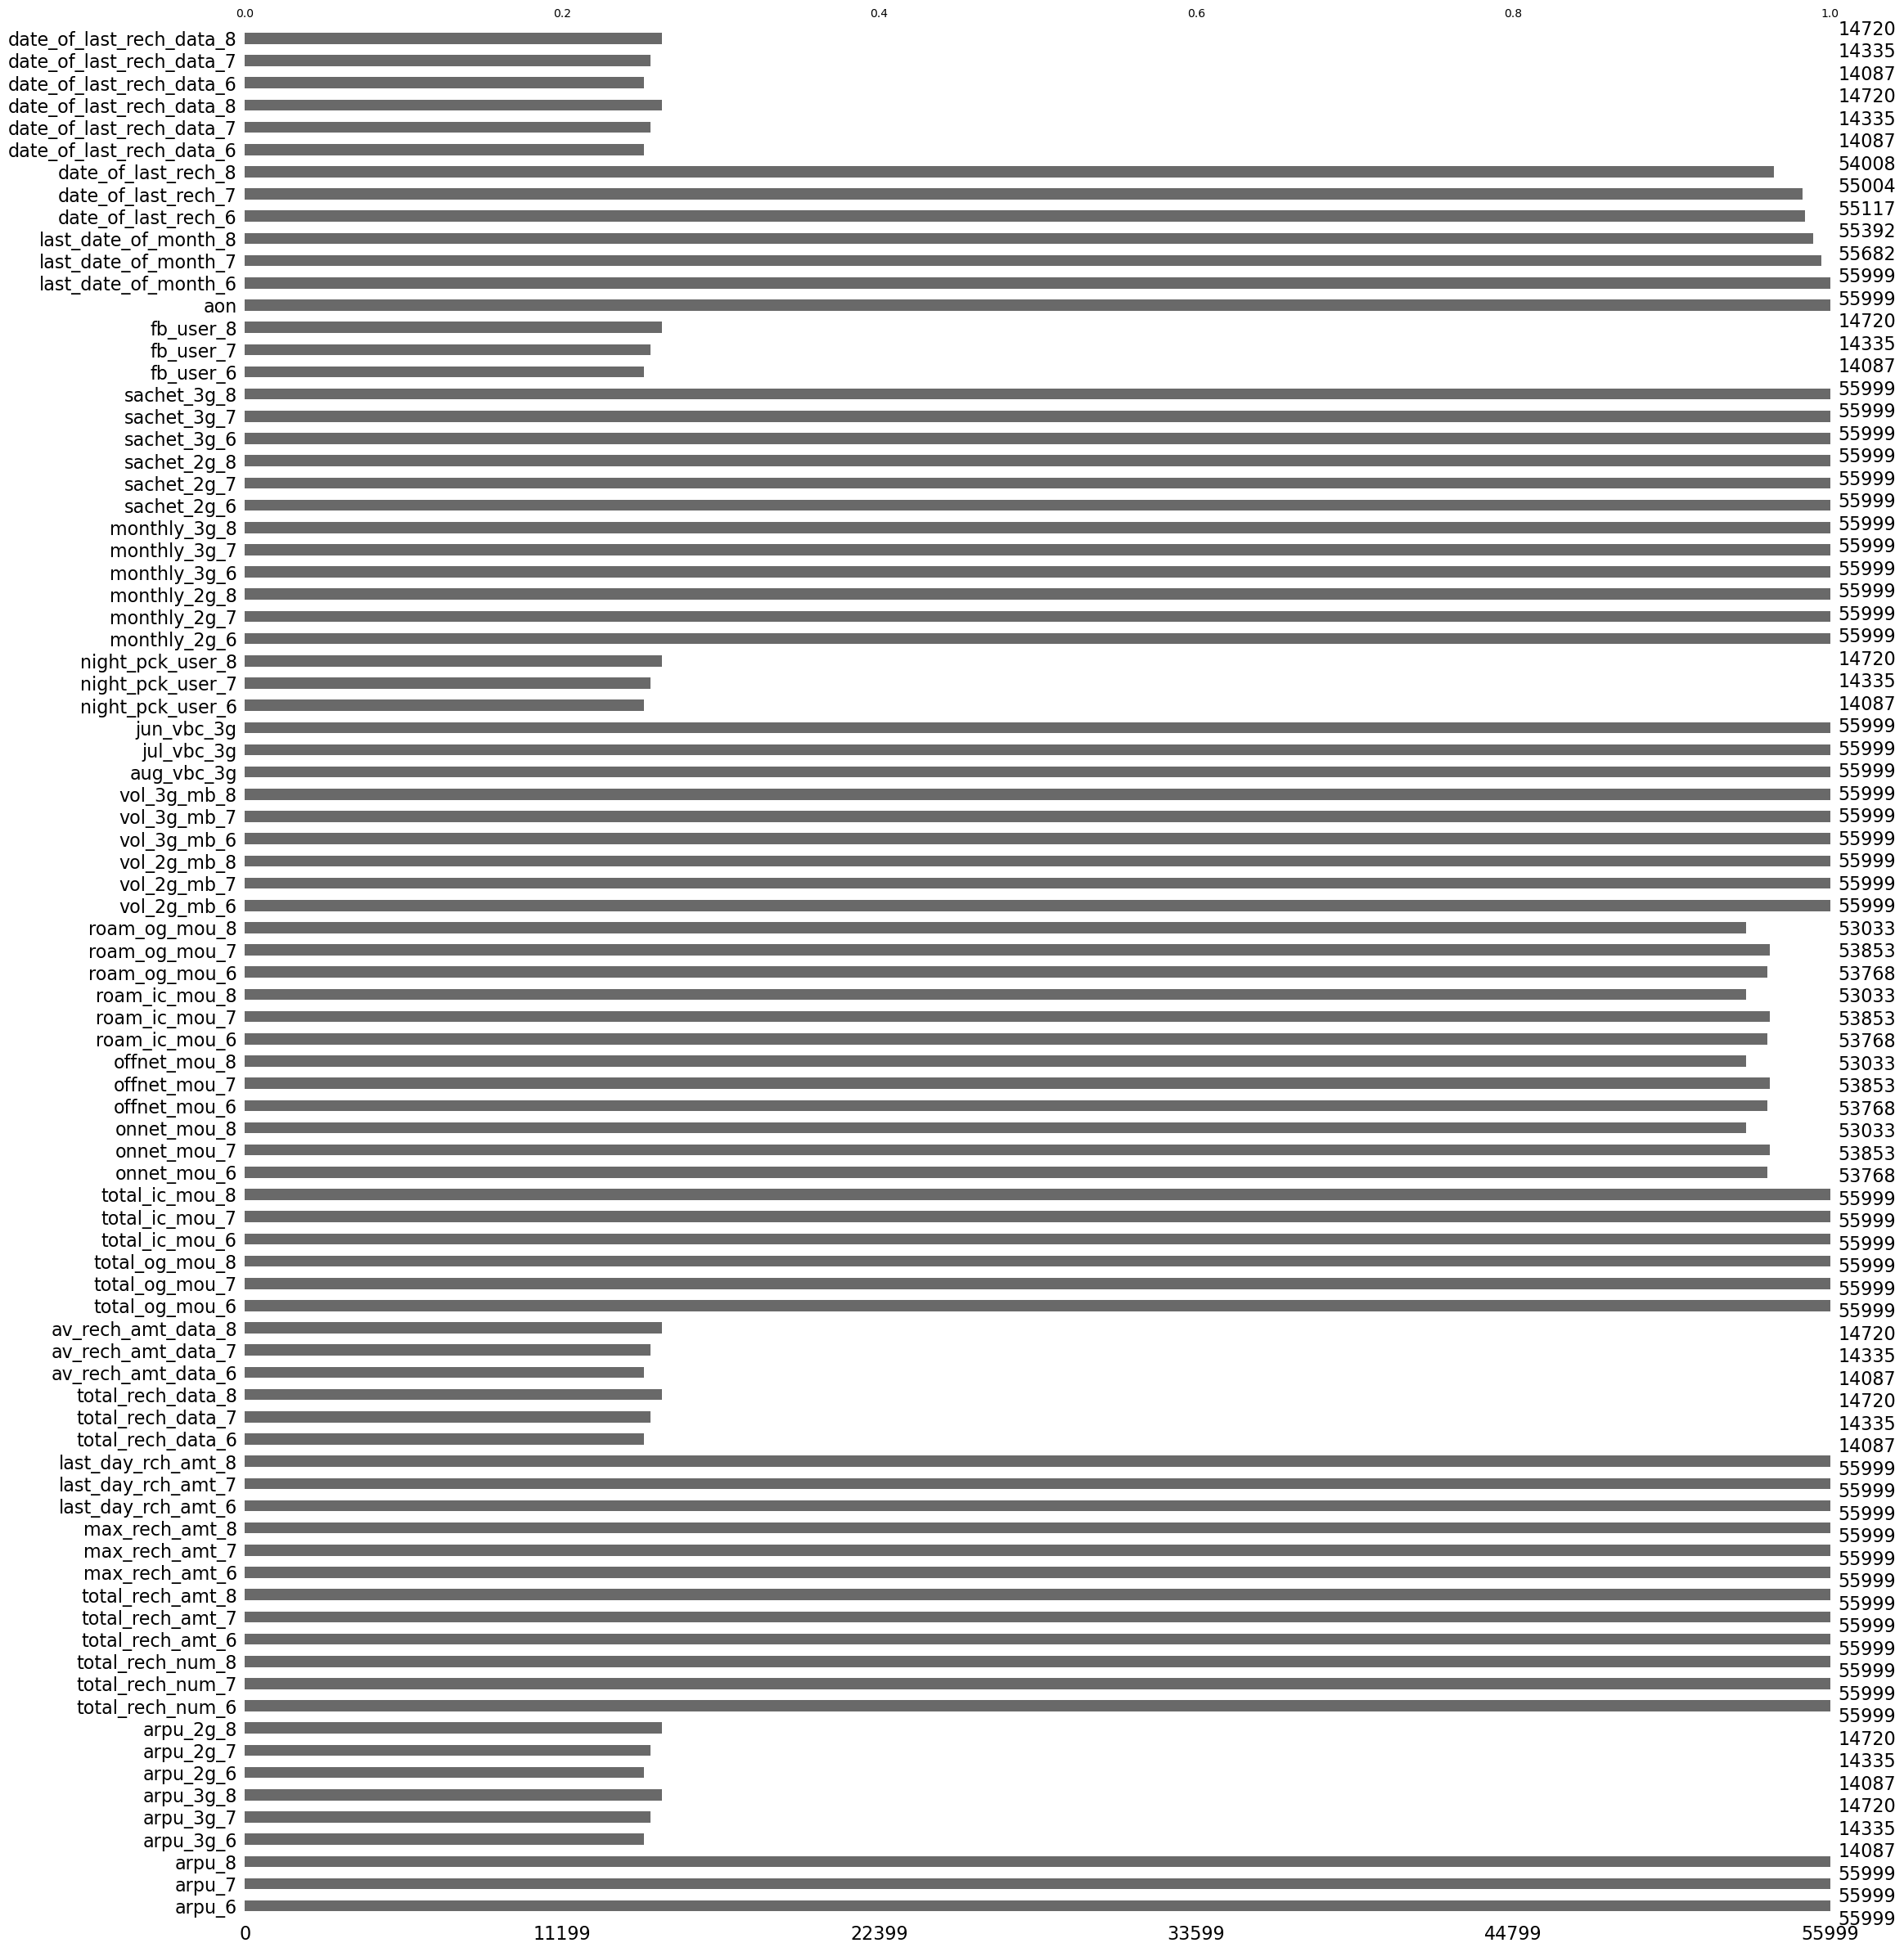

In [34]:
msno.bar(X_train)

<Axes: >

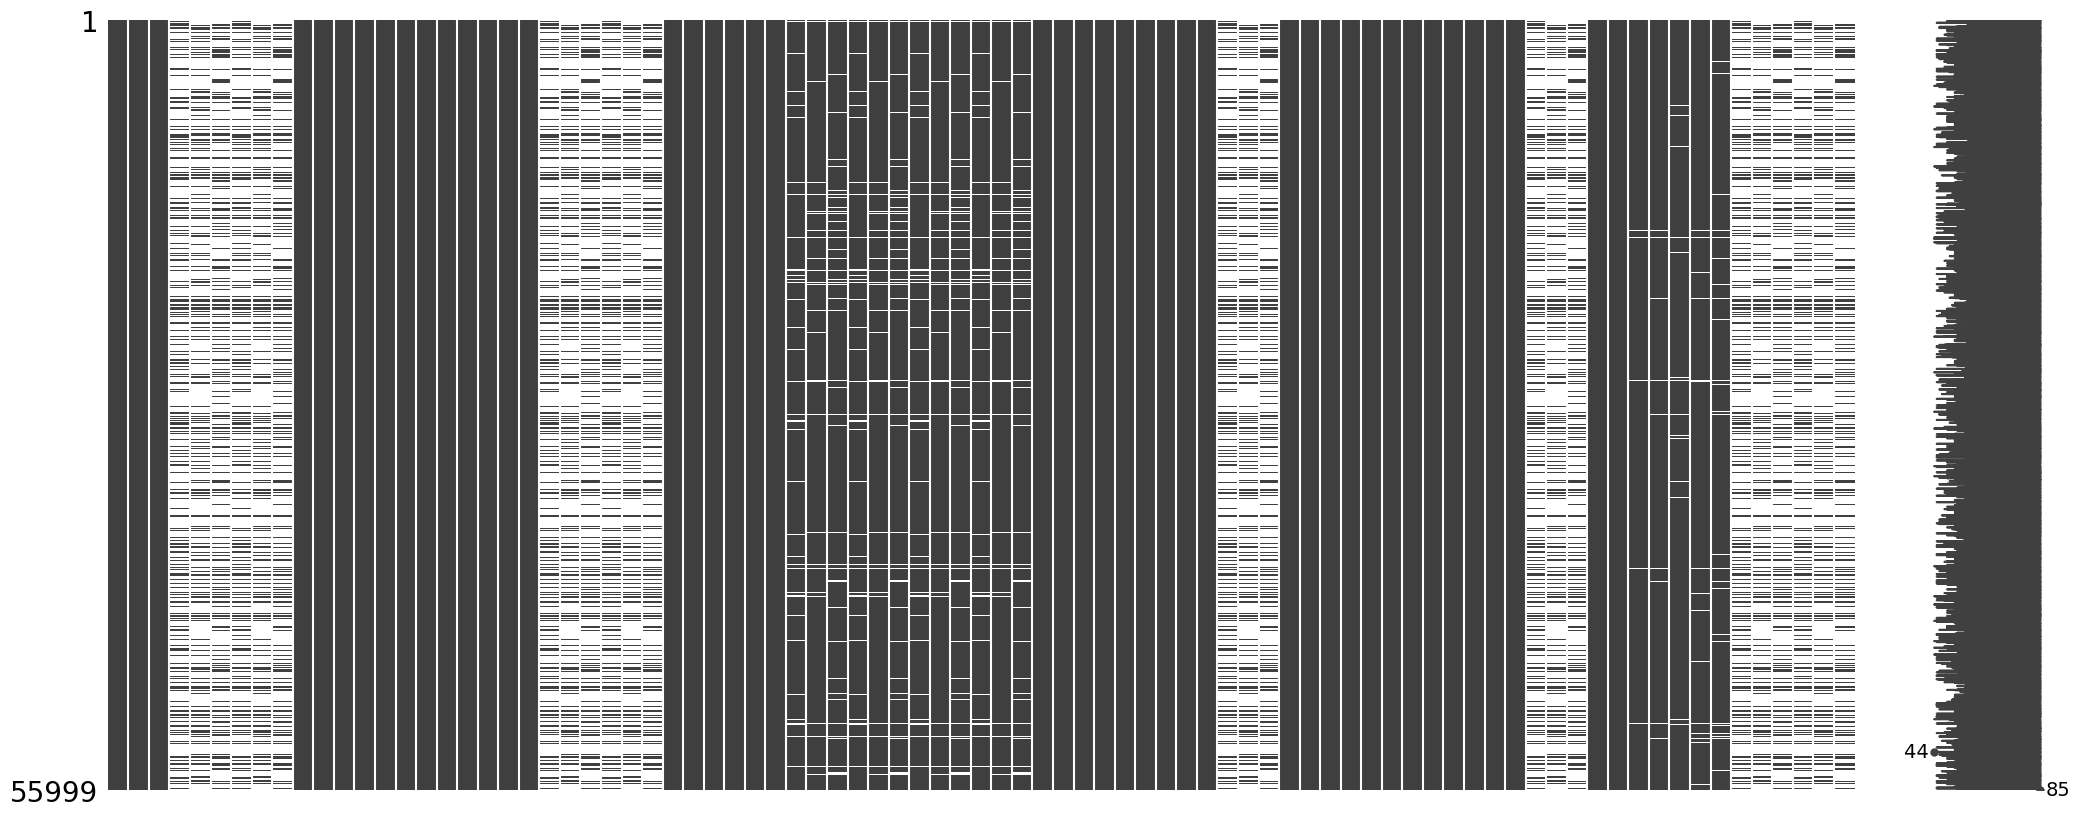

In [35]:
msno.matrix(X_train)

In [36]:
# Calculating Missing Data Percentage for Each Feature
missing_data_percent = 100*X_train.isnull().sum()/len(y_train)
missing_data_percent

arpu_6                       0.000000
arpu_7                       0.000000
arpu_8                       0.000000
arpu_3g_6                   74.844194
arpu_3g_7                   74.401329
                              ...    
date_of_last_rech_data_7    74.401329
date_of_last_rech_data_8    73.713816
date_of_last_rech_data_6    74.844194
date_of_last_rech_data_7    74.401329
date_of_last_rech_data_8    73.713816
Length: 85, dtype: float64

In [37]:
# Filtering Features with Acceptable Missing Data
new_vars = missing_data_percent[missing_data_percent.le(40)].index
new_vars

Index(['arpu_6', 'arpu_7', 'arpu_8', 'total_rech_num_6', 'total_rech_num_7',
       'total_rech_num_8', 'total_rech_amt_6', 'total_rech_amt_7',
       'total_rech_amt_8', 'max_rech_amt_6', 'max_rech_amt_7',
       'max_rech_amt_8', 'last_day_rch_amt_6', 'last_day_rch_amt_7',
       'last_day_rch_amt_8', 'total_og_mou_6', 'total_og_mou_7',
       'total_og_mou_8', 'total_ic_mou_6', 'total_ic_mou_7', 'total_ic_mou_8',
       'onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7',
       'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8',
       'vol_2g_mb_6', 'vol_2g_mb_7', 'vol_2g_mb_8', 'vol_3g_mb_6',
       'vol_3g_mb_7', 'vol_3g_mb_8', 'aug_vbc_3g', 'jul_vbc_3g', 'jun_vbc_3g',
       'monthly_2g_6', 'monthly_2g_7', 'monthly_2g_8', 'monthly_3g_6',
       'monthly_3g_7', 'monthly_3g_8', 'sachet_2g_6', 'sachet_2g_7',
       'sachet_2g_8', 'sachet_3g_6', 'sachet_3g_7', 'sachet_3g_8', 'aon',
    

In [38]:
# Creating a Filtered Training Set with Selected Features
X_train_filtered = X_train[new_vars]
X_train_filtered.shape

(55999, 61)

## Feature engineering
This step is essential for performing date-based feature engineering or calculating time intervals.

In [40]:
# Convert date columns to datetime format
date_cols = ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
             'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']

for col in date_cols:
    X_train[col] = pd.to_datetime(X_train[col], errors='coerce')

# Check the result
X_train[date_cols].head()


,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8
id,,,,,,
303,2014-06-30,2014-07-31,2014-08-31,2014-06-30,2014-07-31,2014-08-31
2156,2014-06-30,2014-07-31,2014-08-31,2014-06-21,2014-07-23,2014-08-15
63650,2014-06-30,2014-07-31,2014-08-31,2014-06-30,2014-07-30,2014-08-29
68823,2014-06-30,2014-07-31,2014-08-31,2014-06-25,2014-07-21,2014-08-24
49063,2014-06-30,2014-07-31,2014-08-31,2014-06-17,2014-07-19,2014-08-20


### Handling Missing Dates with Linear Interpolation
- This step helps fill in missing dates, preserving temporal continuity for better analysis and modeling.

In [42]:
# Now try interpolation

for col in date_cols:
    X_train[col] = X_train[col].interpolate(method='linear')

X_train[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 55999 entries, 303 to 55934
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   last_date_of_month_6  55999 non-null  datetime64[ns]
 1   last_date_of_month_7  55999 non-null  datetime64[ns]
 2   last_date_of_month_8  55999 non-null  datetime64[ns]
 3   date_of_last_rech_6   55999 non-null  datetime64[ns]
 4   date_of_last_rech_7   55999 non-null  datetime64[ns]
 5   date_of_last_rech_8   55999 non-null  datetime64[ns]
dtypes: datetime64[ns](6)
memory usage: 3.0 MB


### Extracting the Day Component from Date Columns
- This step simplifies date features, making them more useful for models that may not need full date information but can benefit from day-based patterns.

In [44]:
# Extract only the day component
date_cols = ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
             'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']

for col in date_cols:
    X_train[col] = X_train[col].dt.day


In [45]:
# Check the result
X_train[date_cols].head()

,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8
id,,,,,,
303,30,31,31,30,31,31
2156,30,31,31,21,23,15
63650,30,31,31,30,30,29
68823,30,31,31,25,21,24
49063,30,31,31,17,19,20


In [46]:
X_train_filtered = X_train[new_vars]
X_train_filtered.shape

(55999, 61)

### Identifying Columns with Missing Values for Imputation

In [48]:
missing_data_percent = X_train_filtered.isnull().any()
impute_cols = missing_data_percent[missing_data_percent.gt(0)].index
impute_cols

Index(['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7',
       'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8'],
      dtype='object')

In [49]:
object_cols = ['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7',
       'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8']

X_train_filtered[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 55999 entries, 303 to 55934
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   onnet_mou_6    53768 non-null  float64
 1   onnet_mou_7    53853 non-null  float64
 2   onnet_mou_8    53033 non-null  float64
 3   offnet_mou_6   53768 non-null  float64
 4   offnet_mou_7   53853 non-null  float64
 5   offnet_mou_8   53033 non-null  float64
 6   roam_ic_mou_6  53768 non-null  float64
 7   roam_ic_mou_7  53853 non-null  float64
 8   roam_ic_mou_8  53033 non-null  float64
 9   roam_og_mou_6  53768 non-null  float64
 10  roam_og_mou_7  53853 non-null  float64
 11  roam_og_mou_8  53033 non-null  float64
dtypes: float64(12)
memory usage: 5.6 MB


### Imputing Missing Values with a Constant Value
**`SimpleImputer`:** Fills missing values in the specified columns.  
- **Imputation Strategy:**  
  - **`strategy='constant'`:** Replaces missing values with a fixed value.  
  - **`fill_value=0`:** Sets the fill value to `0`, assuming missing data represents no activity or usage.  
- **Fitting and Transforming:**  
  - **`fit_transform`:** Learns and applies the imputation on training data. 

In [51]:
imp = SimpleImputer(strategy='constant', fill_value=0)
X_train_filtered[impute_cols] = imp.fit_transform(X_train_filtered[impute_cols])

### Visualizing Missing Data After Imputation

<Axes: >

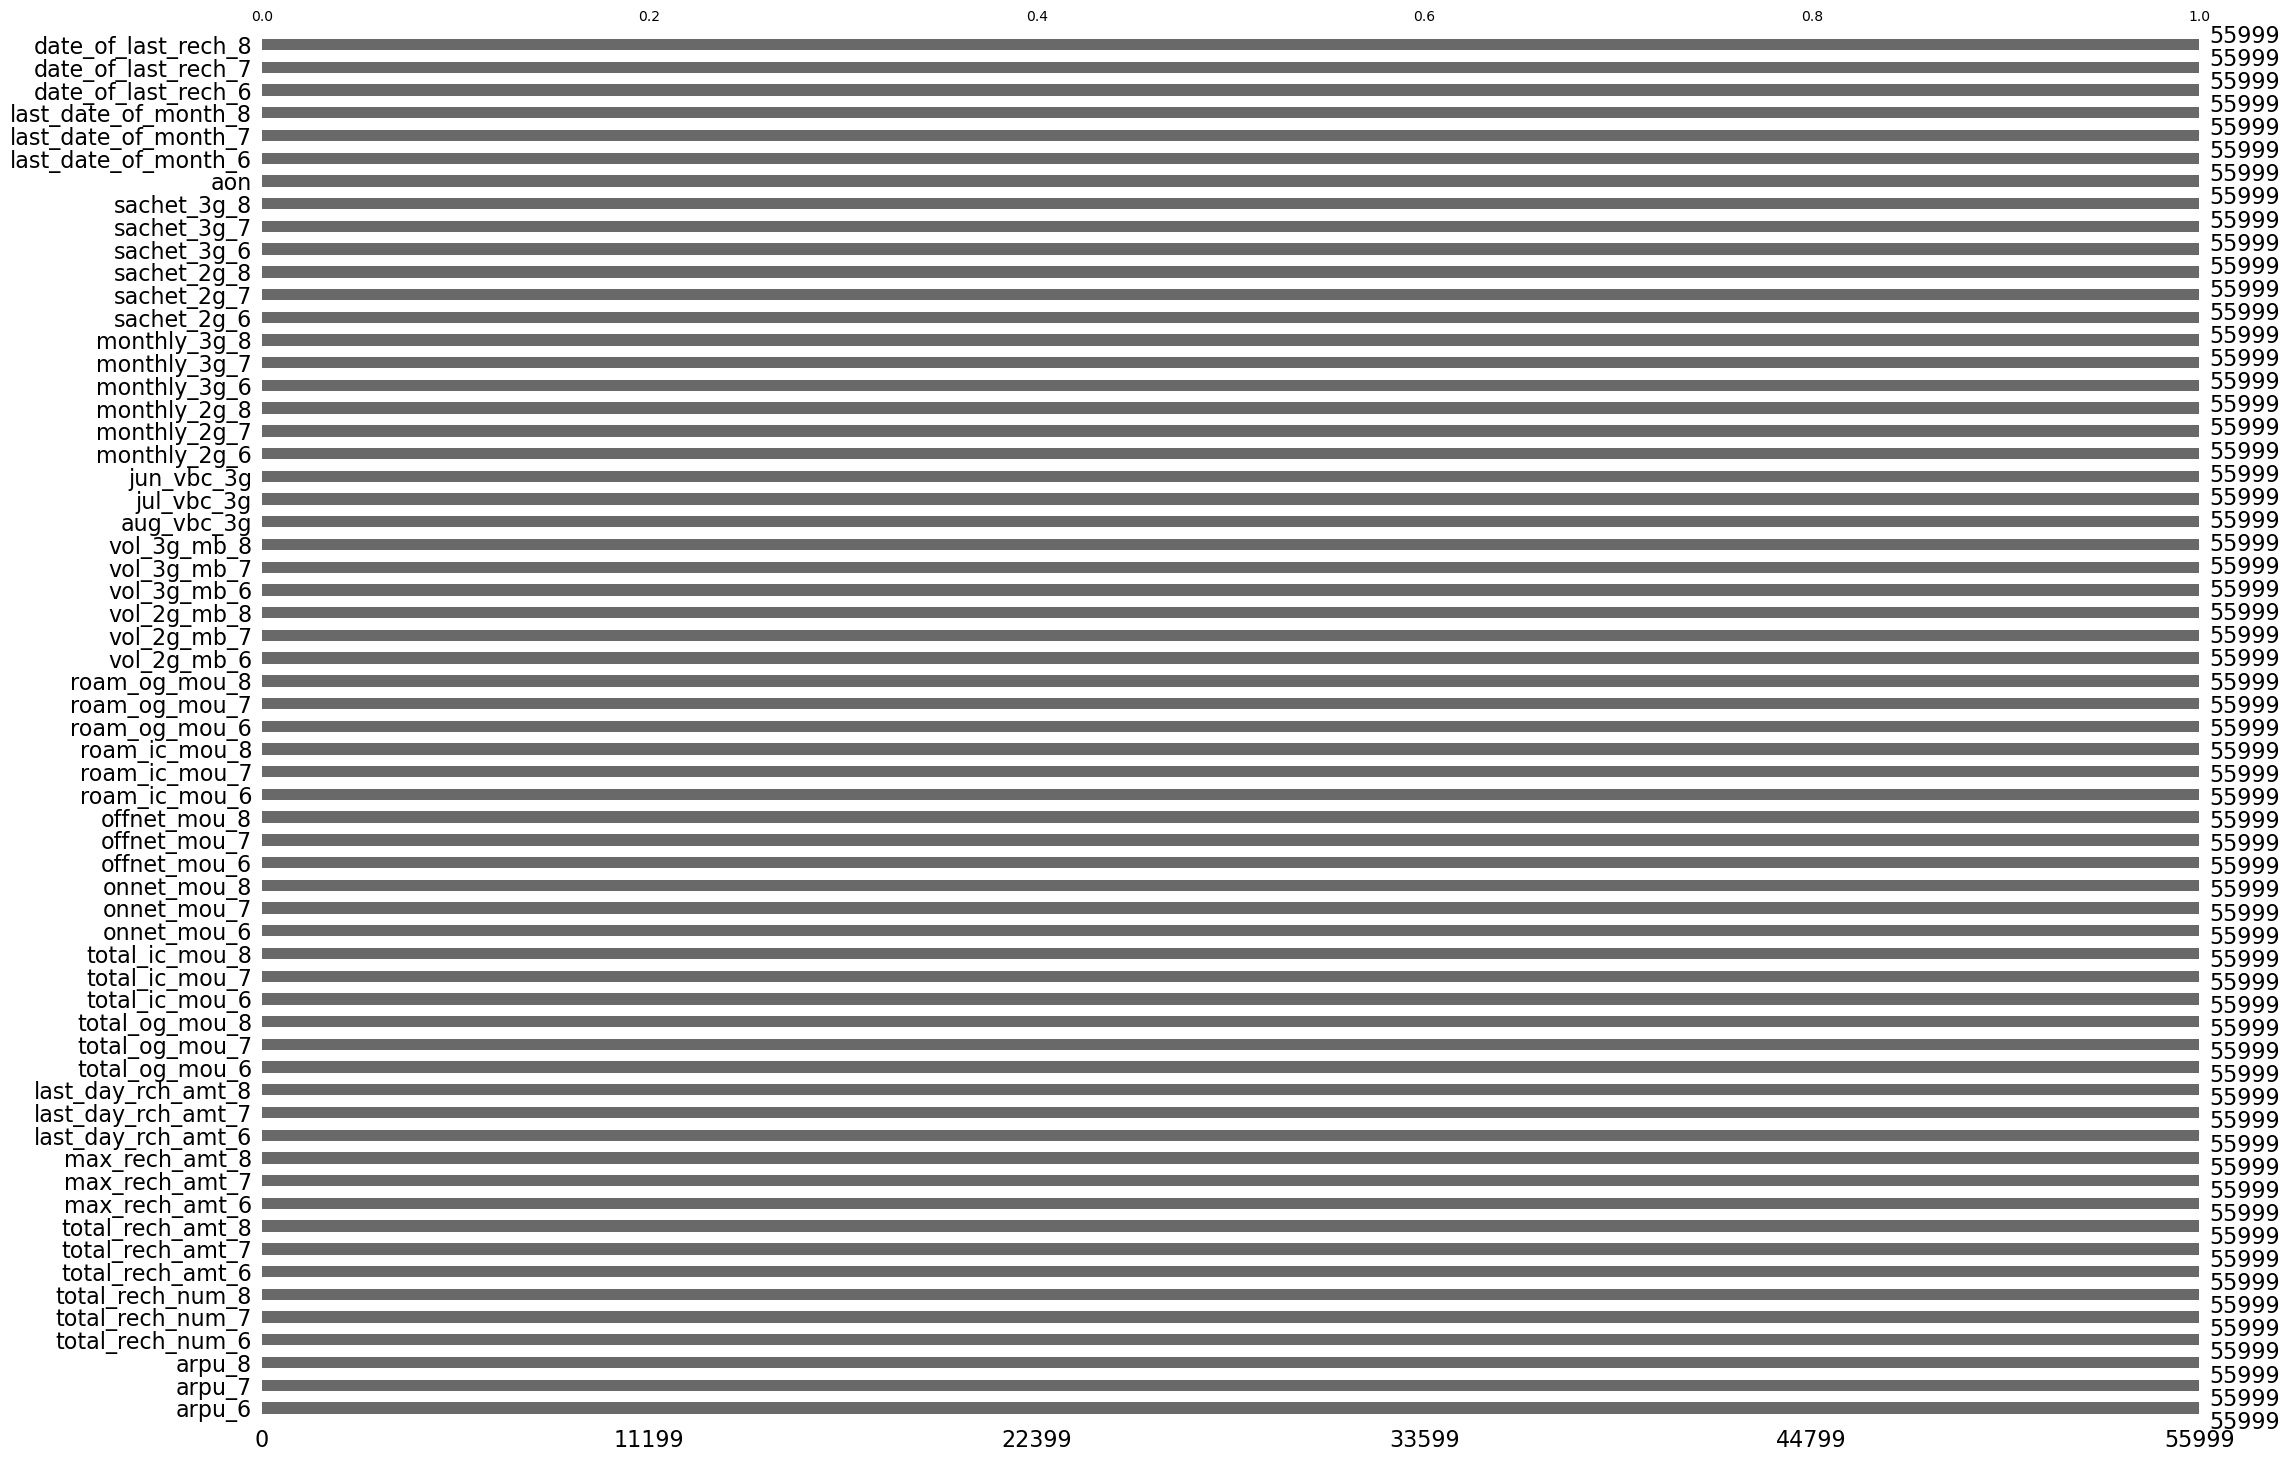

In [53]:
msno.bar(X_train_filtered)

In [54]:
X_train_filtered.describe()

,arpu_6,arpu_7,arpu_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8
count,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,...,55999.000000,55999.000000,55999.000000,55999.000000,55999.0,55999.0,55999.0,55999.000000,55999.000000,55999.000000
mean,283.587061,278.327492,278.661607,7.558742,7.700548,7.225825,328.124199,322.316166,323.702298,104.434186,...,0.075466,0.081823,0.086805,1219.695959,30.0,31.0,31.0,24.121484,25.495223,25.411632
std,343.695625,352.670266,362.633692,7.038836,7.036612,7.220396,414.309573,419.390480,439.316108,121.221710,...,0.580359,0.653233,0.703207,950.992337,0.0,0.0,0.0,6.109348,5.750016,6.072479
min,-2258.709000,-1289.715000,-945.808000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,180.000000,30.0,31.0,31.0,1.000000,1.000000,1.000000
25%,93.495000,86.955000,83.654500,3.000000,3.000000,3.000000,110.000000,100.000000,90.000000,30.000000,...,0.000000,0.000000,0.000000,468.000000,30.0,31.0,31.0,21.000000,23.000000,24.000000
50%,197.007000,191.910000,191.532000,6.000000,6.000000,5.000000,228.000000,220.000000,223.000000,110.000000,...,0.000000,0.000000,0.000000,868.000000,30.0,31.0,31.0,27.000000,27.000000,27.000000
75%,369.913000,364.916000,369.302500,9.000000,10.000000,9.000000,436.000000,429.000000,436.000000,120.000000,...,0.000000,0.000000,0.000000,1813.000000,30.0,31.0,31.0,29.000000,30.000000,30.000000
max,27731.088000,35145.834000,33543.624000,170.000000,138.000000,138.000000,35190.000000,40335.000000,45320.000000,4010.000000,...,29.000000,33.000000,41.000000,4337.000000,30.0,31.0,31.0,30.000000,31.000000,31.000000


# Step 3: Exploratory Data Analysis, Visualization & Preprocessing

### UNIVARIATE ANALYSIS
- to see the Individual features Distribution

Univariate Analysis: Feature Distributions


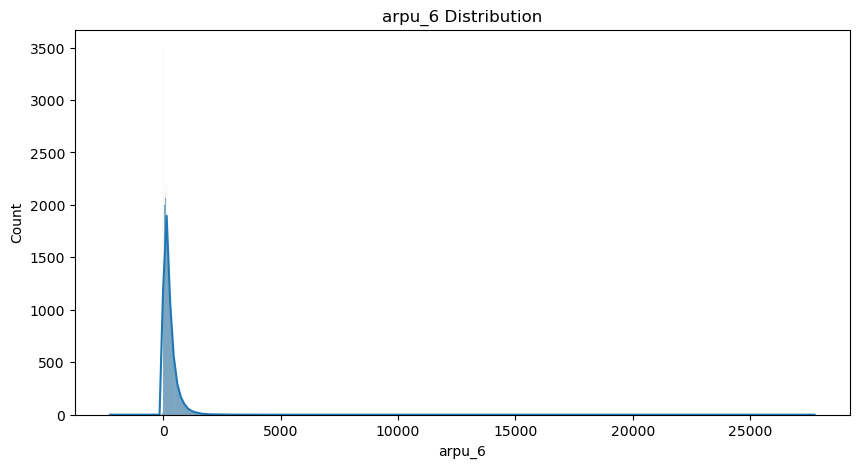

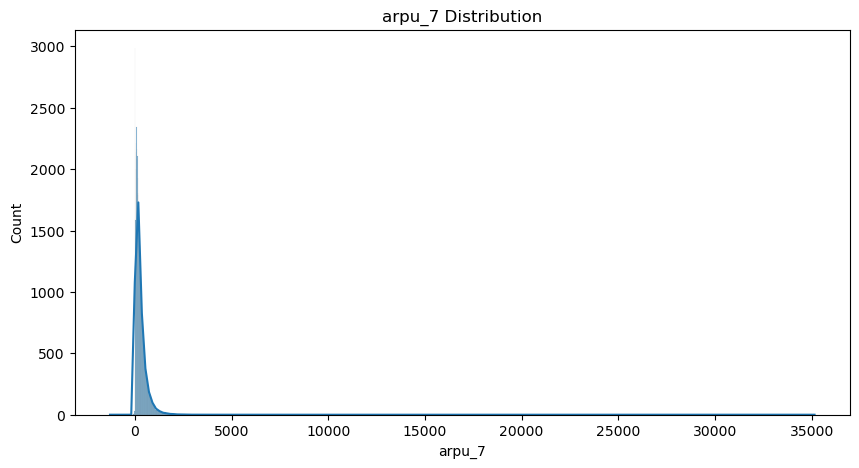

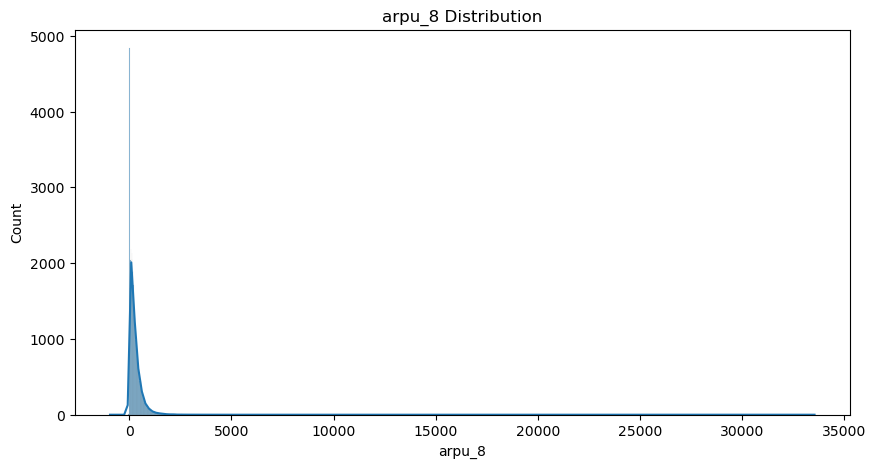

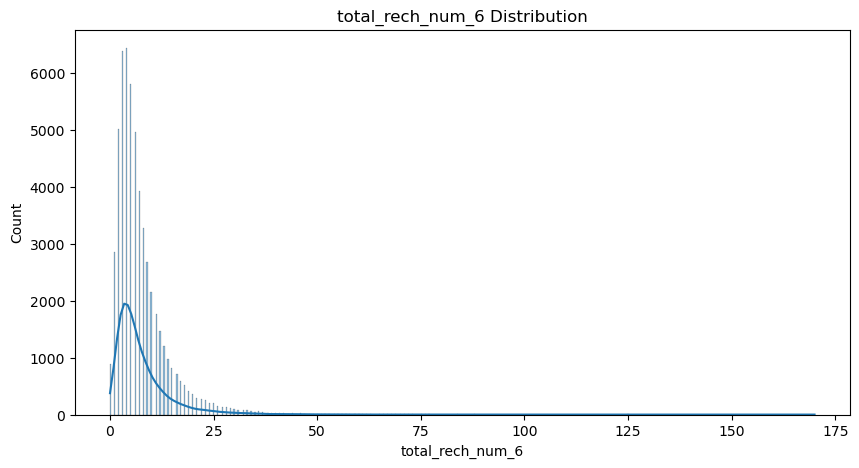

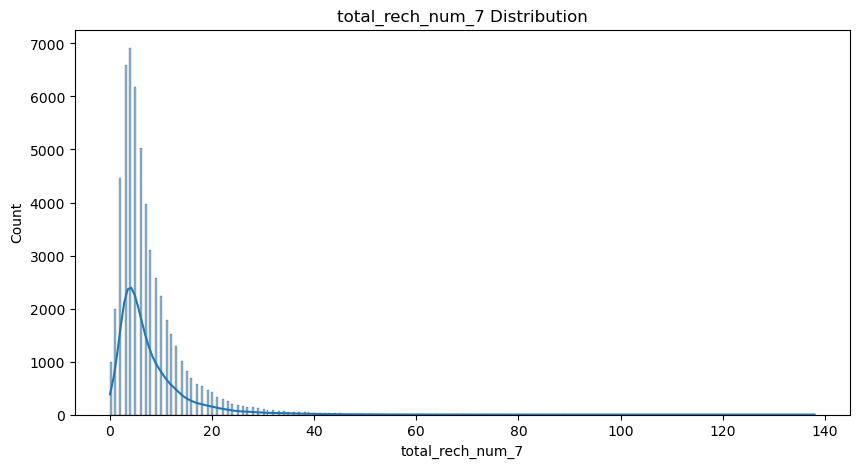

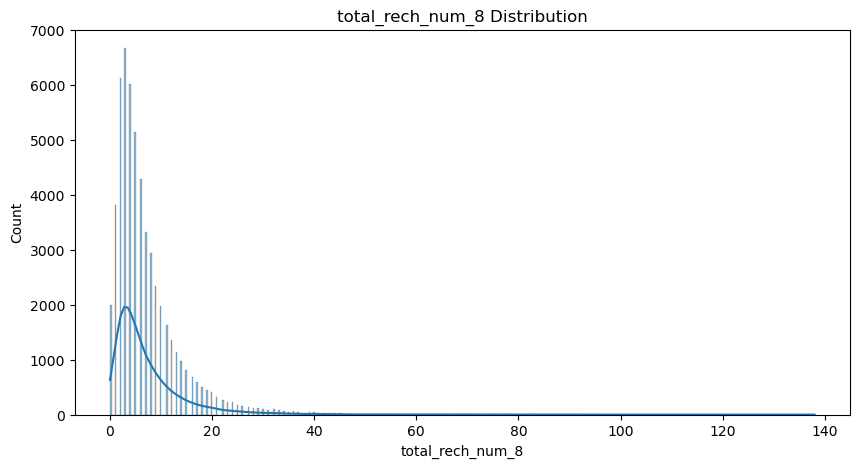

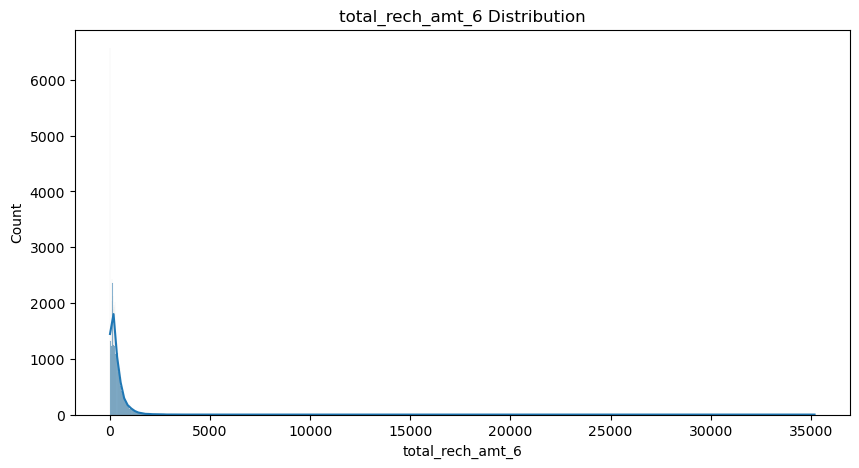

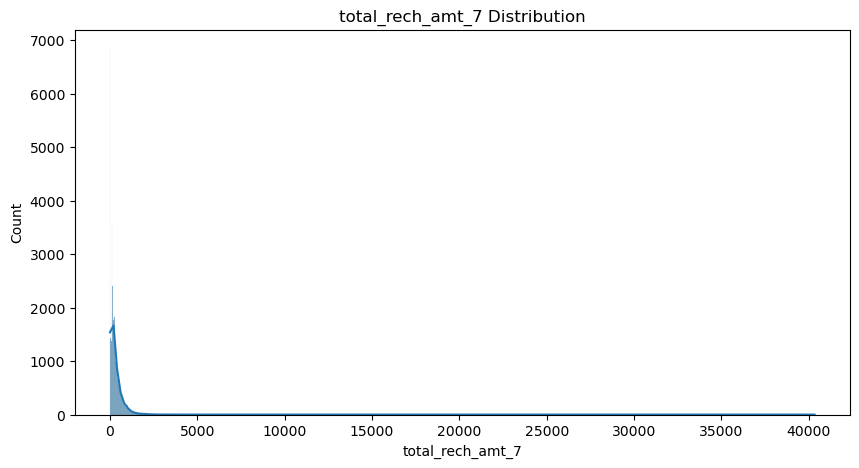

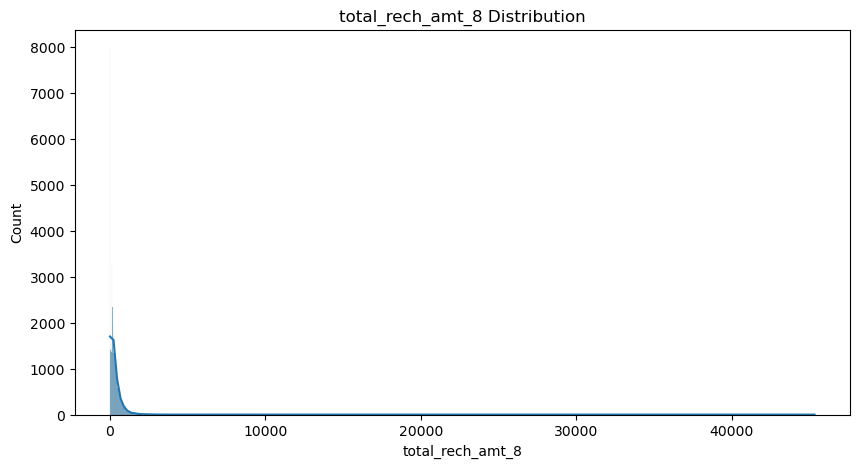

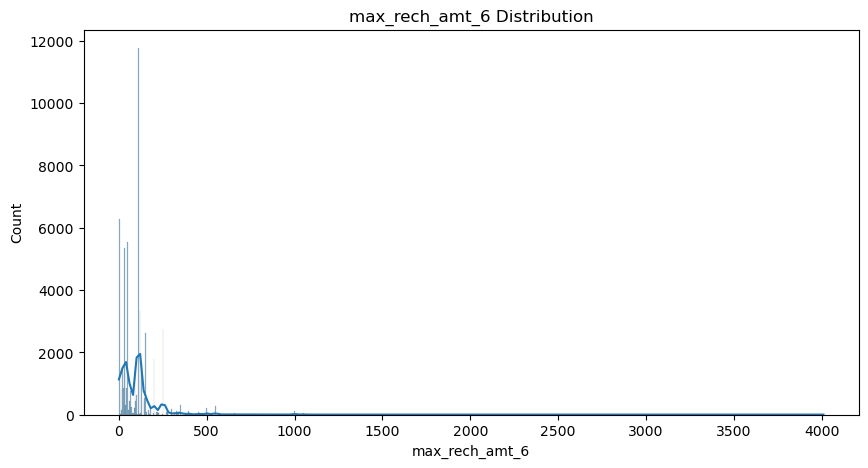

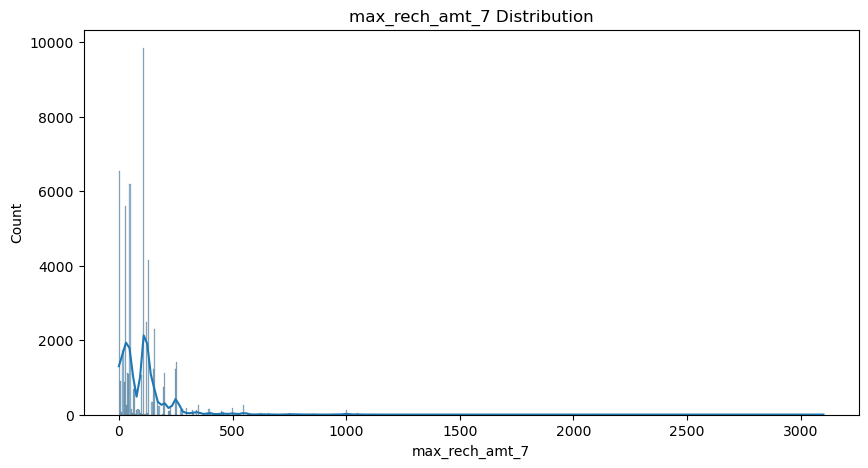

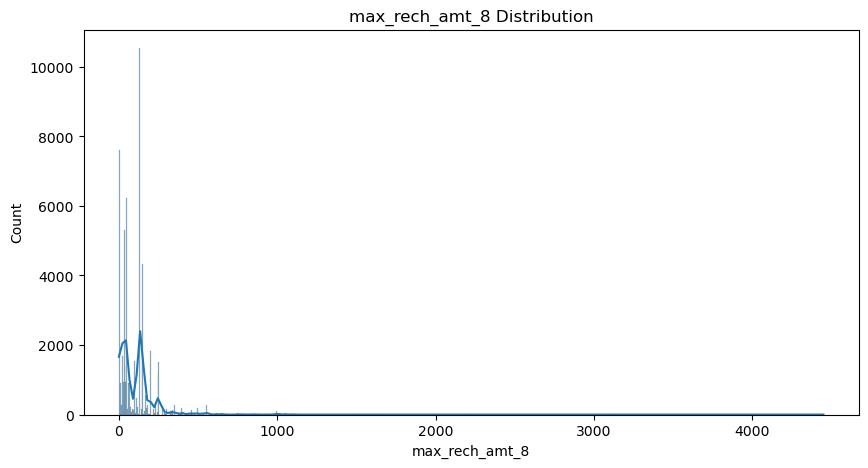

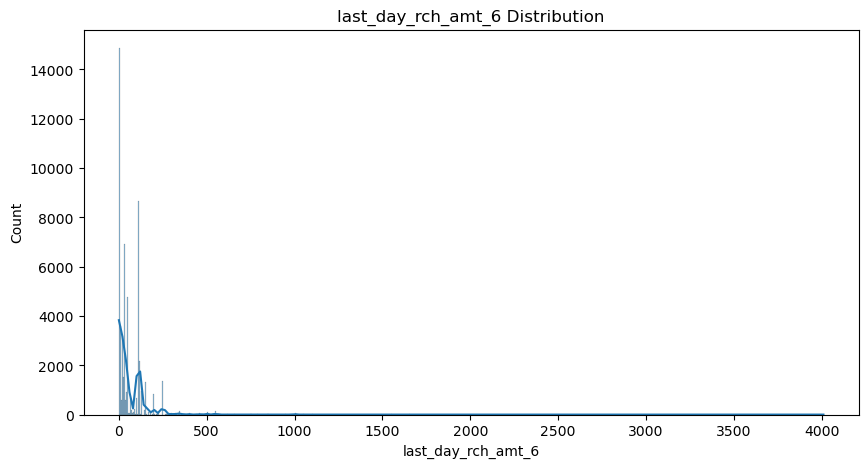

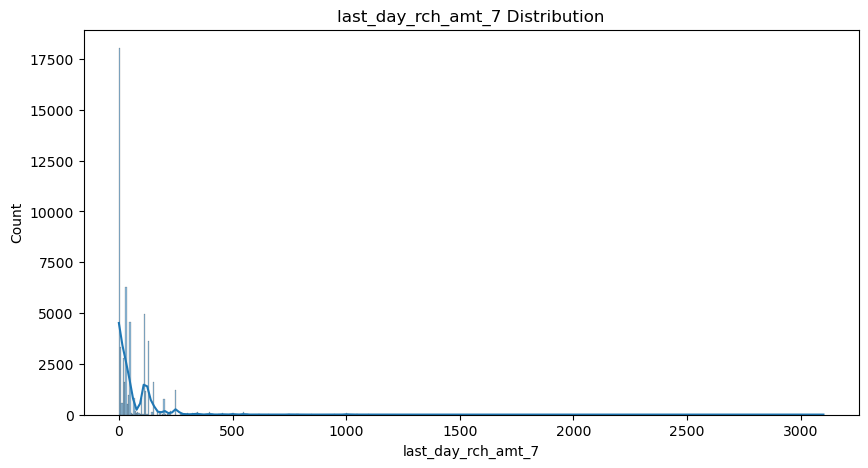

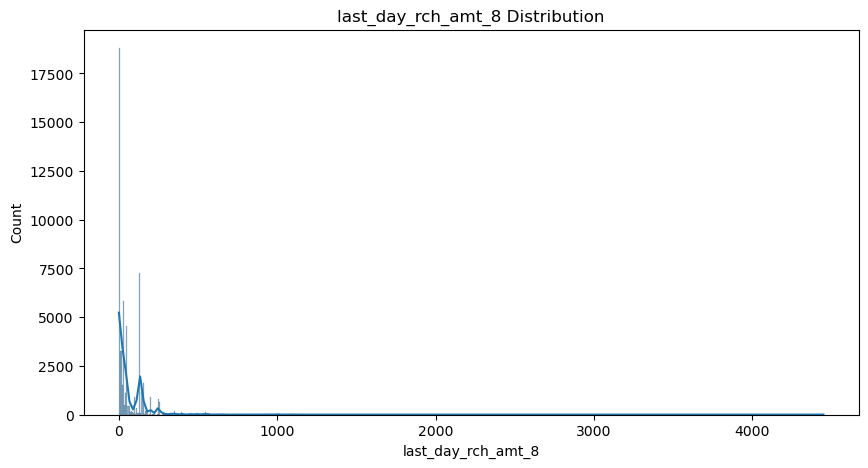

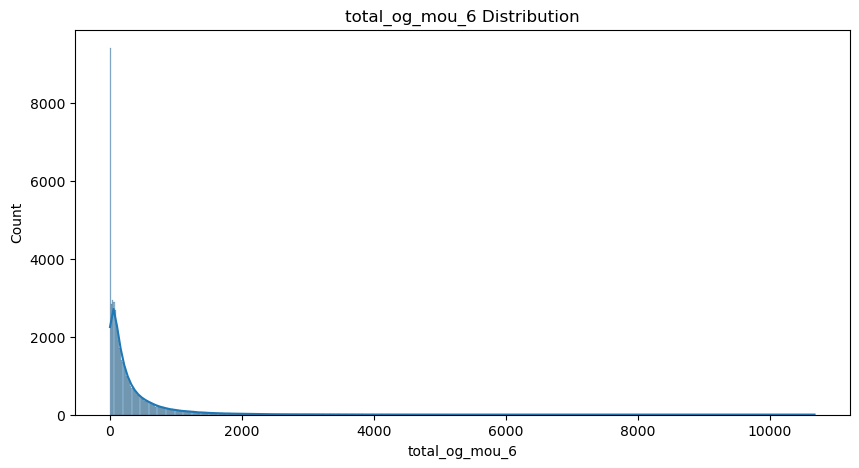

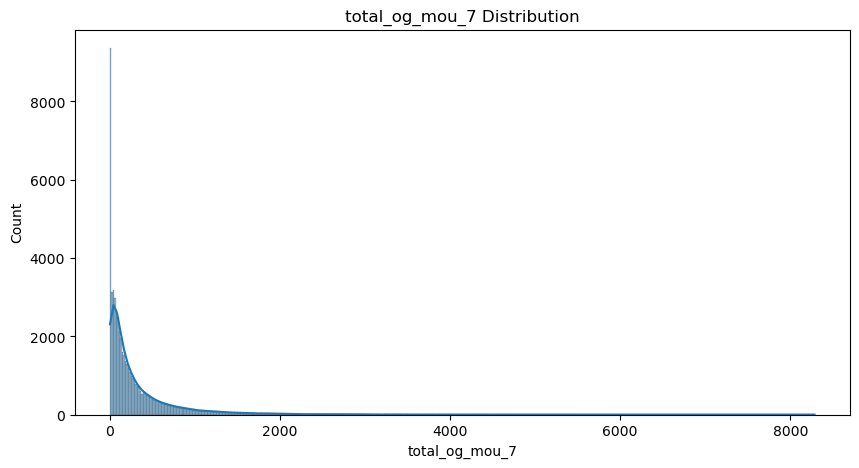

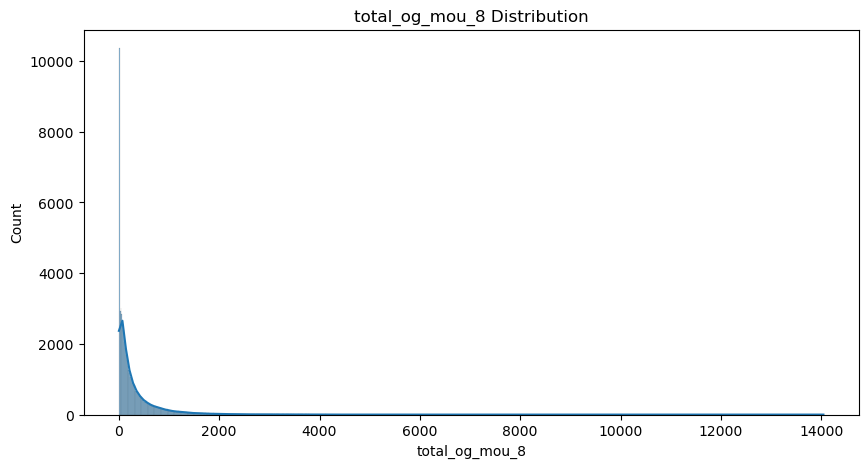

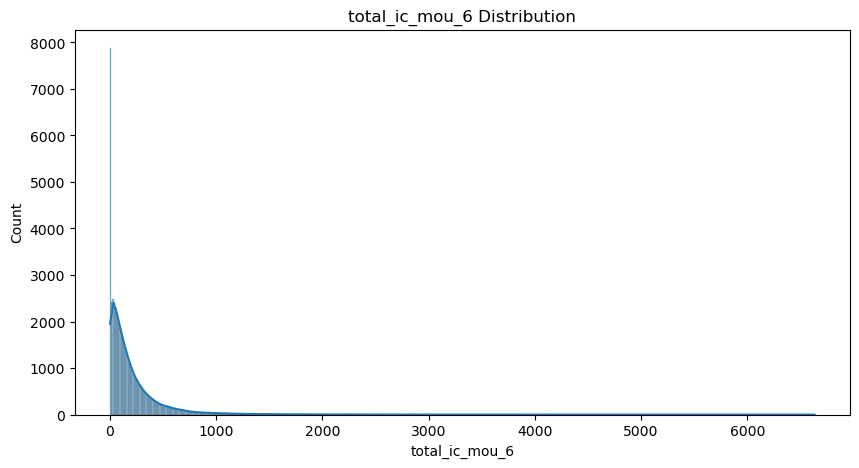

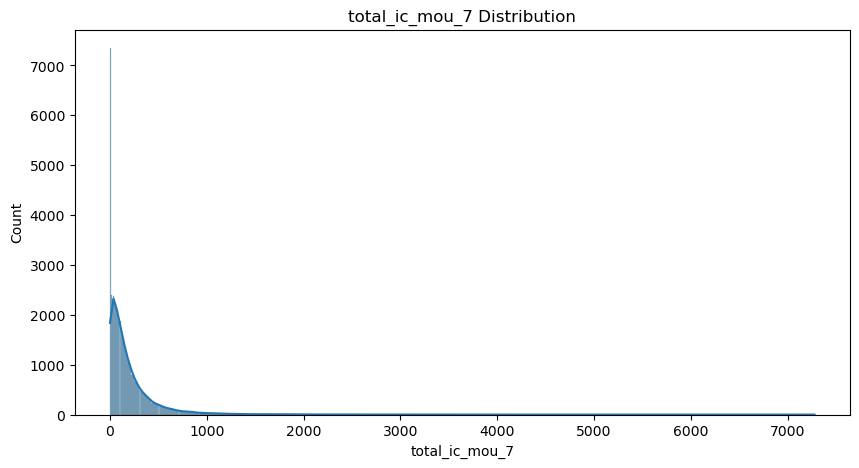

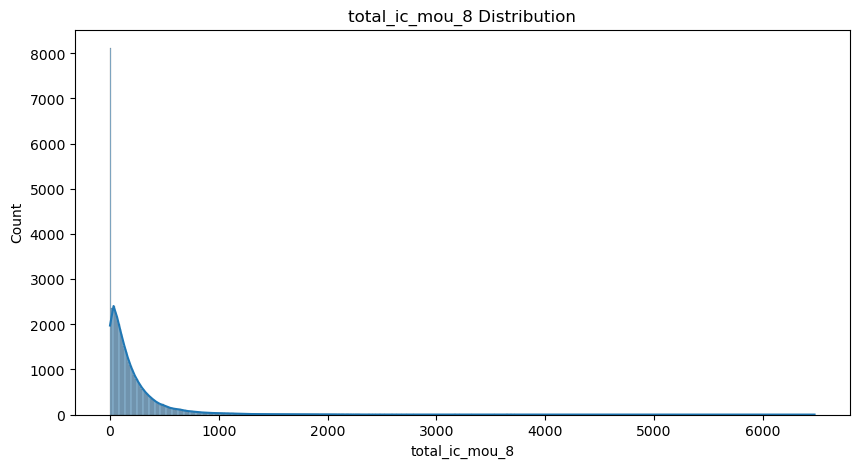

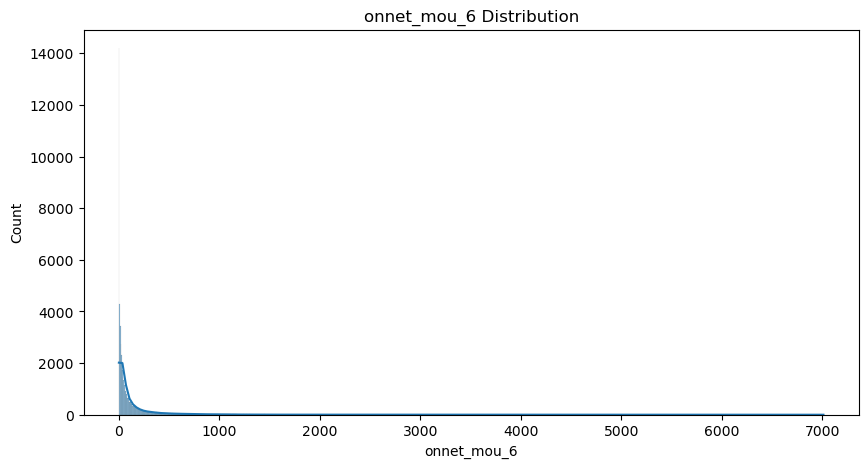

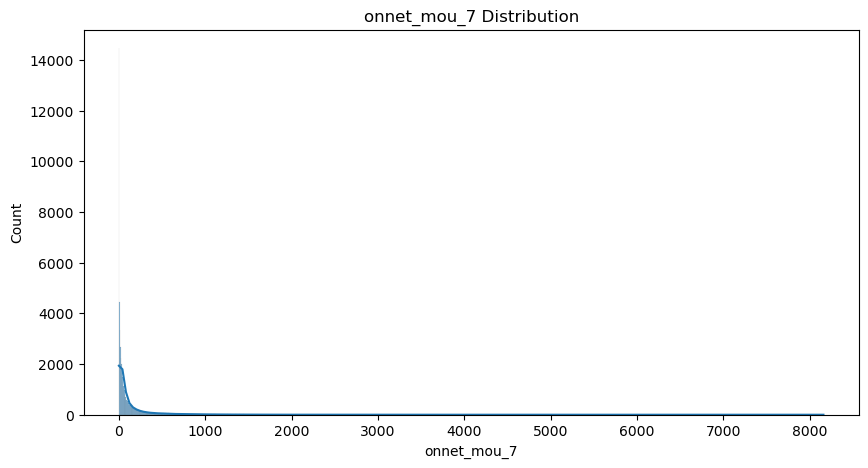

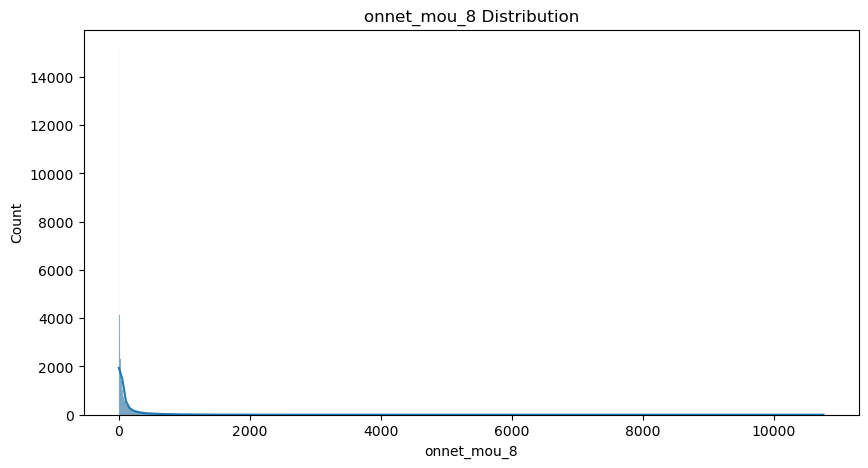

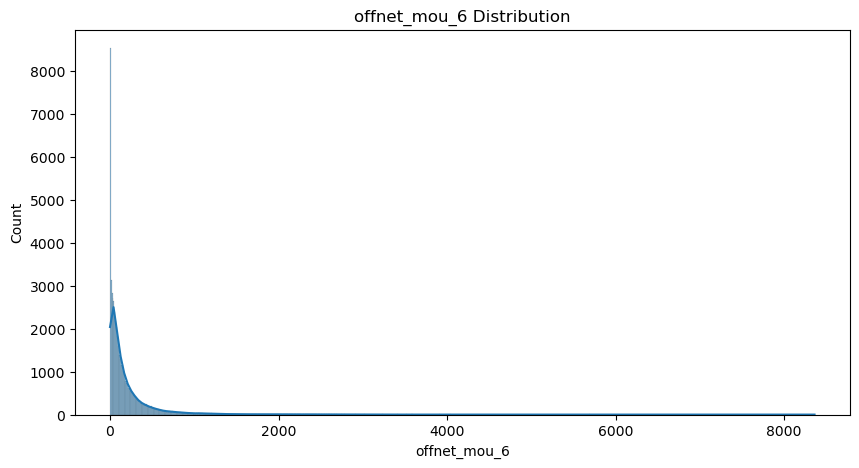

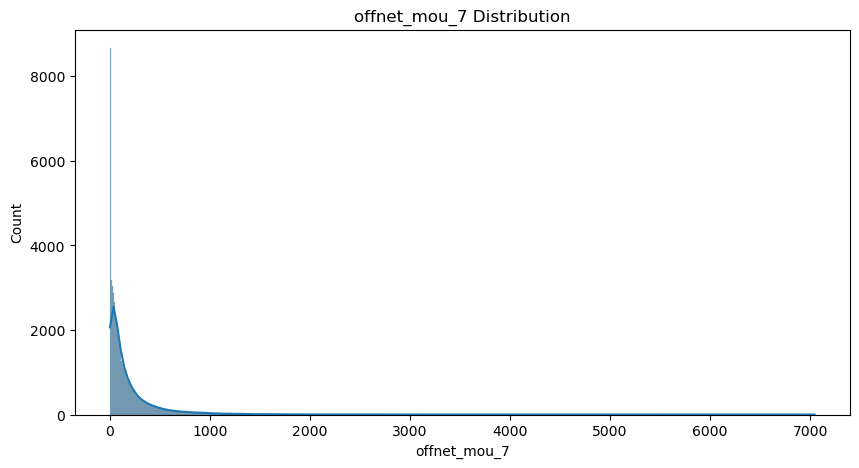

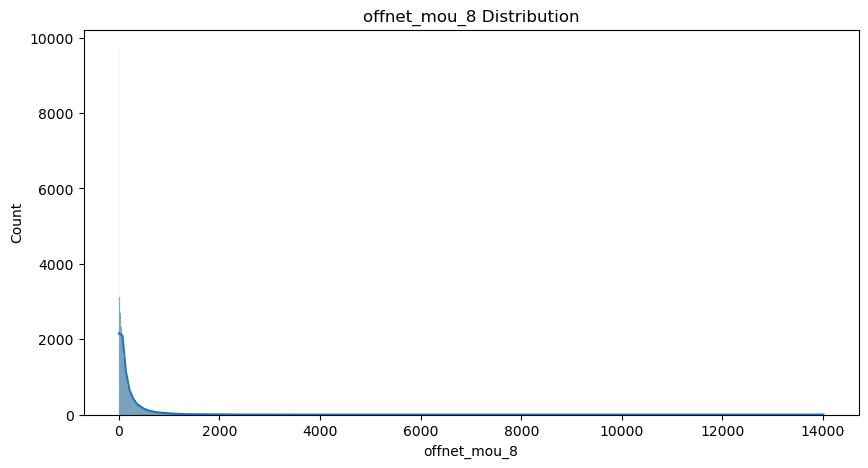

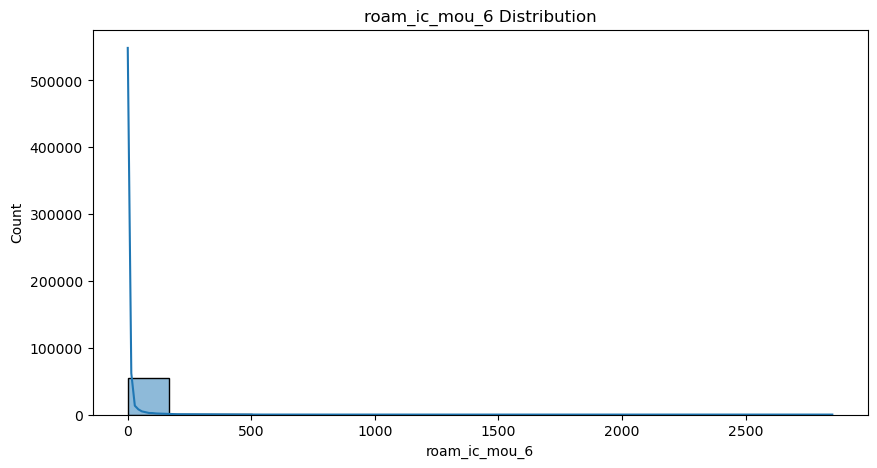

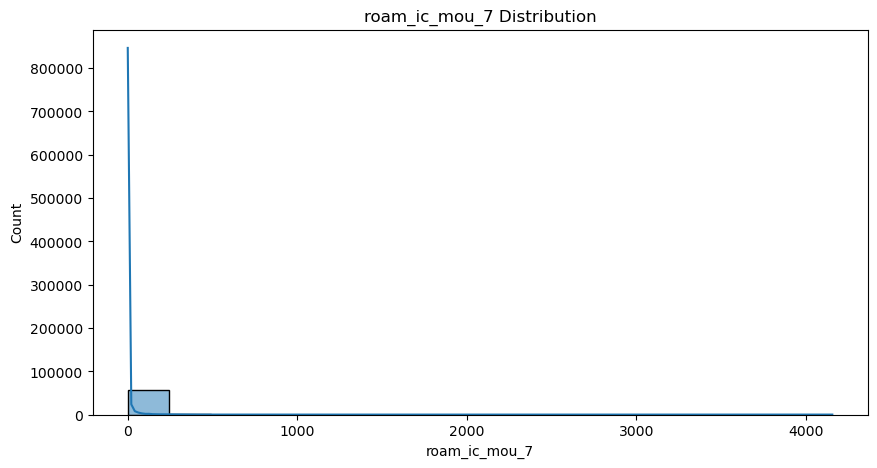

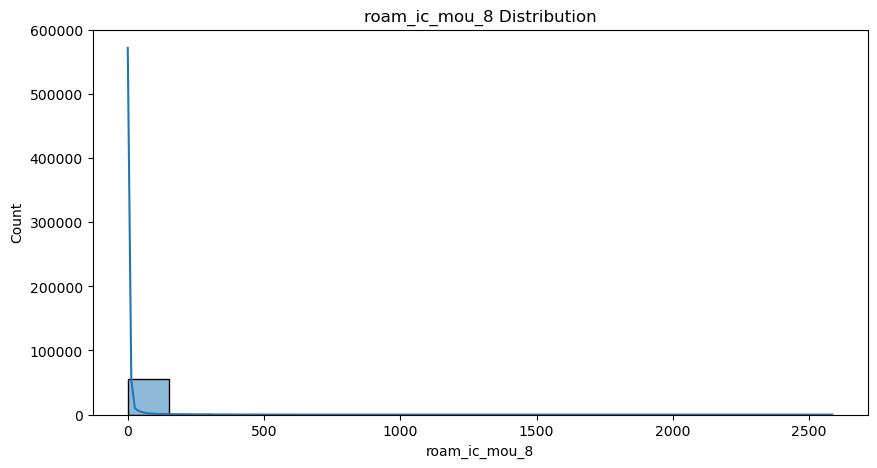

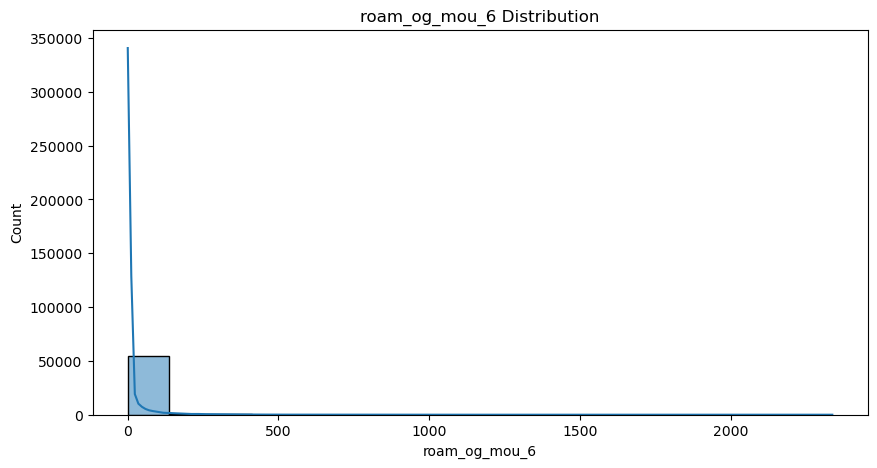

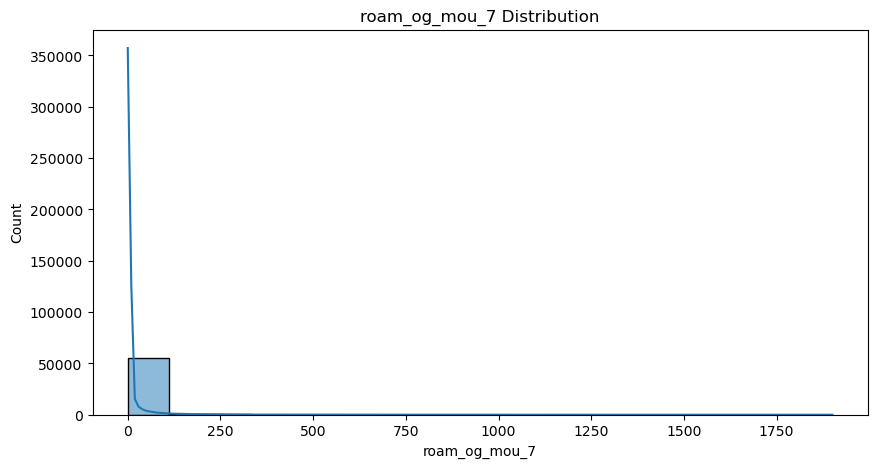

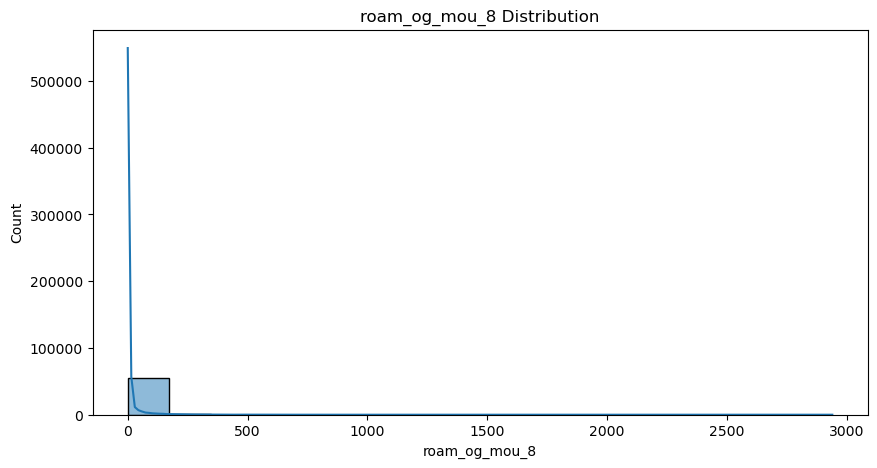

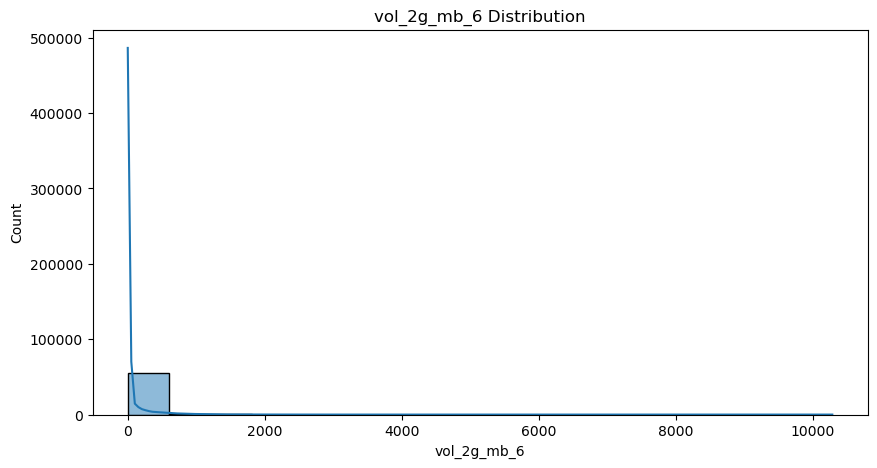

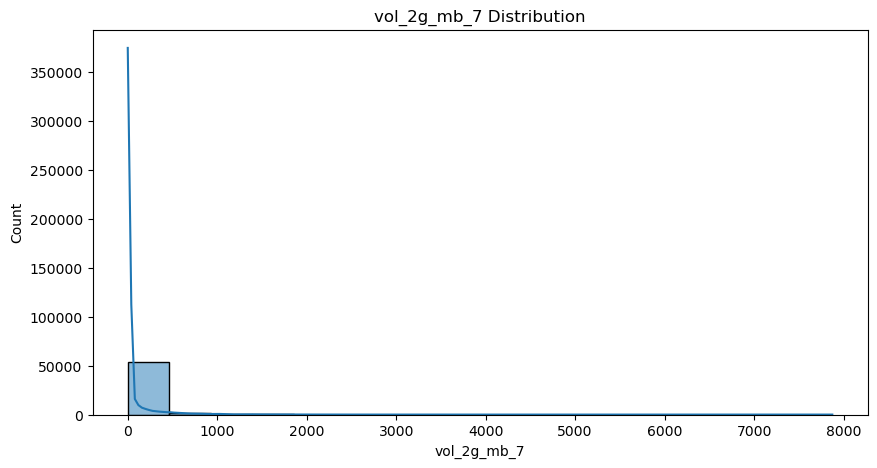

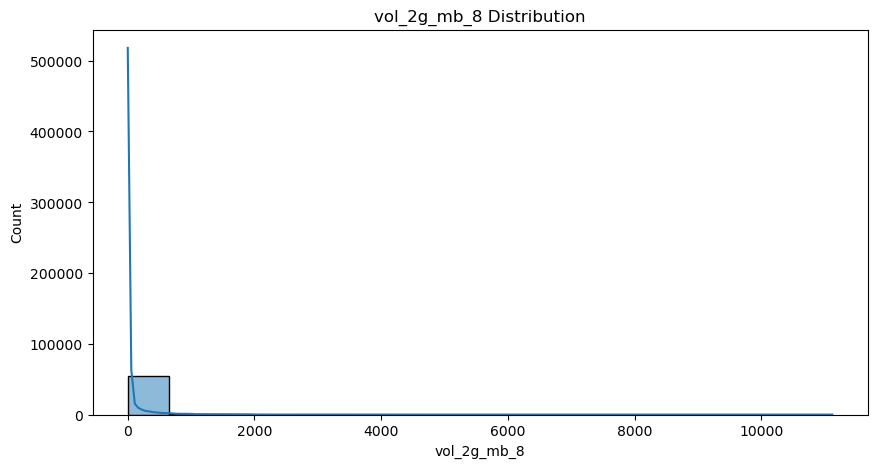

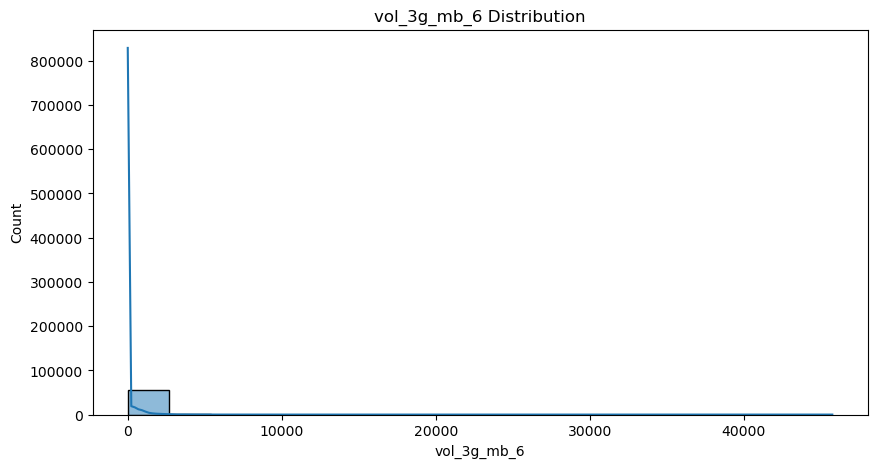

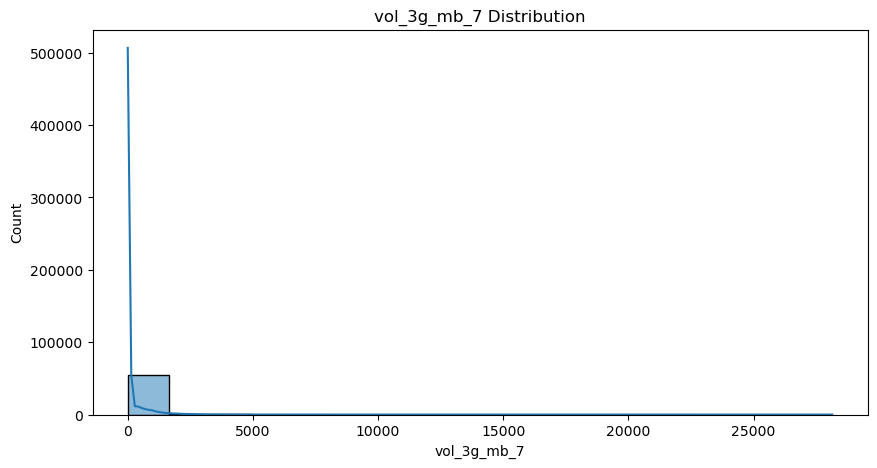

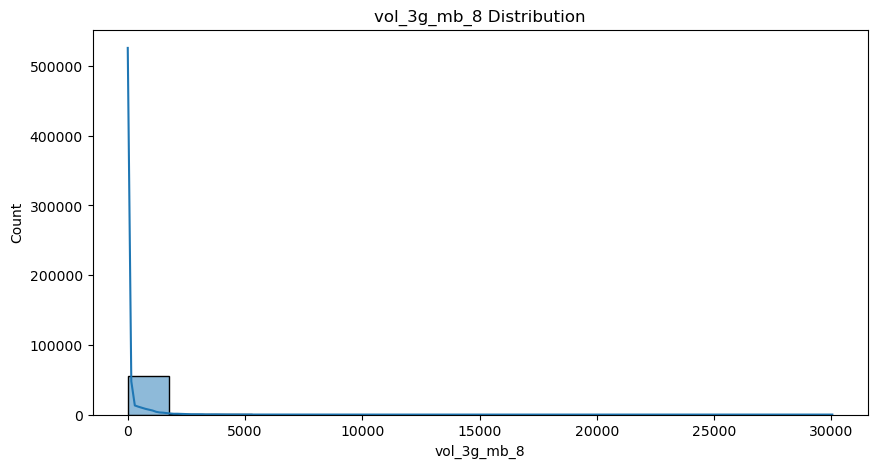

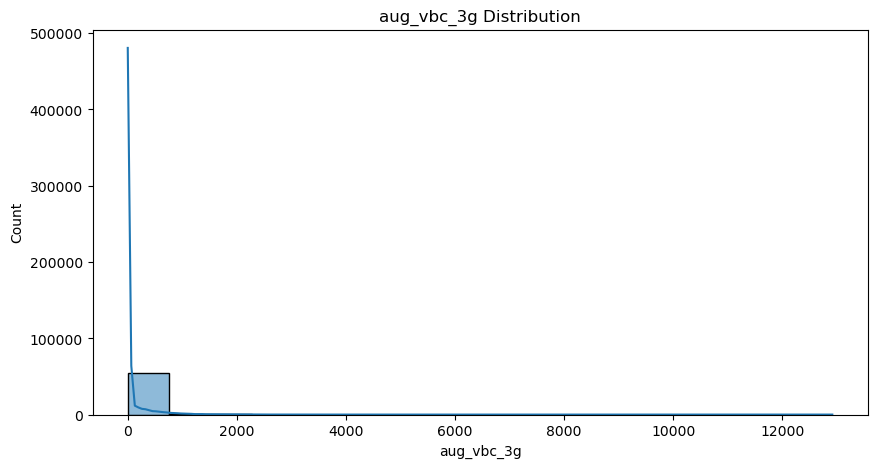

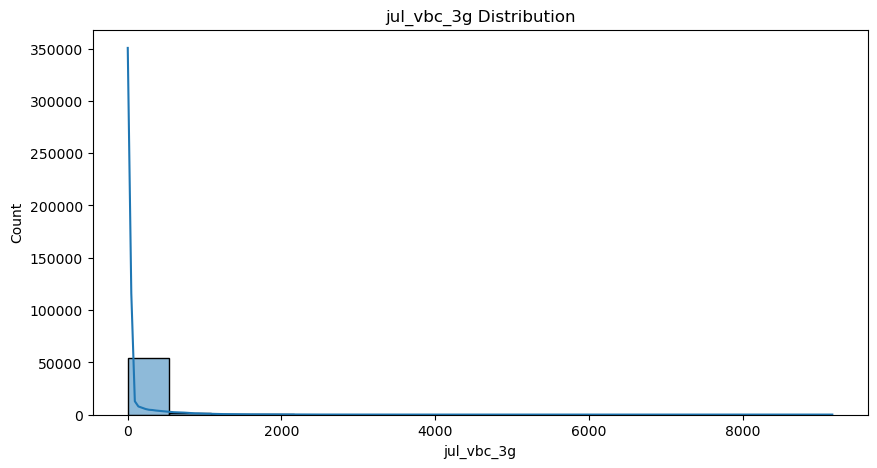

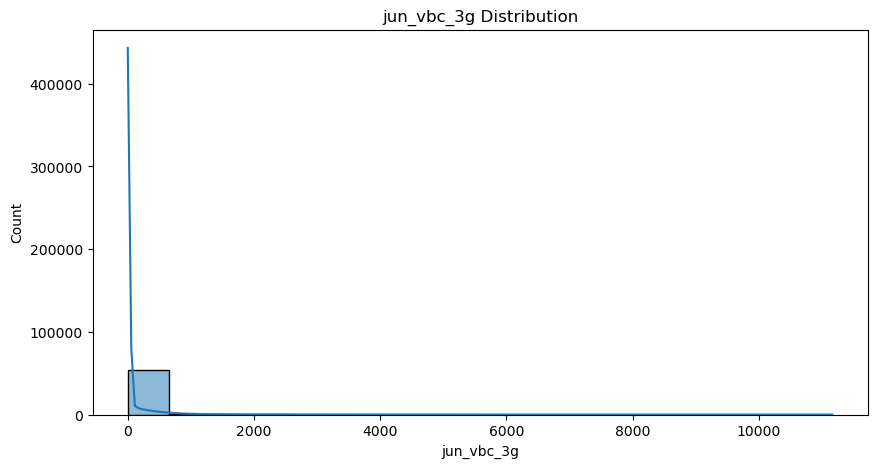

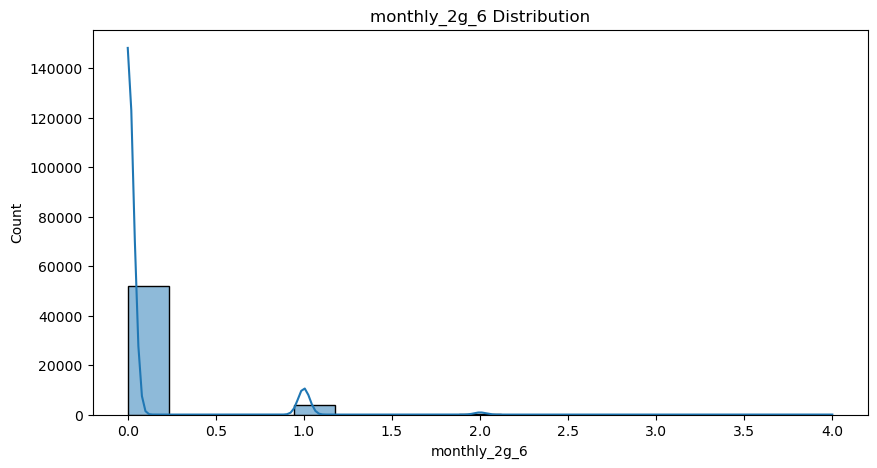

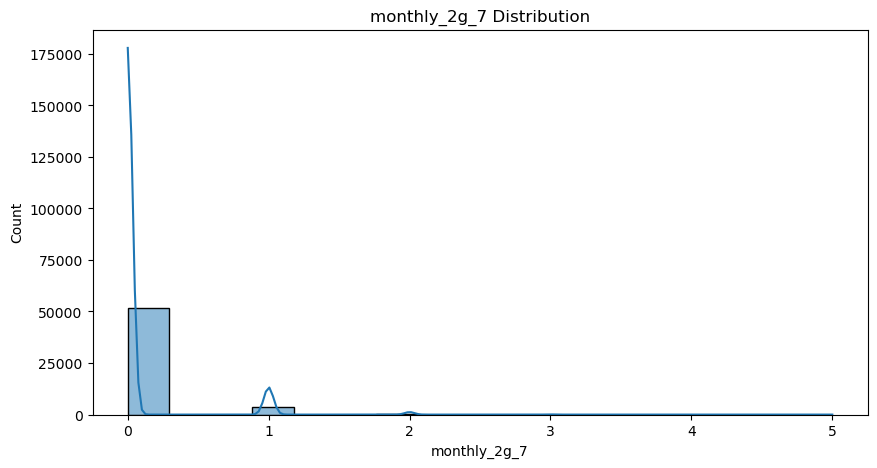

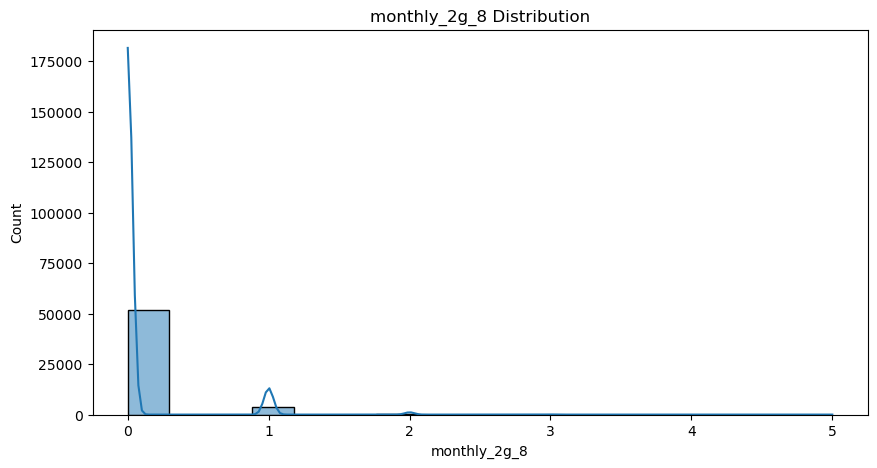

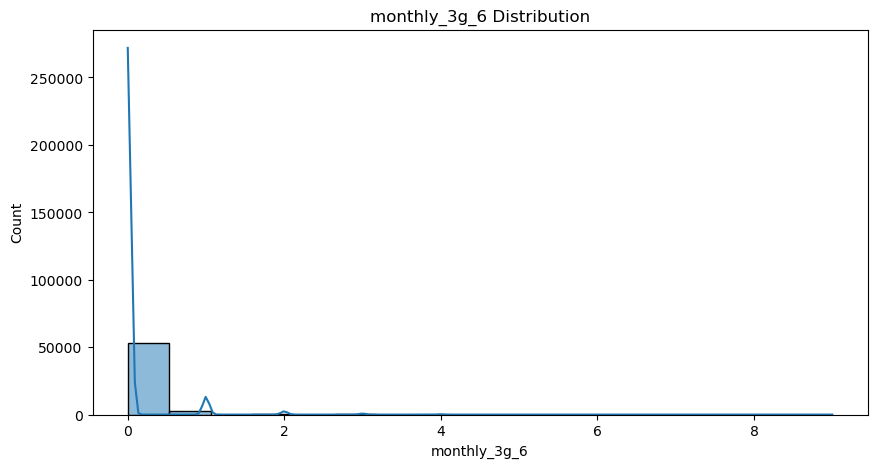

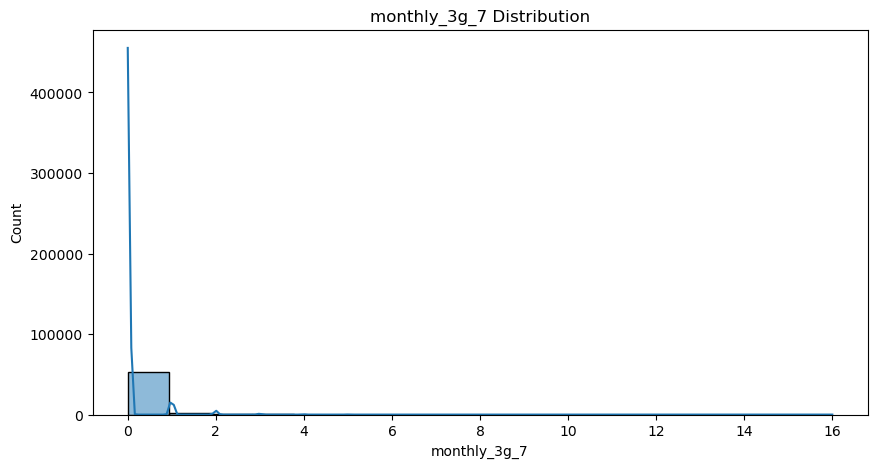

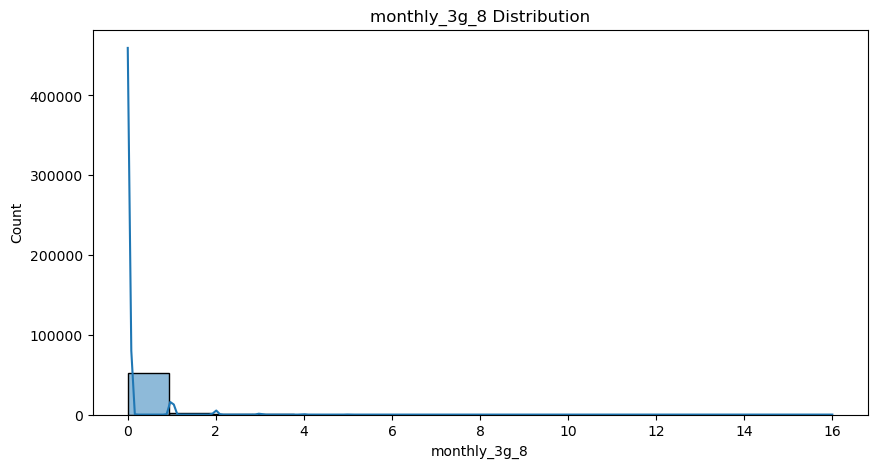

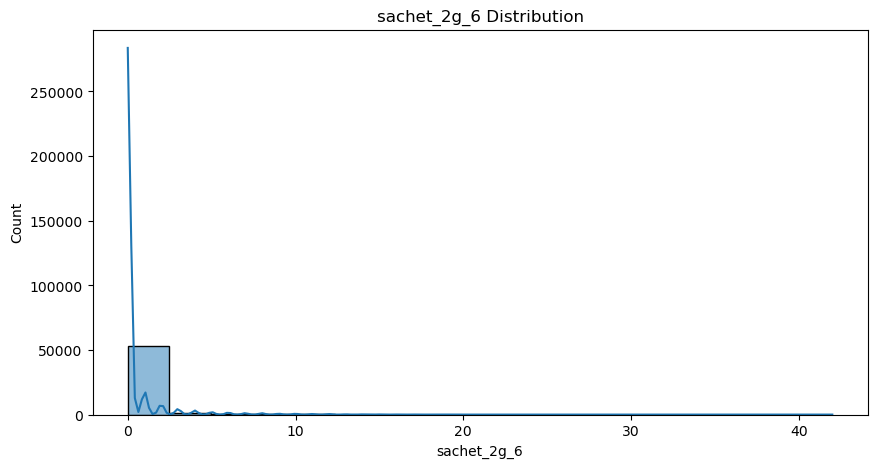

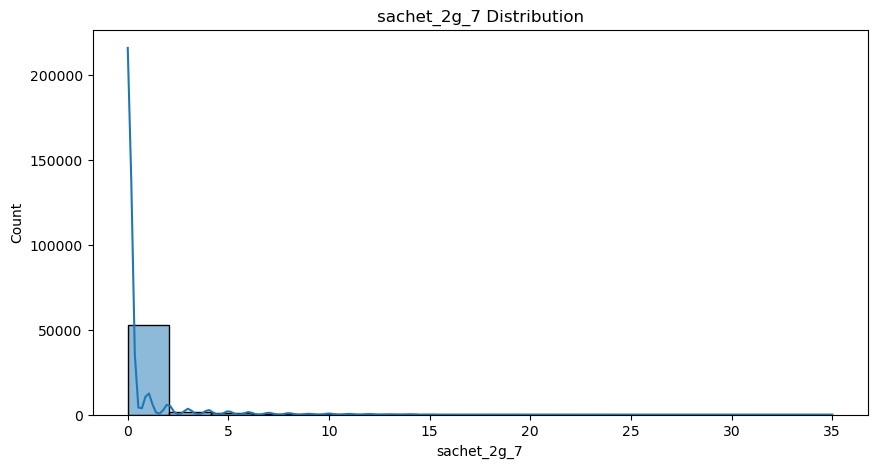

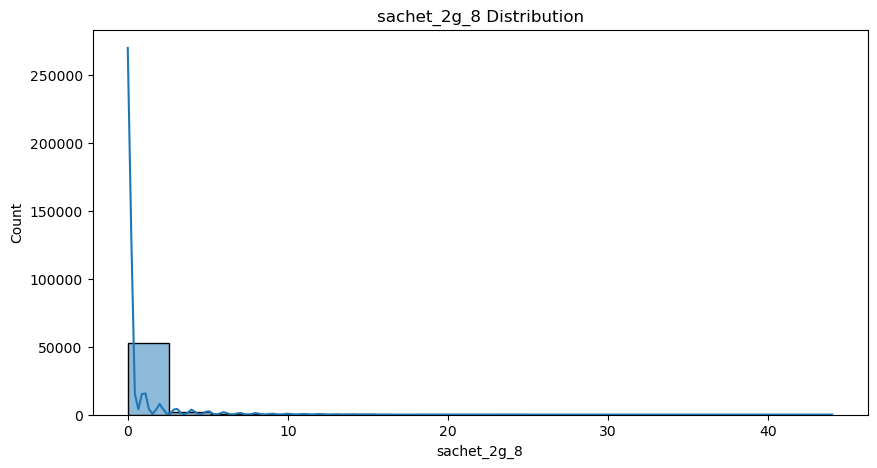

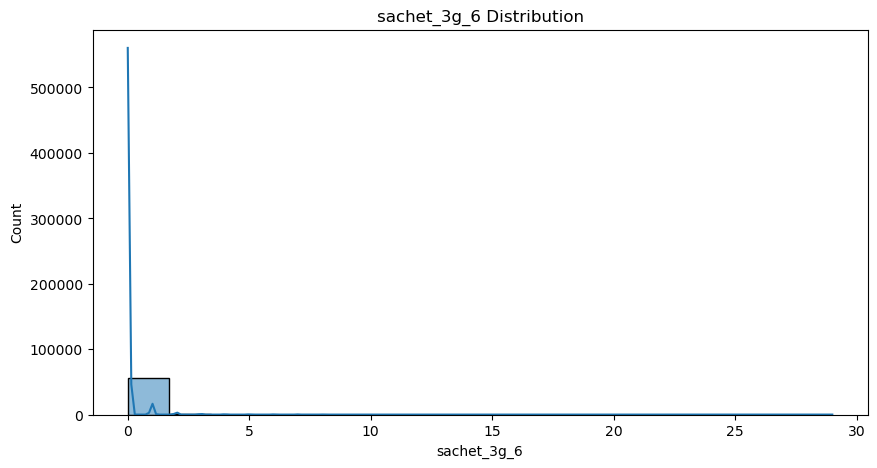

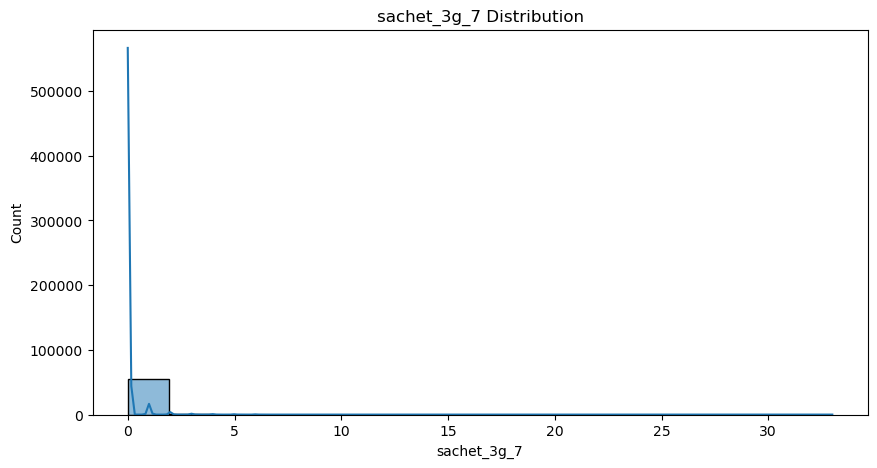

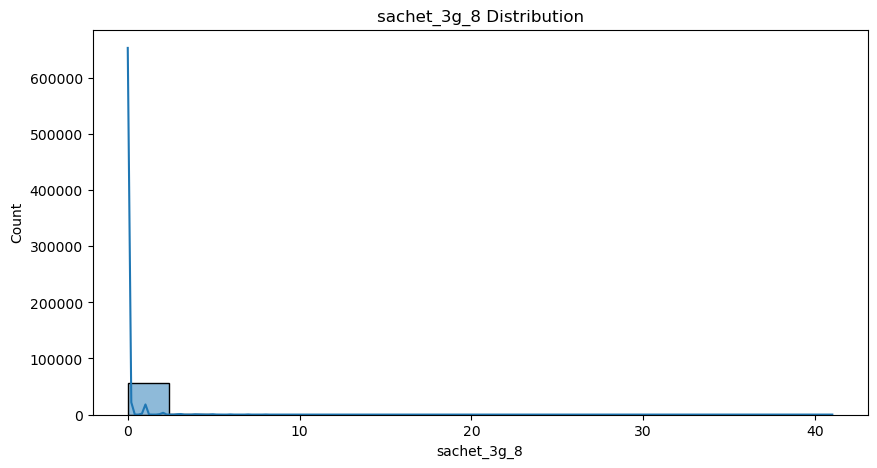

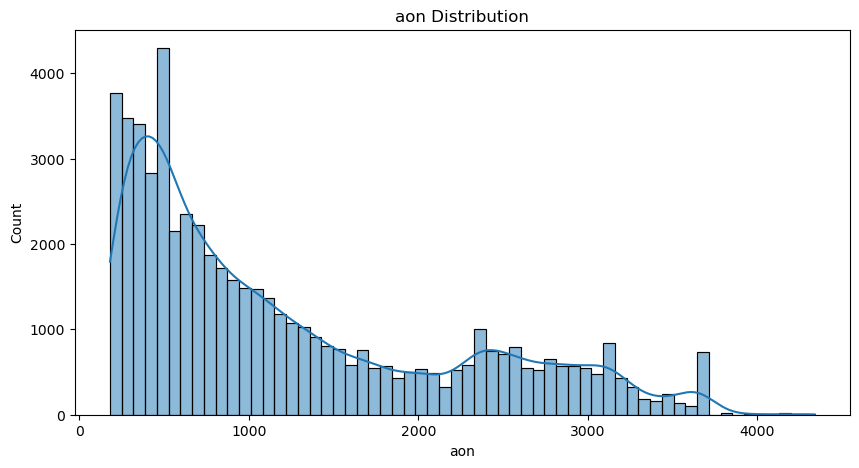

In [57]:
def univariate_analysis(data):
    print("Univariate Analysis: Feature Distributions")
    
    numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        sns.histplot(data[col], kde=True)
        plt.title(f'{col} Distribution')
        plt.show()

univariate_analysis(X_train_filtered)

### BIVARIATE ANALYSIS

Bivariate Analysis: Feature vs Target


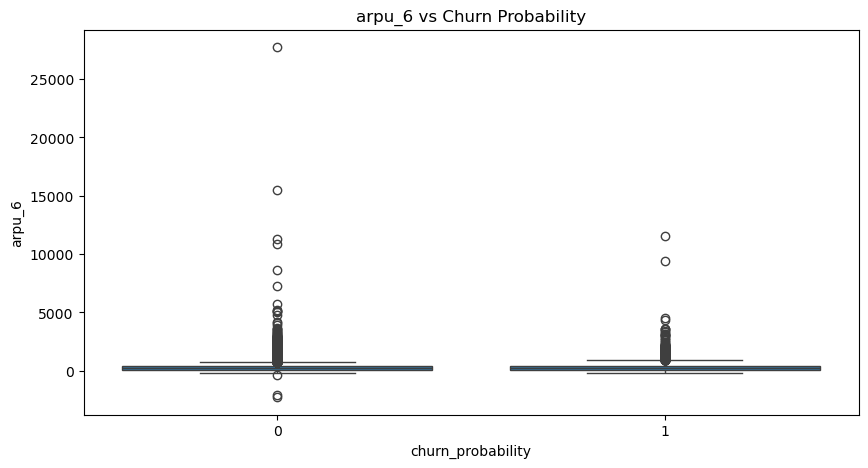

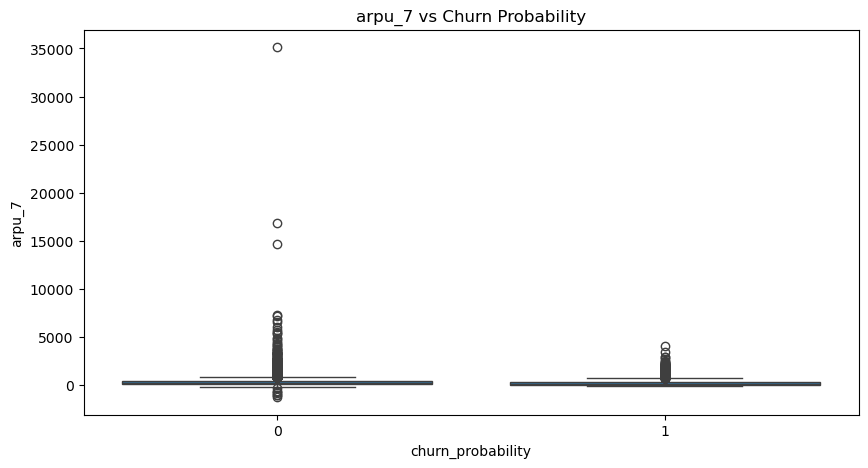

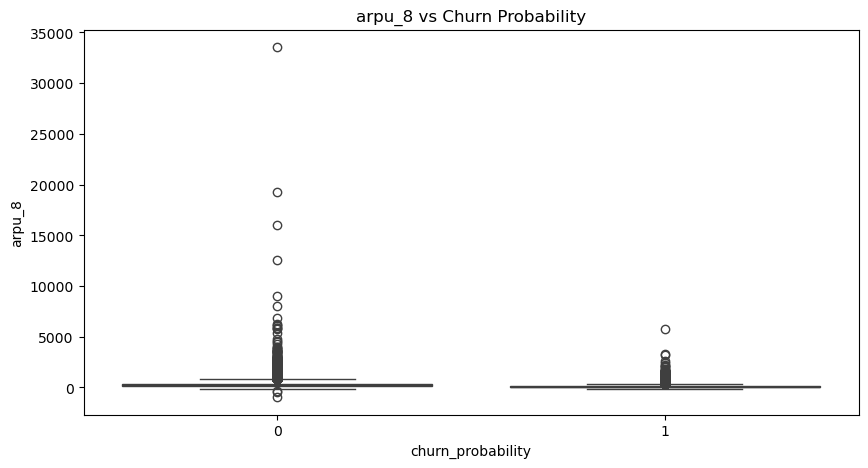

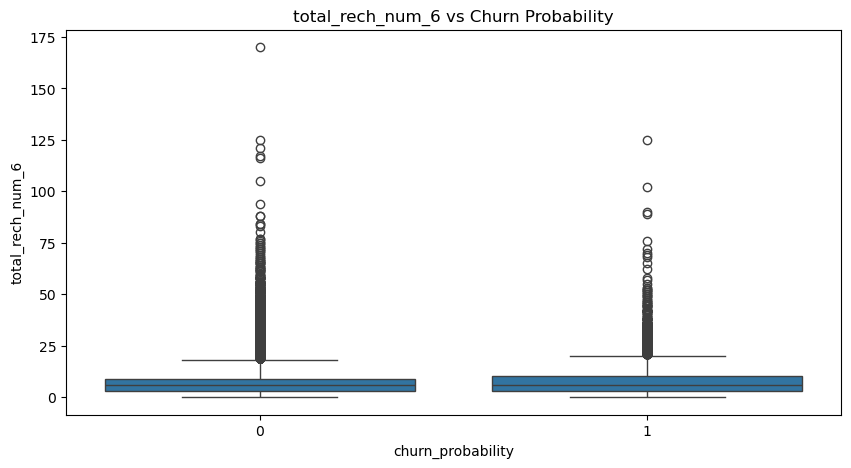

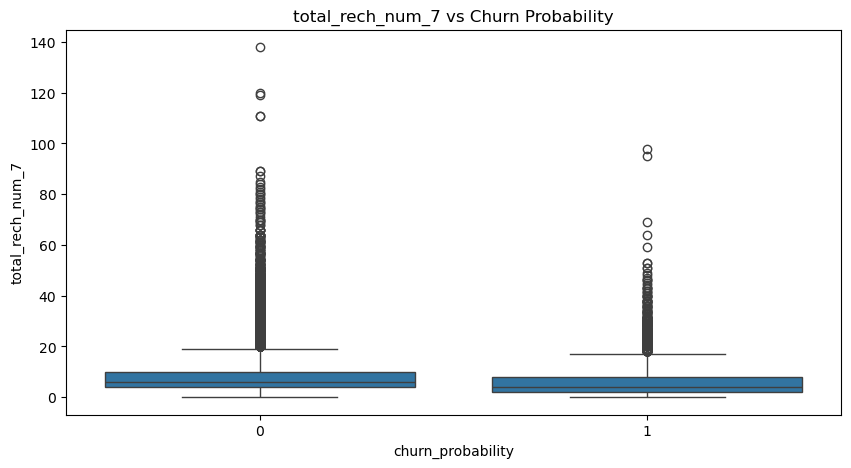

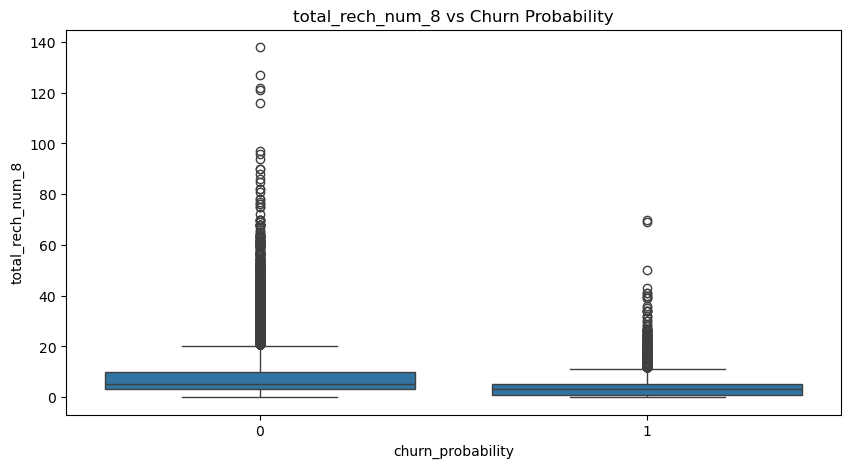

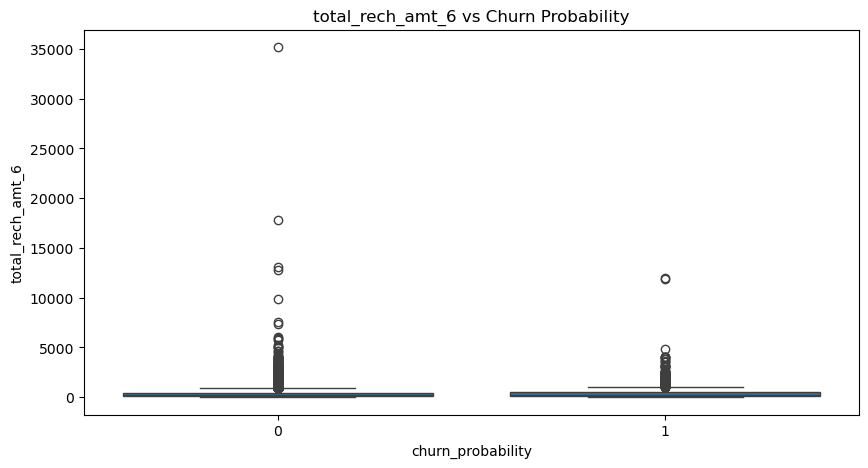

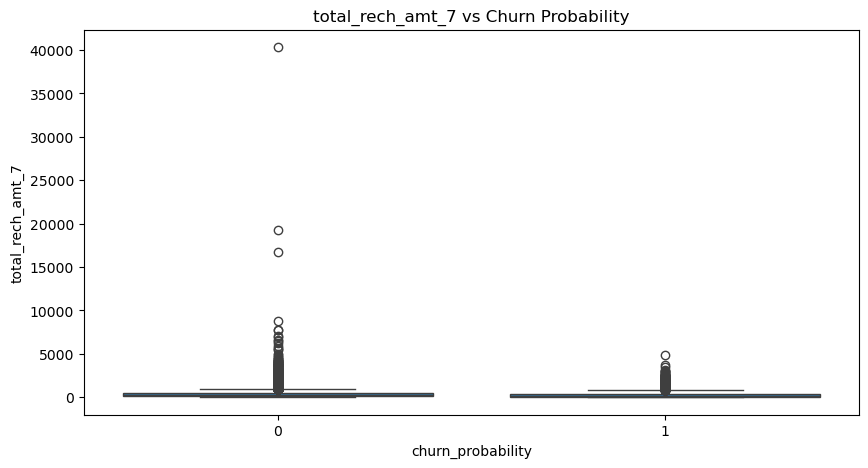

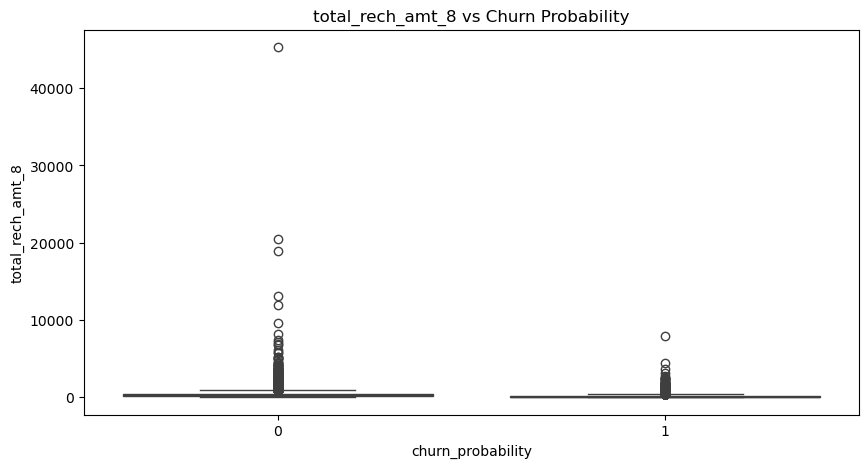

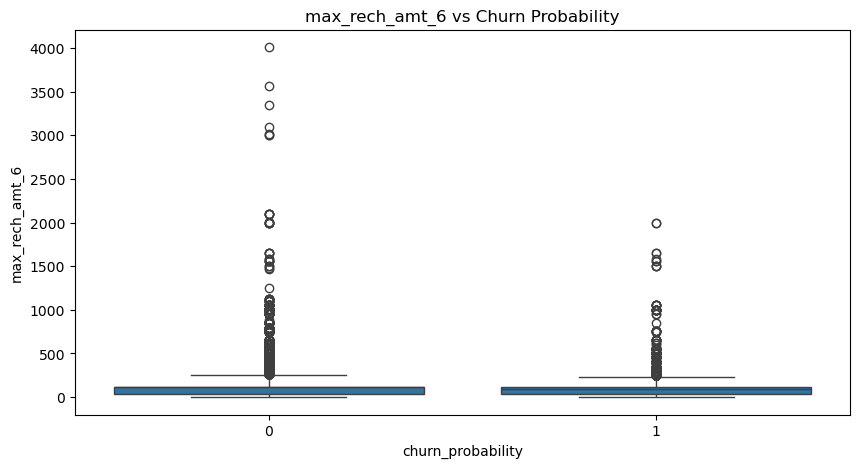

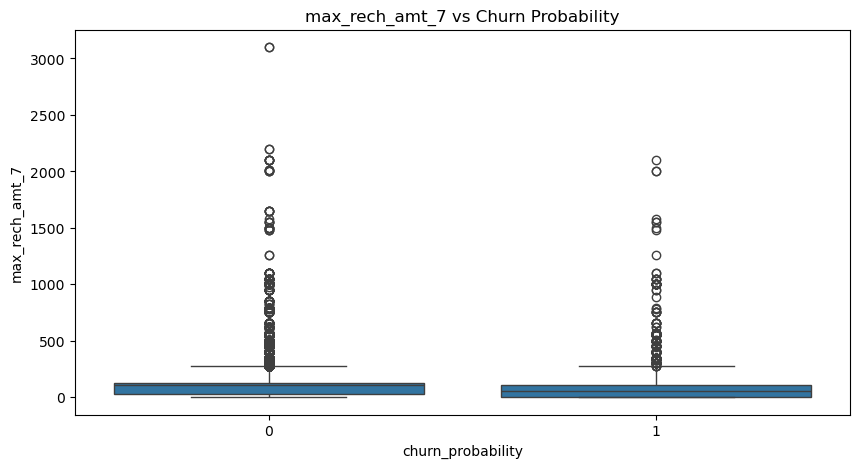

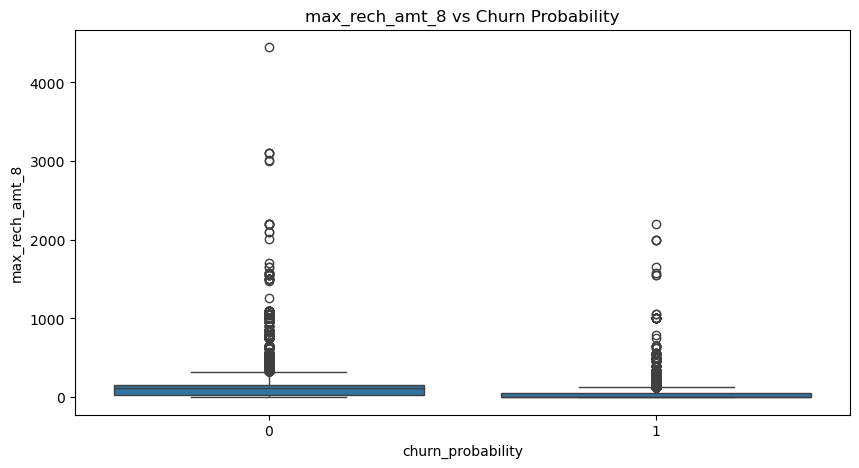

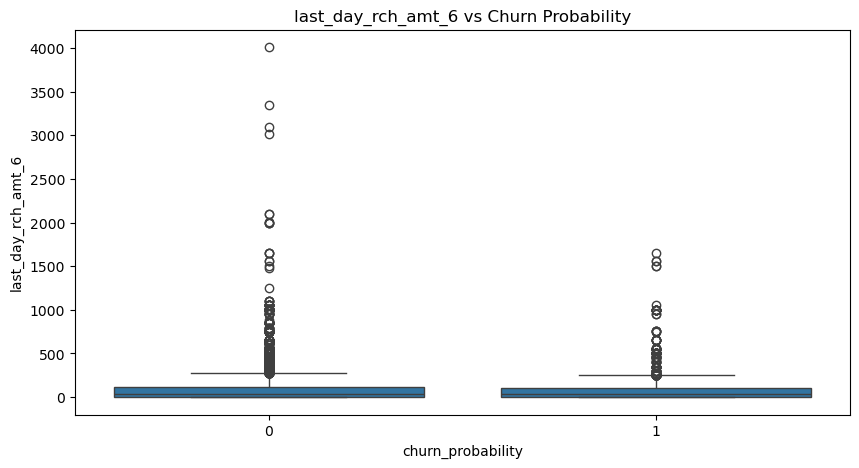

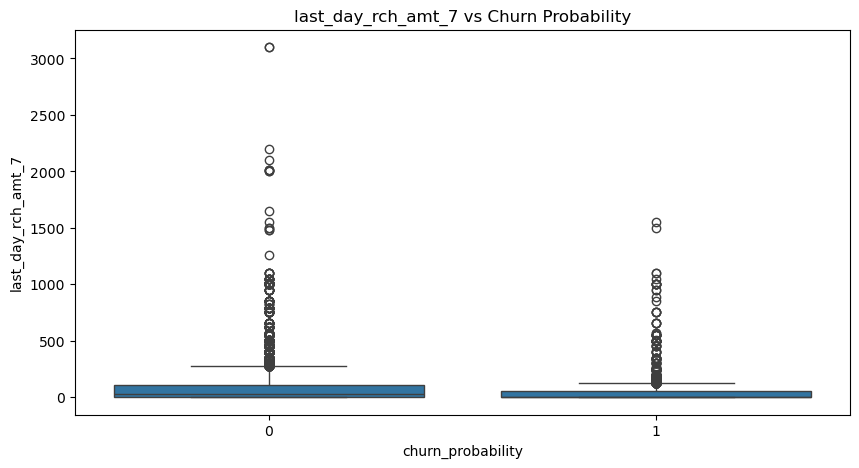

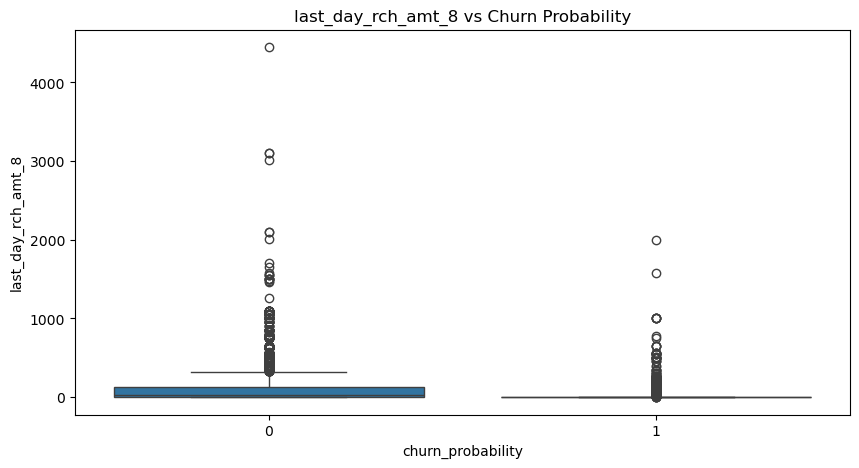

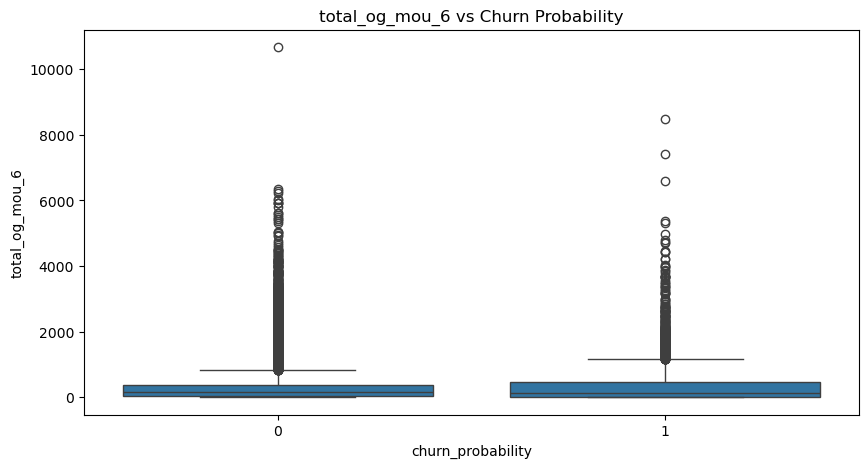

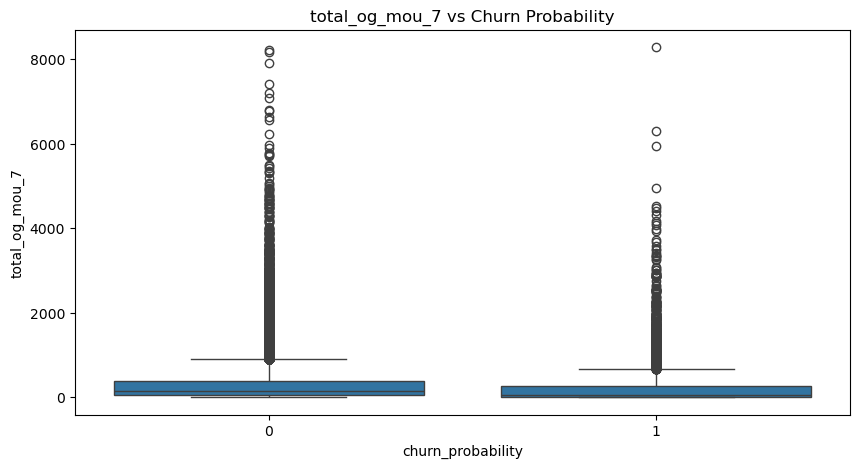

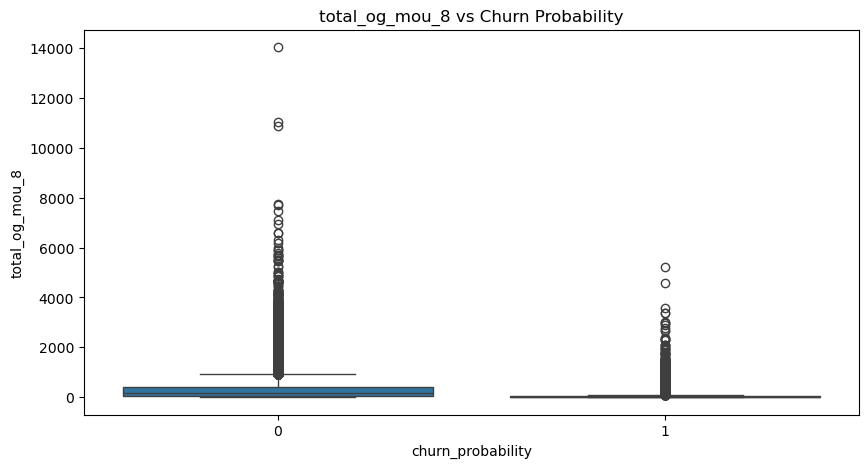

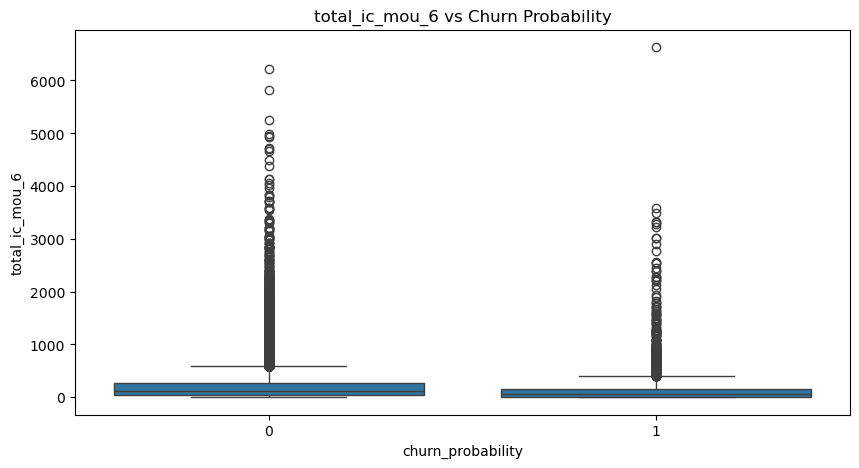

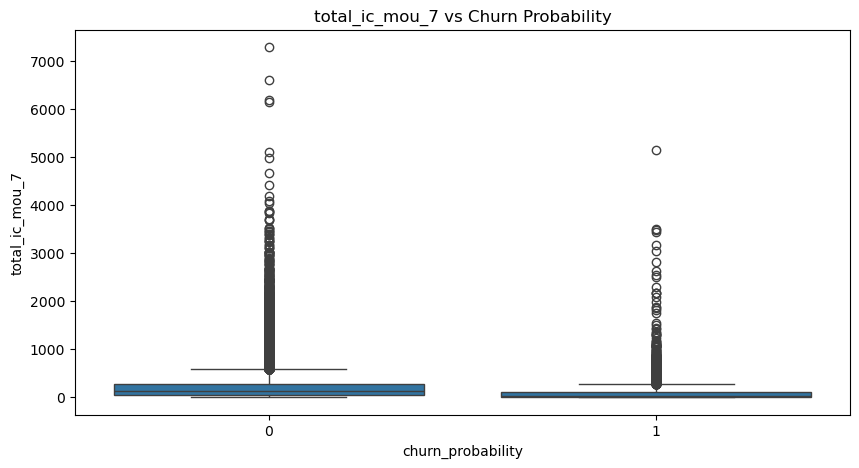

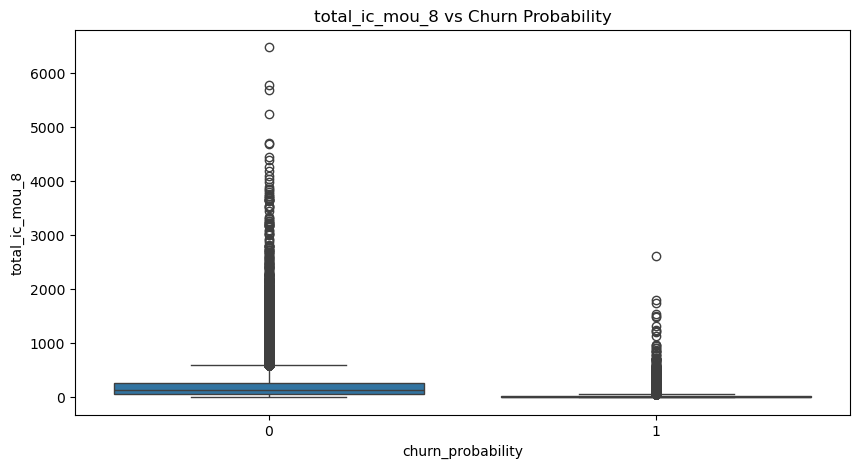

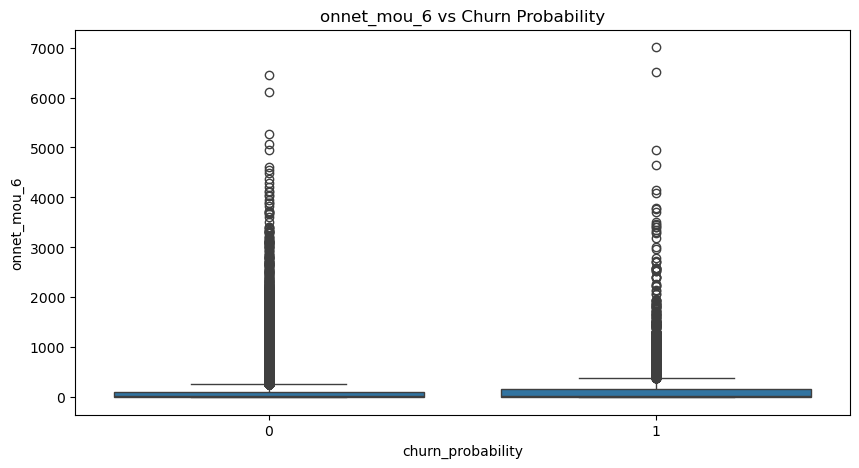

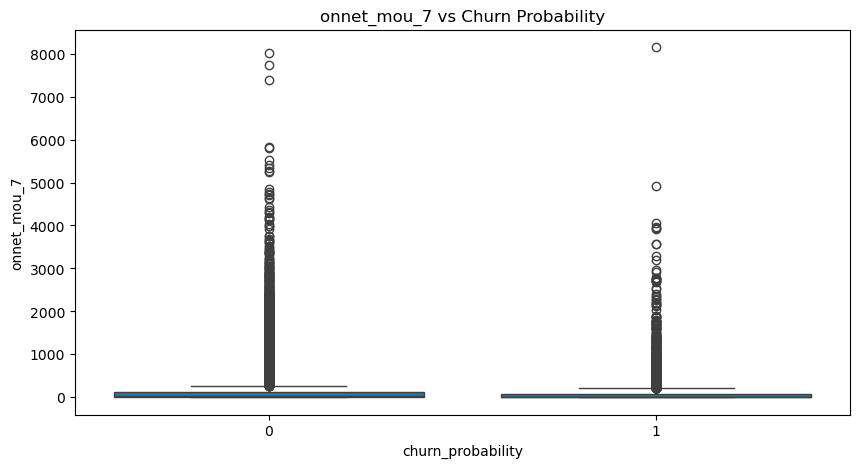

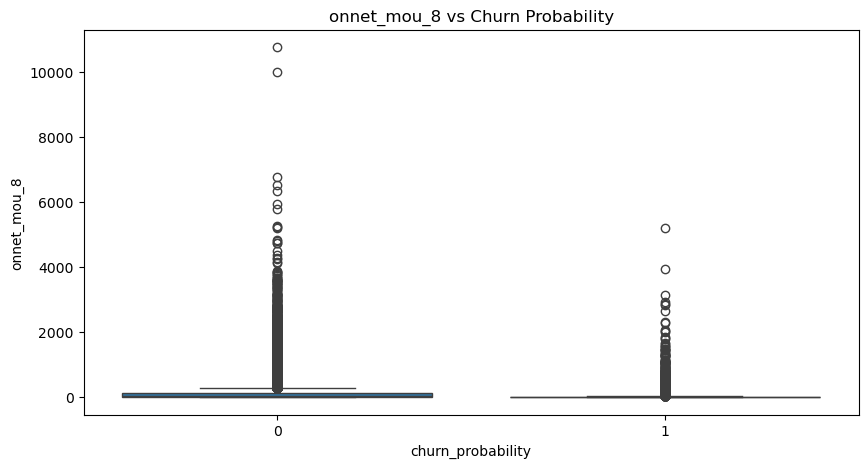

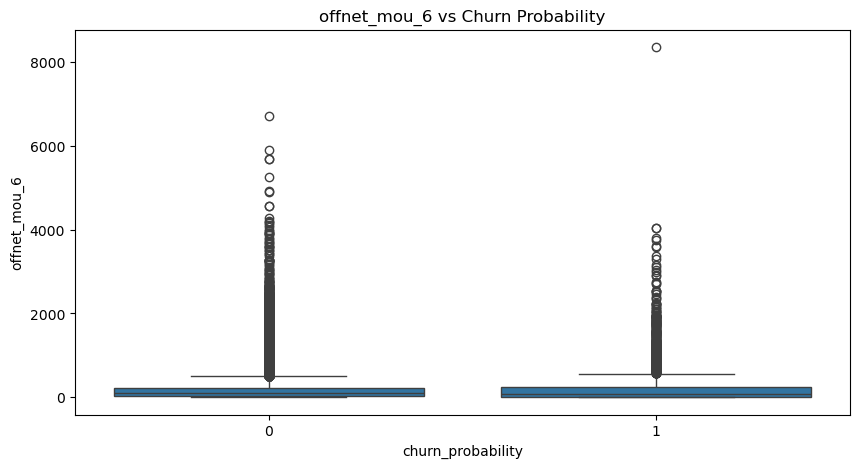

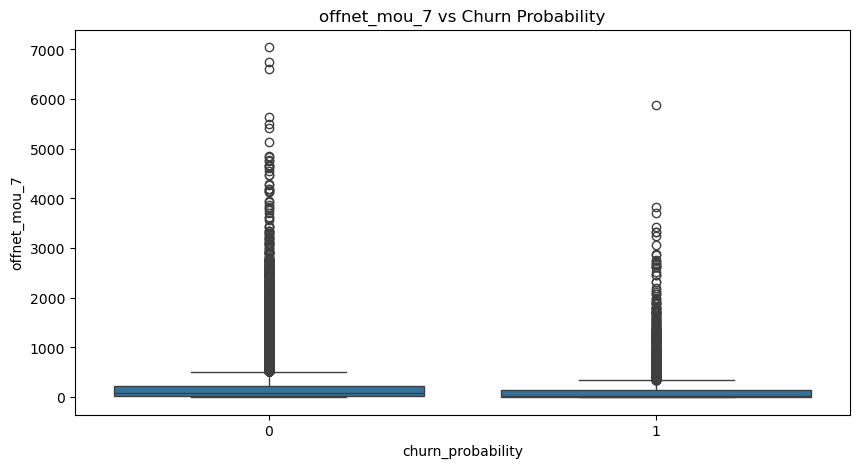

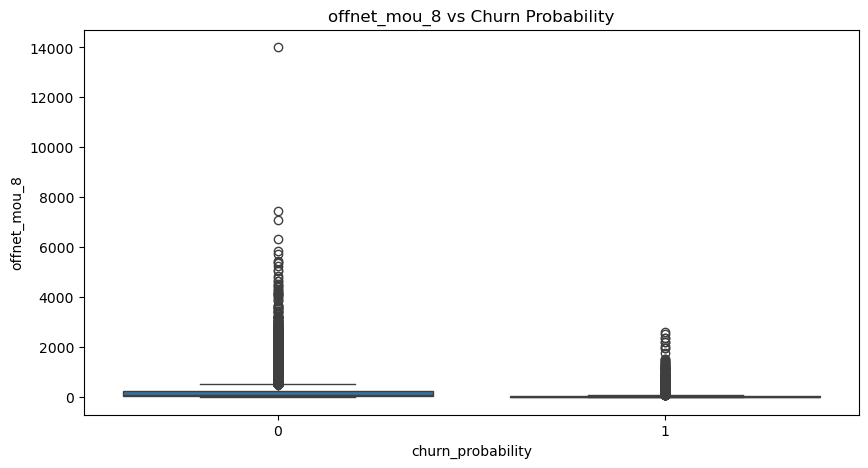

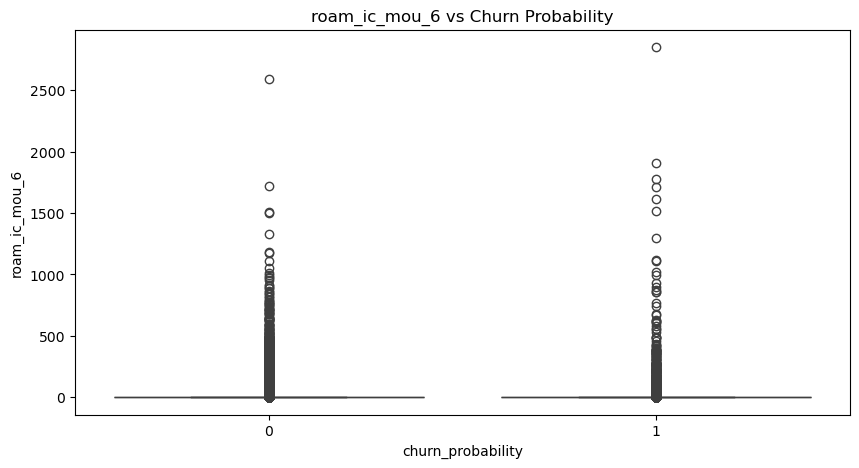

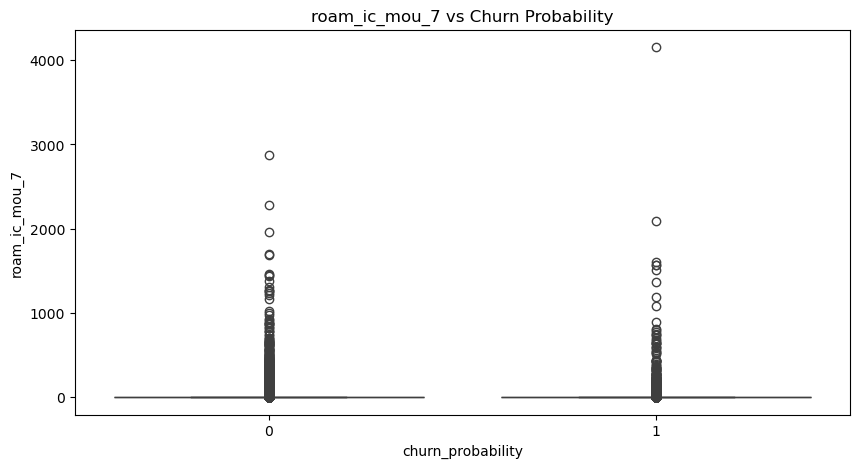

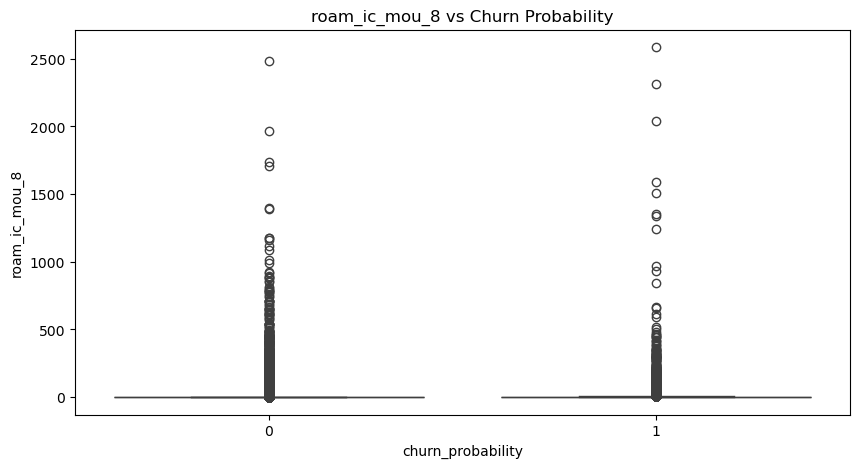

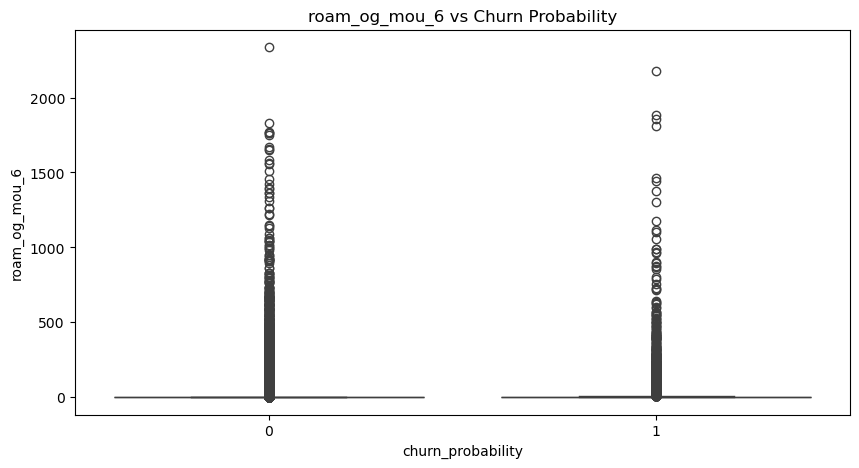

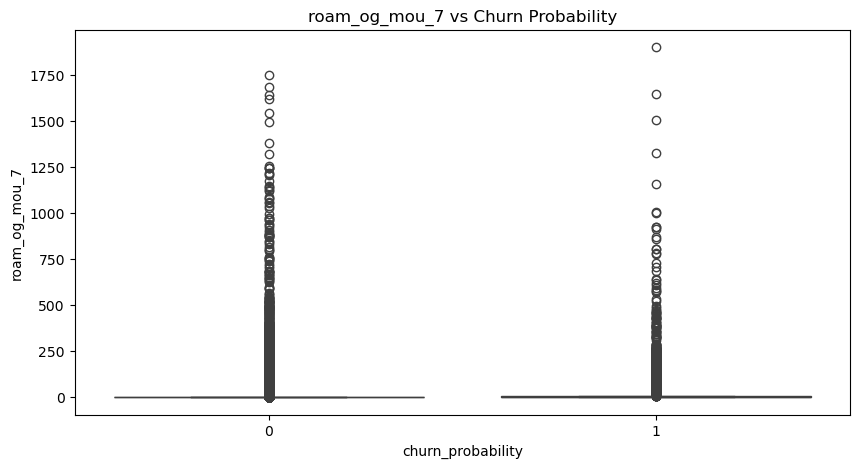

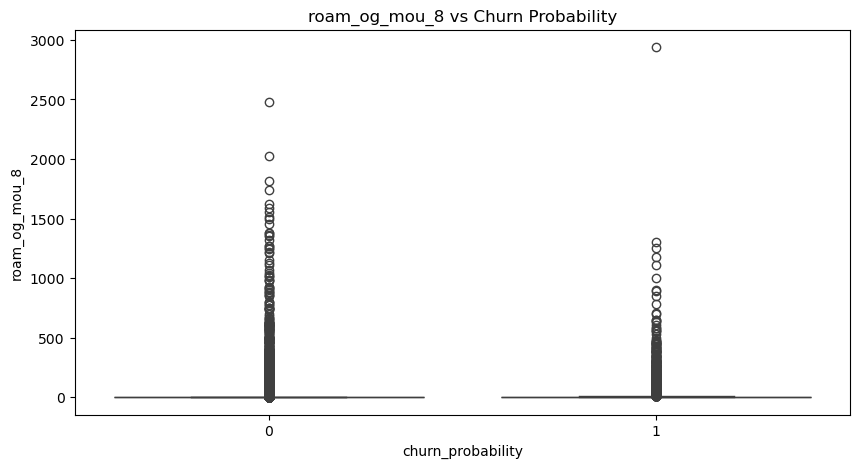

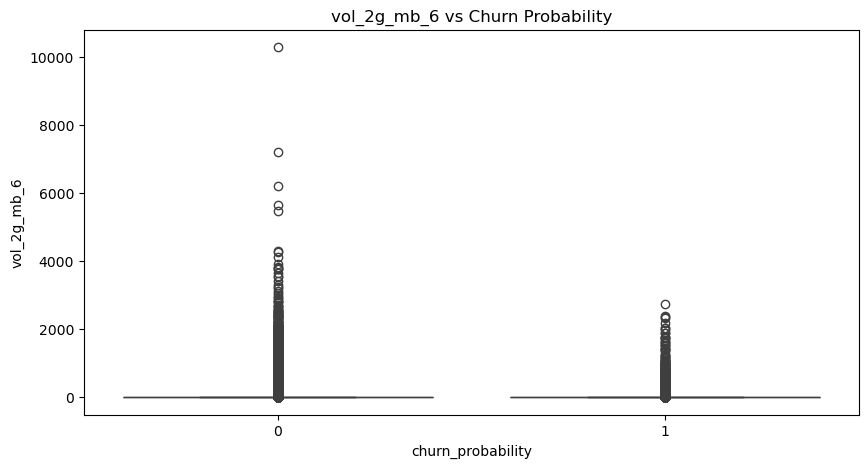

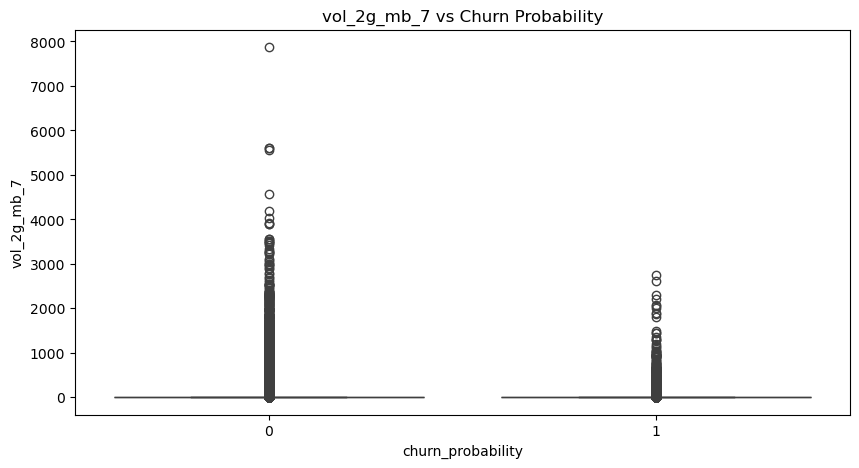

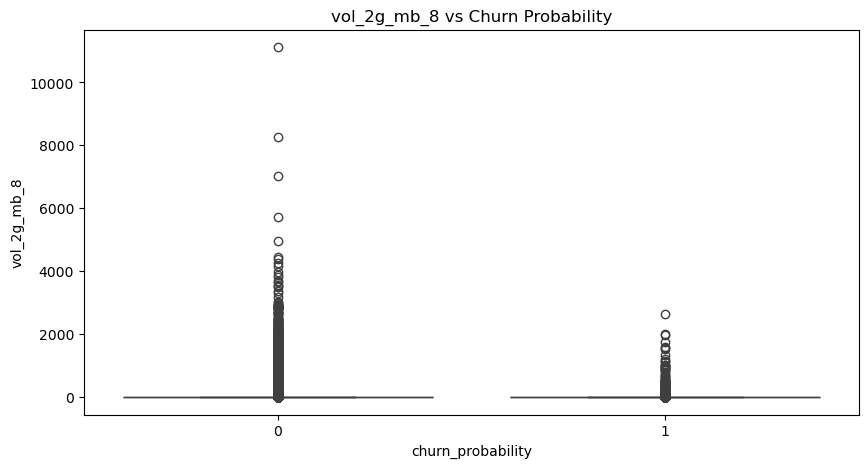

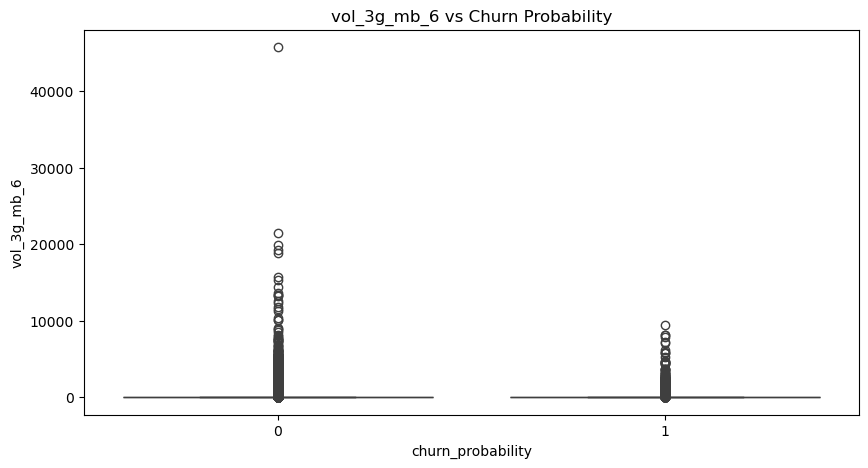

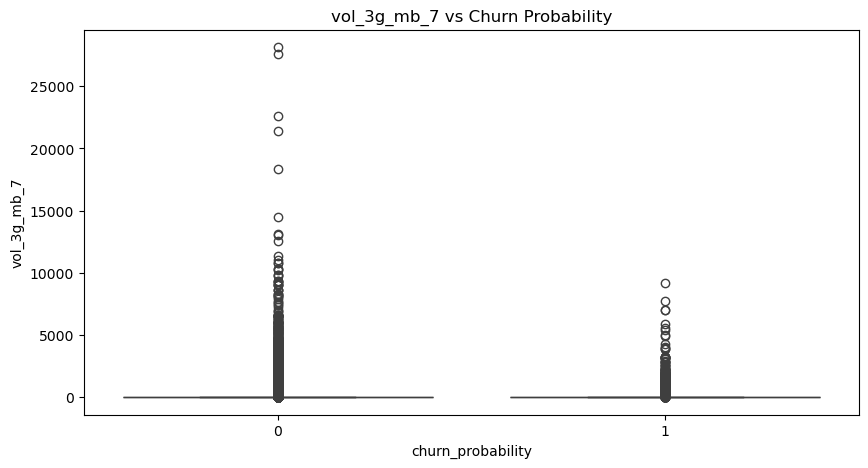

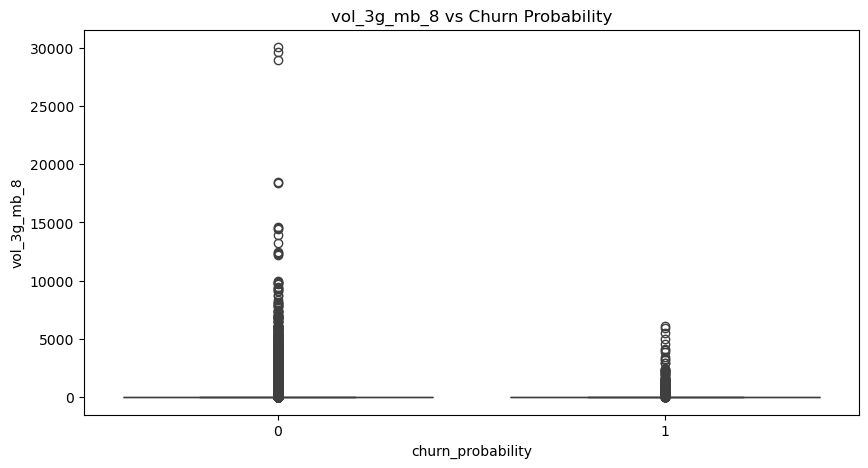

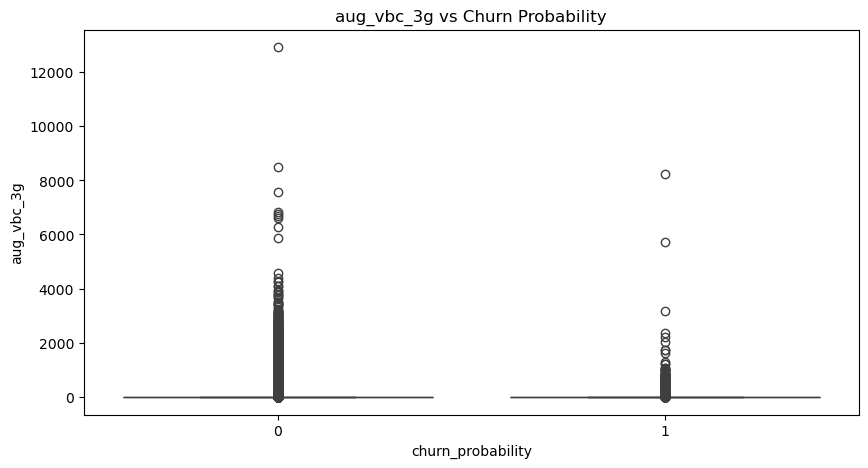

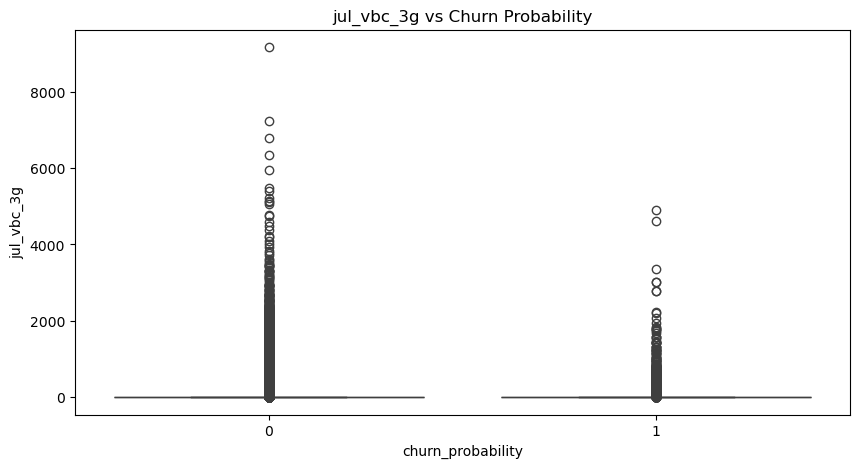

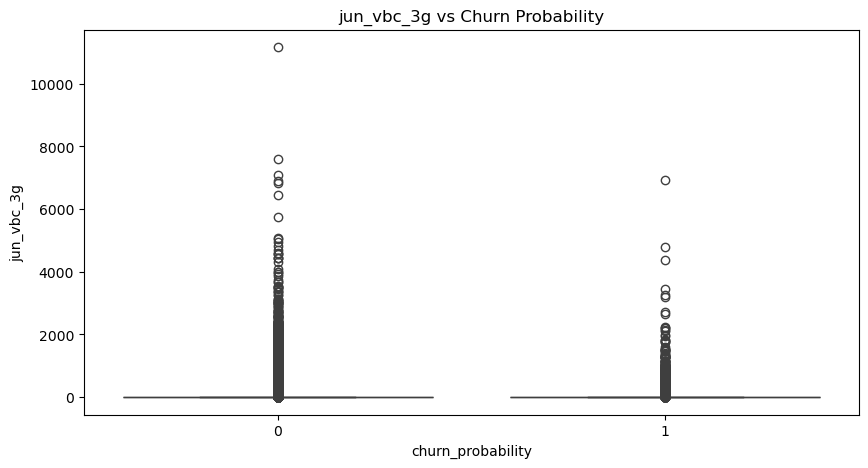

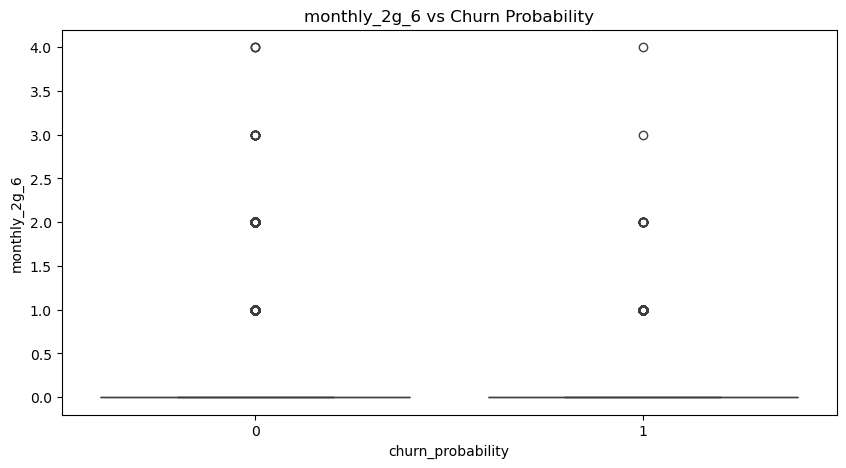

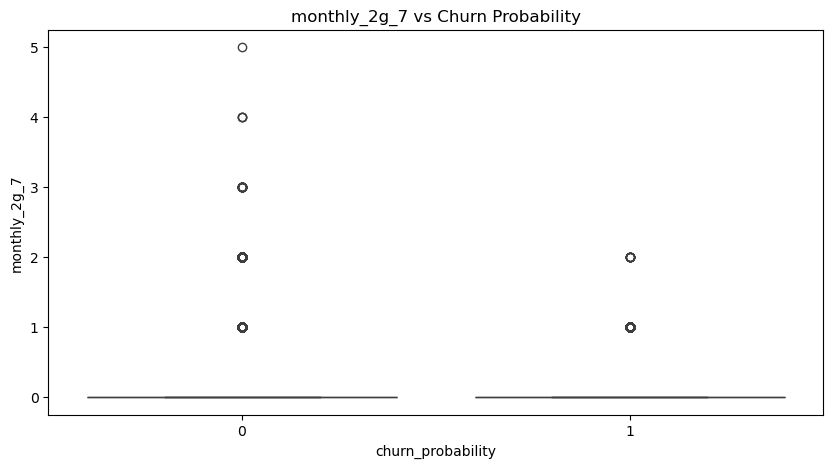

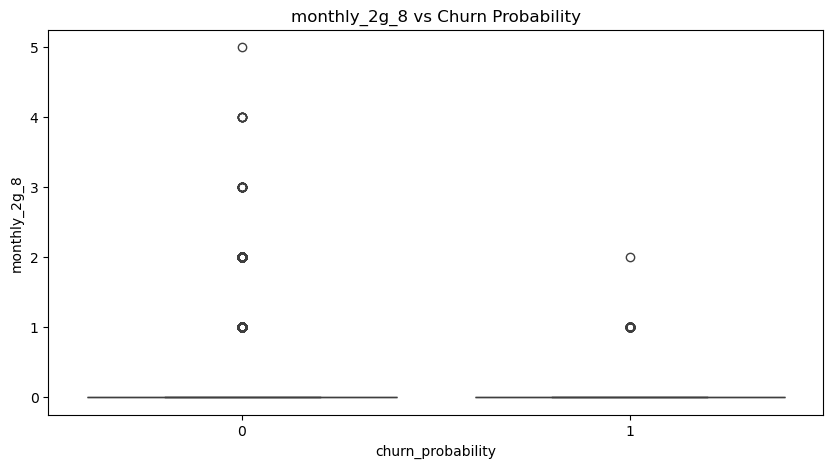

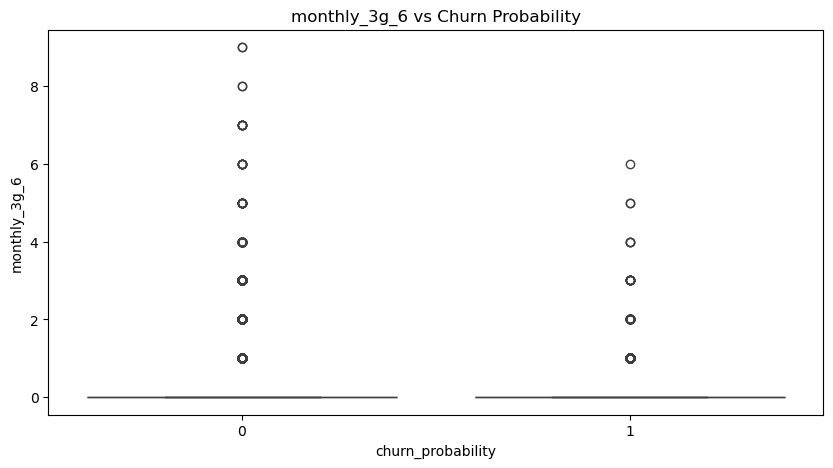

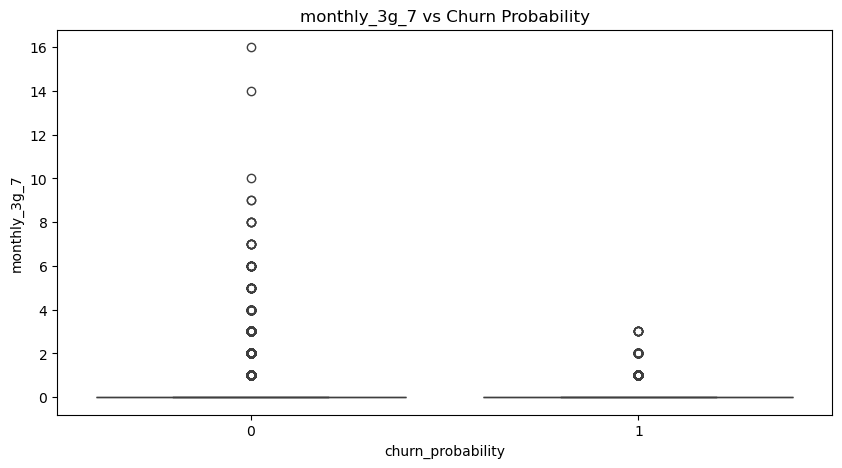

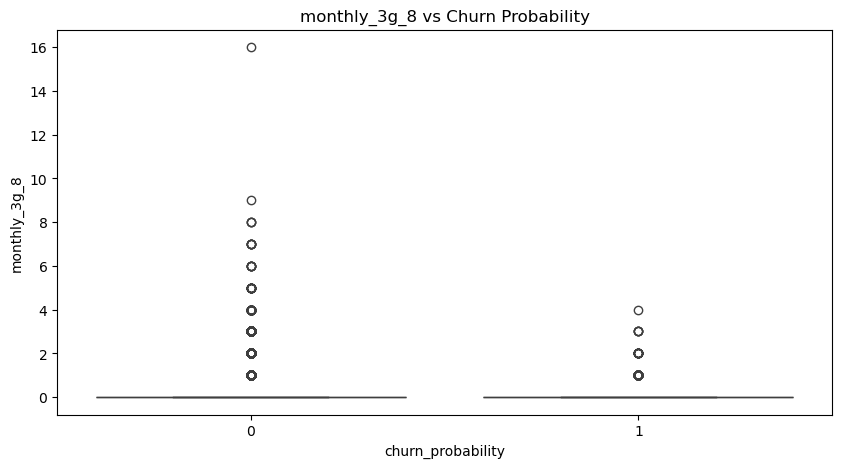

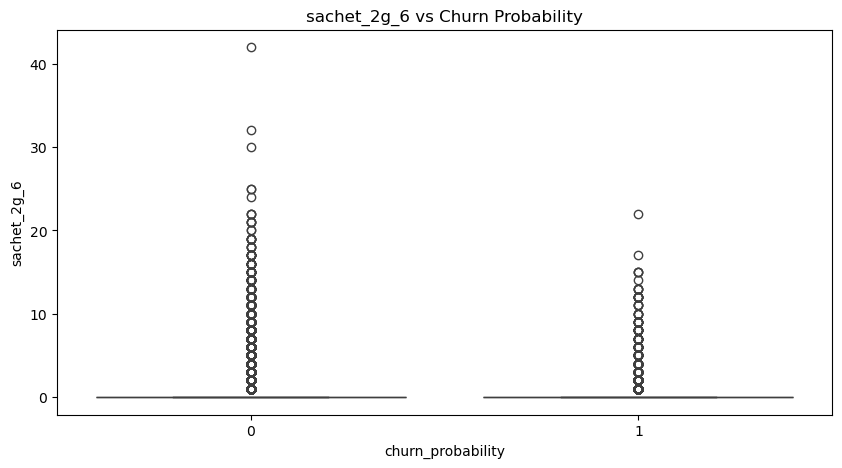

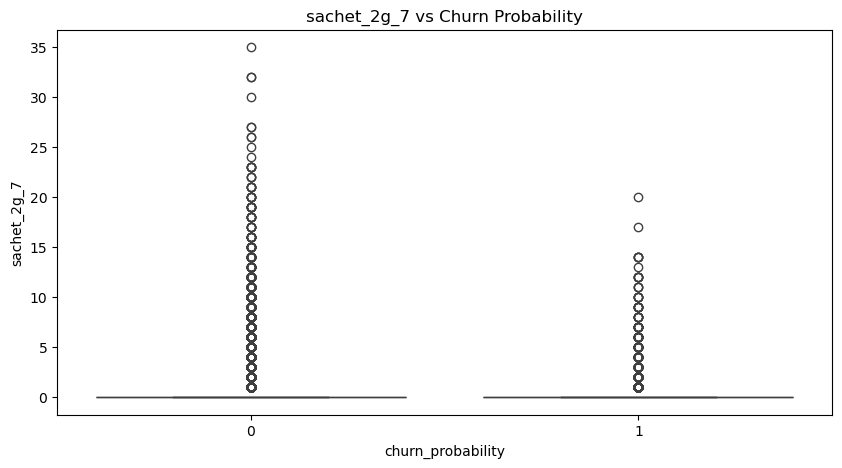

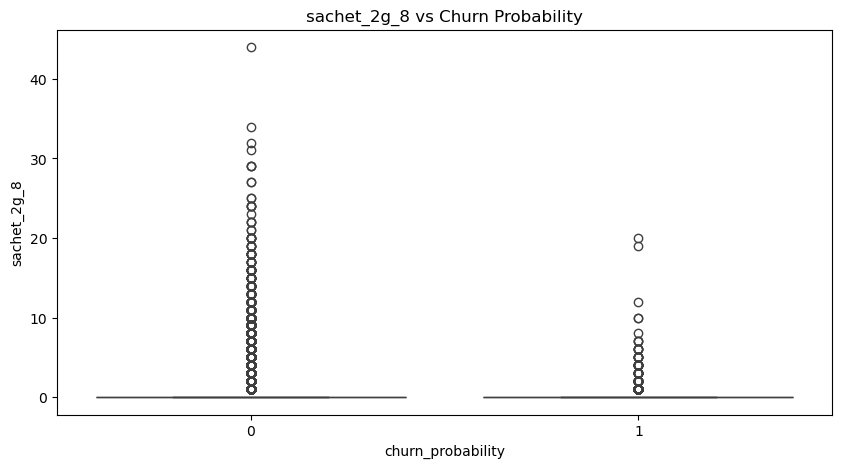

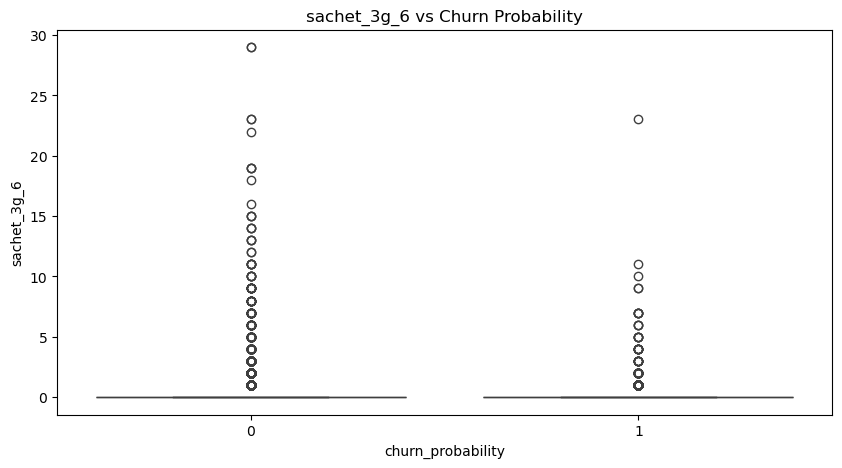

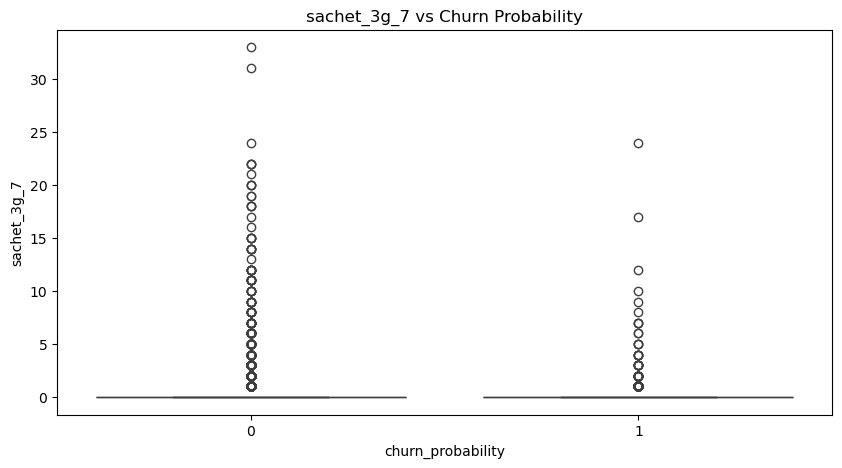

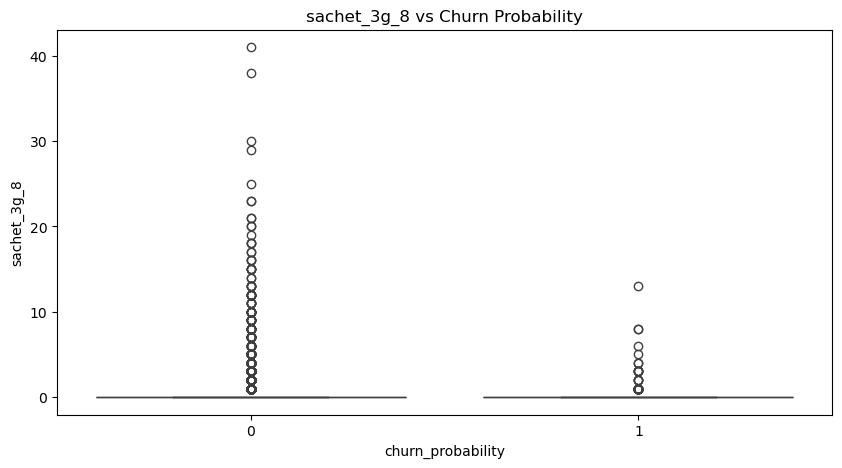

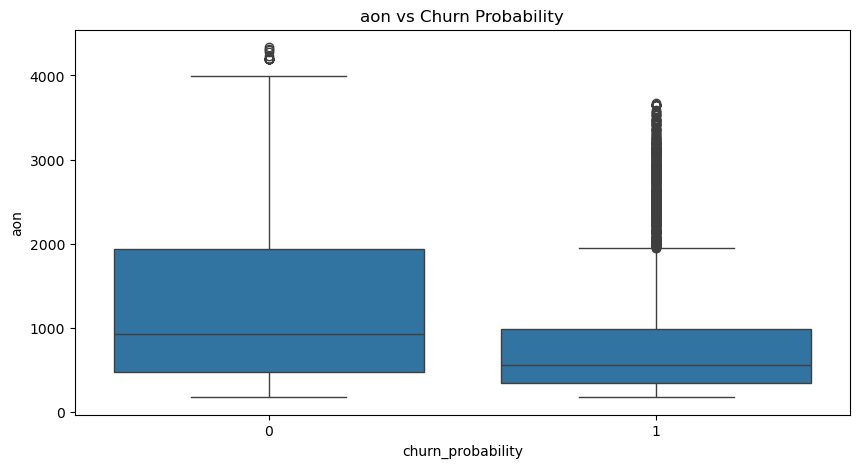

In [59]:
def bivariate_analysis(X_train, y_train):
    print("Bivariate Analysis: Feature vs Target")
    
    numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=y_train, y=X_train[col])
        plt.title(f'{col} vs Churn Probability')
        plt.show()

    
bivariate_analysis(X_train_filtered, y_train)

### MULTIVARIATE ANALYSIS (CORRELATION & PAIRPLOTS)

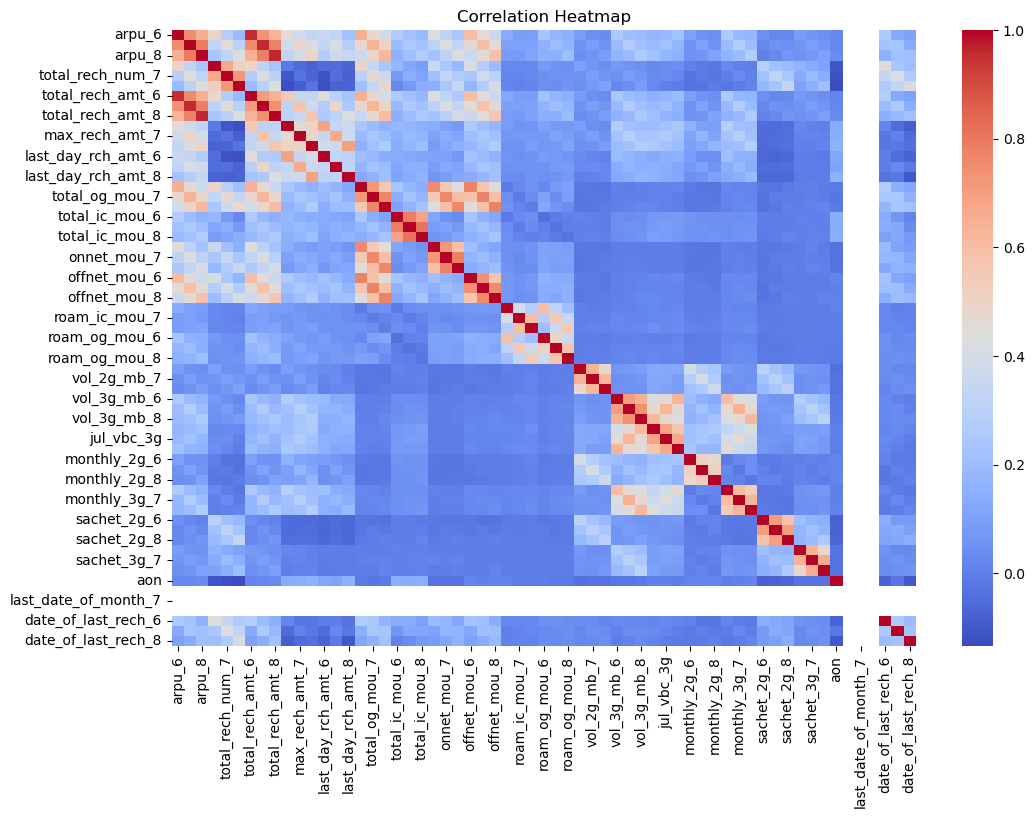

,arpu_6,arpu_7,arpu_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8
arpu_6,1.000000,0.748832,0.652063,0.494941,0.282127,0.193344,0.954153,0.734451,0.636683,0.454123,...,0.084039,0.066443,0.048580,0.024862,NaN,NaN,NaN,0.258979,0.127664,0.102020
arpu_7,0.748832,1.000000,0.788291,0.327780,0.441116,0.299877,0.757537,0.955685,0.776264,0.377784,...,0.062645,0.092696,0.063750,0.024642,NaN,NaN,NaN,0.226468,0.232282,0.133614
arpu_8,0.652063,0.788291,1.000000,0.240984,0.319815,0.436632,0.647919,0.785248,0.960607,0.324616,...,0.052443,0.070001,0.099682,0.033871,NaN,NaN,NaN,0.157453,0.211346,0.206602
total_rech_num_6,0.494941,0.327780,0.240984,1.000000,0.671429,0.517034,0.490913,0.313793,0.229947,-0.010765,...,0.162356,0.134399,0.105640,-0.109641,NaN,NaN,NaN,0.434732,0.243375,0.209248
total_rech_num_7,0.282127,0.441116,0.319815,0.671429,1.000000,0.721780,0.271107,0.444723,0.300868,-0.106049,...,0.135259,0.194155,0.142917,-0.124904,NaN,NaN,NaN,0.340094,0.418820,0.268526


In [61]:
def multivariate_analysis(df):
    # Drop non-numeric columns
    numeric_df = df.select_dtypes(include=['number'])
    
    # Compute correlation matrix
    correlation_matrix = numeric_df.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
    plt.title('Correlation Heatmap')
    plt.show()
    
    return correlation_matrix

correlation_matrix = multivariate_analysis(X_train_filtered)
correlation_matrix.head()

**Observations from the Correlation Heatmap:**

* **High Positive Correlations:**
    * Consecutive months' ARPU (`arpu_6`, `arpu_7`, `arpu_8`), total recharge amounts (`total_rech_amt`), recharge numbers (`total_rech_num`), maximum recharge amounts (`max_rech_amt`), outgoing minutes (`total_og_mou`), incoming minutes (`total_ic_mou`), 2G data usage (`vol_2g_mb`), 3G data usage (`vol_3g_mb`), monthly 2G/3G recharges (`monthly_2g`, `monthly_3g`), and 2G/3G sachet recharges (`sachet_2g`, `sachet_3g`) are all highly positively correlated. This suggests consistent user behavior across consecutive months.

* **High Negative Correlations:**
    * Total recharge amounts (`total_rech_amt`) show negative correlations with 2G data usage (`vol_2g_mb`), monthly 2G recharges (`monthly_2g`), and 2G sachet recharges (`sachet_2g`). This might indicate users who recharge more tend to use less 2G data, possibly due to preference for 3G or other services.

* **Moderate Correlations:**
    * Age on Network (`aon`) shows moderate positive correlations with ARPU (`arpu`) and total recharge amounts (`total_rech_amt`), suggesting that longer tenure might be associated with higher spending.
    * Last day recharge amounts (`last_day_rch_amt`) are positively correlated with total recharge amounts (`total_rech_amt`).

* **Low Correlations:**
    * Many other variable pairs exhibit low or negligible correlations, indicating relative independence.

**Implications:**

* The strong positive correlations suggest that past behavior is a good predictor of future behavior for many metrics.
* The negative correlations highlight potential shifts in user preferences or usage patterns based on recharge amounts.
* The moderate correlations with `aon` suggest that customer tenure might play a role in spending behavior.
* The low correlations indicate that certain variables are not strongly related, which can be useful for feature selection and model building.

### Visualizing Feature Distributions with Boxplots
- This visualization helps detect potential outliers and understand feature ranges, guiding decisions for outlier treatment or scaling.

<Axes: >

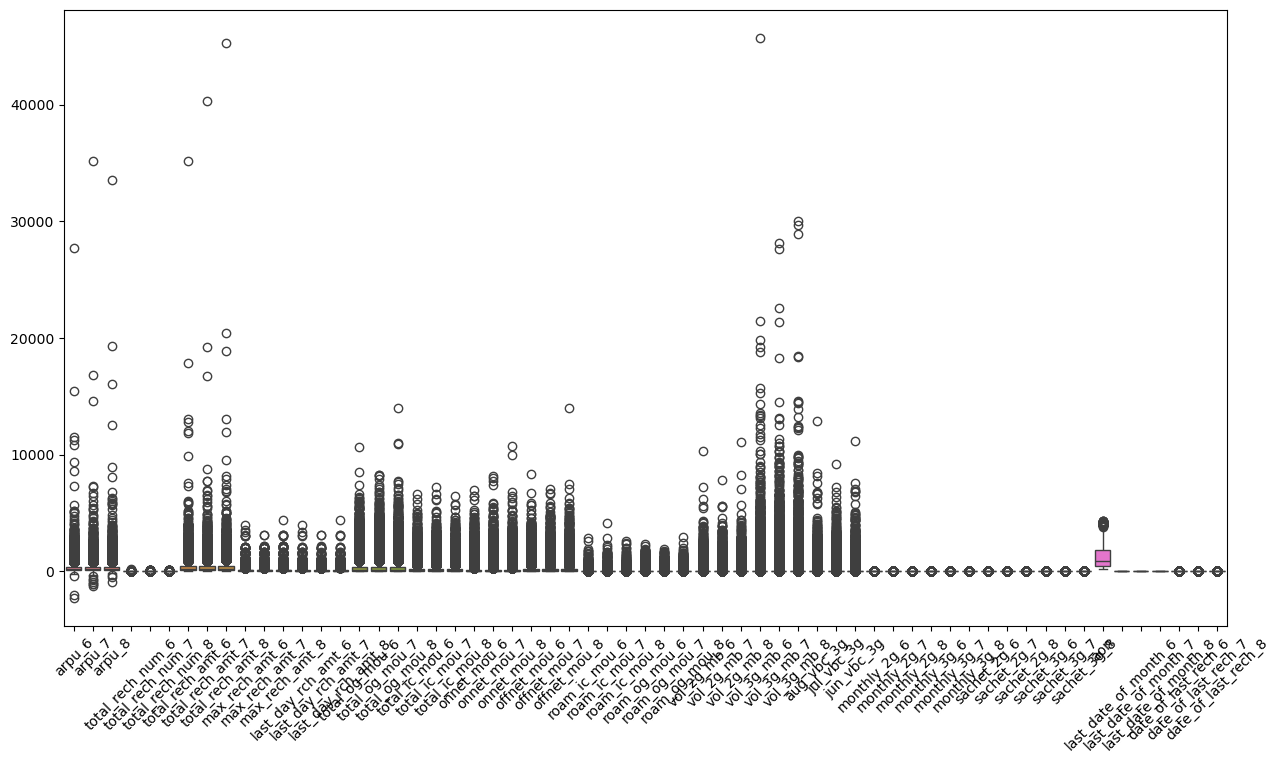

In [64]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered)

## 4.1 Handling outliers

The box plots of these features show there a lot of outliers. These can be capped with k-sigma method.

In [66]:
X_train_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55999 entries, 303 to 55934
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   arpu_6                55999 non-null  float64
 1   arpu_7                55999 non-null  float64
 2   arpu_8                55999 non-null  float64
 3   total_rech_num_6      55999 non-null  int64  
 4   total_rech_num_7      55999 non-null  int64  
 5   total_rech_num_8      55999 non-null  int64  
 6   total_rech_amt_6      55999 non-null  int64  
 7   total_rech_amt_7      55999 non-null  int64  
 8   total_rech_amt_8      55999 non-null  int64  
 9   max_rech_amt_6        55999 non-null  int64  
 10  max_rech_amt_7        55999 non-null  int64  
 11  max_rech_amt_8        55999 non-null  int64  
 12  last_day_rch_amt_6    55999 non-null  int64  
 13  last_day_rch_amt_7    55999 non-null  int64  
 14  last_day_rch_amt_8    55999 non-null  int64  
 15  total_og_mou_6        

### Capping Outliers Using Standard Deviation

In [68]:
# This function helps mitigate the impact of extreme outliers, making data more suitable for models sensitive to large deviations.
def cap_outliers(array, k=3):
    upper_limit = array.mean() + k*array.std()
    lower_limit = array.mean() - k*array.std()
    array[array<lower_limit] = lower_limit
    array[array>upper_limit] = upper_limit
    return array

In [69]:
# Check object columns
object_cols = X_train_filtered.select_dtypes(include='object').columns
print(object_cols)

Index([], dtype='object')


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69999 entries, 0 to 69998
Data columns (total 87 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   circle_id                 69999 non-null  int64  
 1   arpu_6                    69999 non-null  float64
 2   arpu_7                    69999 non-null  float64
 3   arpu_8                    69999 non-null  float64
 4   arpu_3g_6                 17568 non-null  float64
 5   arpu_3g_7                 17865 non-null  float64
 6   arpu_3g_8                 18417 non-null  float64
 7   arpu_2g_6                 17568 non-null  float64
 8   arpu_2g_7                 17865 non-null  float64
 9   arpu_2g_8                 18417 non-null  float64
 10  total_rech_num_6          69999 non-null  int64  
 11  total_rech_num_7          69999 non-null  int64  
 12  total_rech_num_8          69999 non-null  int64  
 13  total_rech_amt_6          69999 non-null  int64  
 14  total_rech_

<Axes: >

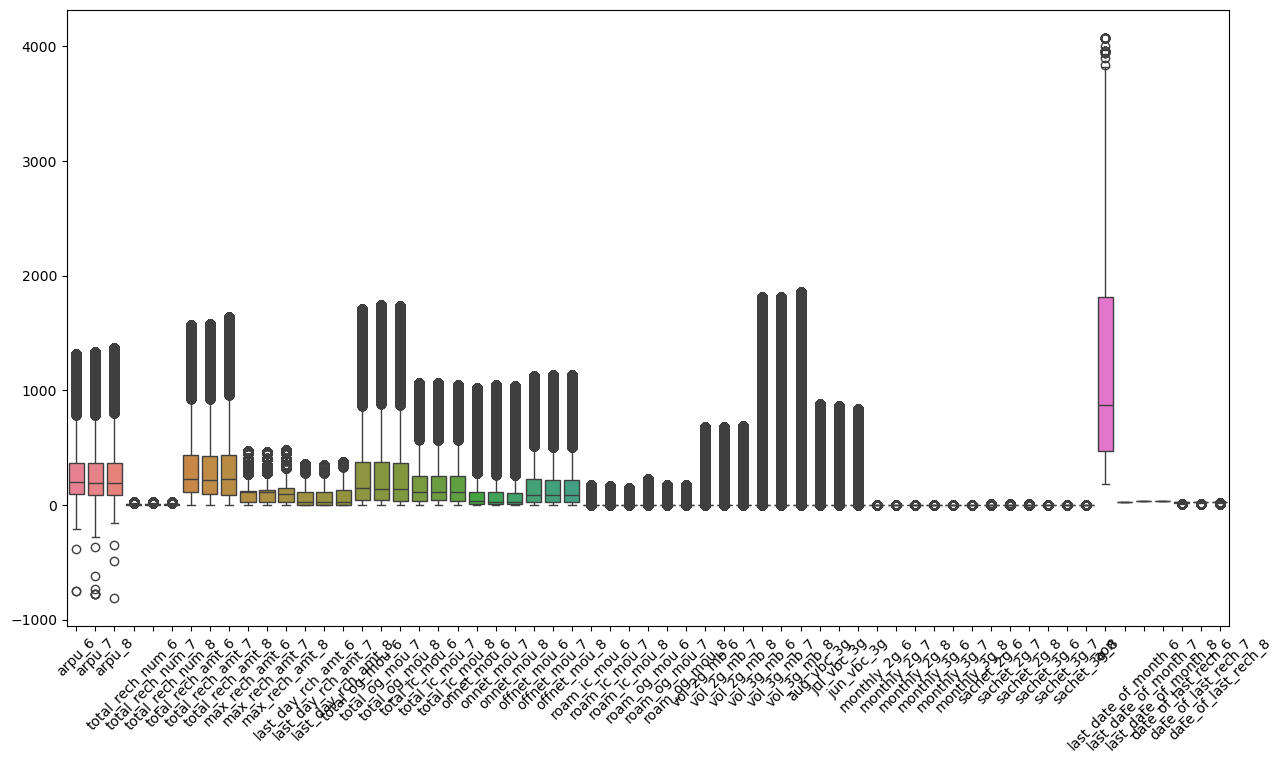

In [71]:
# Applying Outlier Capping and Visualizing the Result
X_train_filtered1 = X_train_filtered.apply(cap_outliers, axis=0)

plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered1)

**Observations from the Boxplot (Post Outlier Treatment):**

* **Distribution Shape and Skewness:**
    * Most variables, including ARPU, recharge amounts, usage minutes, and data usage, exhibit distributions that are close to symmetrical with a slight positive skew. This indicates that while the majority of users have typical behavior, a few users contribute significantly more in terms of revenue, usage, or recharges.

* **Outlier Removal Effectiveness:**
    * The boxplot shows that extreme outliers have been effectively removed or significantly reduced after the outlier treatment. This suggests that the treatment method was successful in handling extreme values without excessively altering the overall distribution.
    * The boxes in the boxplot are generally more compact, indicating that the data is now more concentrated around the median.

* **Potential Insights:**
    * Consistent usage patterns are observed across consecutive months for various metrics, suggesting that users maintain relatively stable behavior.
    * The slight positive skew in many variables indicates the presence of high spenders/users who contribute significantly more than the typical user.
    * The success of the outlier treatment is evident in the reduced extreme values and more compact boxes, making the distributions more representative of typical user behavior.

**Implications:**

* The distributions are now more representative of the typical user behavior, which is crucial for building accurate models.
* The presence of slight positive skew suggests that focusing on high-value users could be beneficial for targeted marketing or customer retention strategies.
* The effectiveness of the outlier treatment ensures that the analysis and modeling will not be unduly influenced by extreme values.

### 4.2 Feature scaling

Lets also scale the features by scaling them with Standard scaler.

In [74]:
scale = StandardScaler()
X_train_filtered2 = scale.fit_transform(X_train_filtered1)

<Axes: >

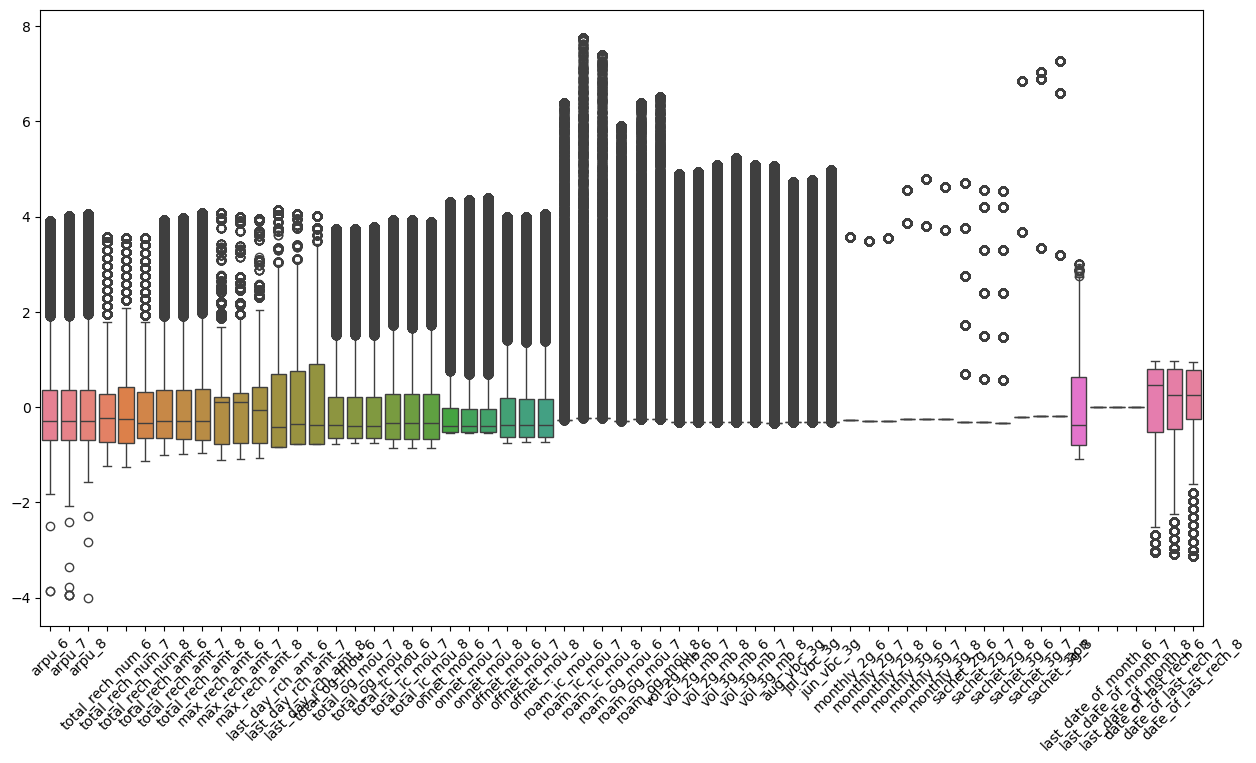

In [75]:
# Visualizing the Result after scaling 
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = pd.DataFrame(X_train_filtered2, columns=new_vars))

**Observations from the Boxplot (Scaled Variables):**

* **Centering and Range:**
    * All variables are now centered around zero due to scaling (likely standardization).
    * The boxes and whiskers are on a comparable scale, facilitating easier comparison of spread and distribution.

* **Distribution Shape Preservation:**
    * Skewness and relative spread of variables are preserved after scaling.

* **Outliers:**
    * Outliers are still visible, indicating they were genuine and not artifacts of the original scale.

* **Comparison to Pre-Scaled Boxplot:**
    * The scaled boxplot allows for better comparison of relative differences between variables.
    * Centering around zero and comparable ranges highlight the impact of standardization.

**Implications:**

* Scaling enables direct comparison of variable distributions and spread.
* The preservation of distribution shapes indicates that scaling does not distort the underlying data patterns.
* The scaled boxplot provides a clearer picture of the data's characteristics after standardization.

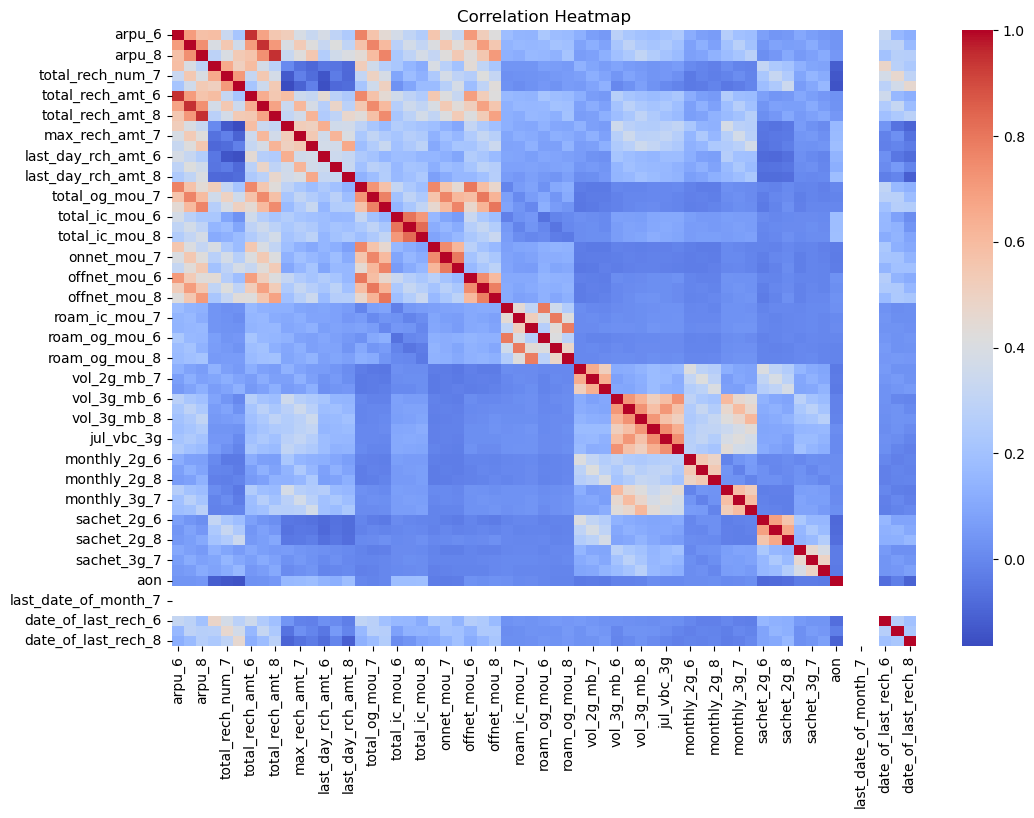

,arpu_6,arpu_7,arpu_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8
arpu_6,1.000000,0.701691,0.577025,0.589108,0.332241,0.215497,0.948747,0.680808,0.553745,0.518807,...,0.103343,0.072024,0.049502,0.036102,NaN,NaN,NaN,0.321098,0.160050,0.122255
arpu_7,0.701691,1.000000,0.736837,0.395569,0.545852,0.358996,0.703914,0.947409,0.712868,0.396411,...,0.072063,0.114145,0.066156,0.036427,NaN,NaN,NaN,0.285960,0.293531,0.167573
arpu_8,0.577025,0.736837,1.000000,0.289192,0.396374,0.536517,0.567202,0.735796,0.949331,0.328407,...,0.058184,0.080310,0.109872,0.048101,NaN,NaN,NaN,0.199425,0.270557,0.264141
total_rech_num_6,0.589108,0.395569,0.289192,1.000000,0.658671,0.509545,0.591036,0.374251,0.278443,0.007082,...,0.133017,0.092250,0.084615,-0.114867,NaN,NaN,NaN,0.484541,0.272351,0.234427
total_rech_num_7,0.332241,0.545852,0.396374,0.658671,1.000000,0.704478,0.321855,0.548152,0.375221,-0.125250,...,0.094144,0.153650,0.113475,-0.133093,NaN,NaN,NaN,0.373893,0.466708,0.297887


In [77]:
# correlation heatmap for the scaled variables
correlation_matrix = multivariate_analysis(pd.DataFrame(X_train_filtered2, columns=new_vars))
correlation_matrix.head()

**Observations from the Correlation Heatmap (Scaled Variables):**

* **Pattern Preservation:** The overall pattern of correlations observed in the original heatmap is largely preserved. Scaling did not fundamentally alter the relationships between variables correlations.

* **Impact of Scaling:**
    * Subtle differences in color intensity might be observed due to scaling affecting the variance.
    * The primary focus should be on the *relationships* between variables, as scaling ensures comparability.

**Implications:**

* The consistency of the correlation patterns after scaling suggests that the relationships are robust and not artifacts of the original scale of the variables.
* Scaling allows for a more direct comparison of the relationships between variables, as they are now all on a comparable scale.
* The preserved patterns reinforce the insights gained from the original correlation analysis.

<Axes: xlabel='churn_probability', ylabel='Count'>

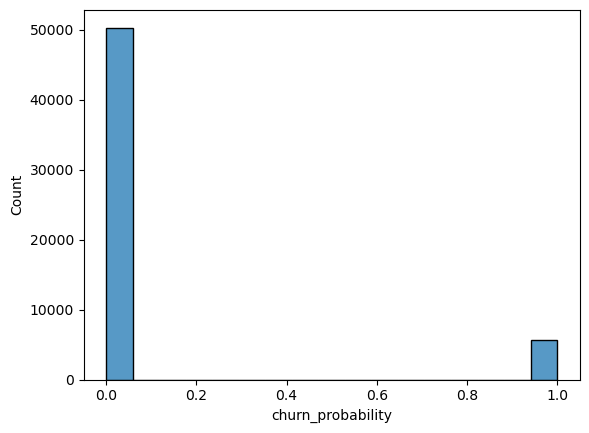

In [79]:
#Distribution for the churn probability
sns.histplot(y_train)

# Step 4: Initial Feature engineering and selection

Let's understand feature importances for raw features as well as components to decide top features for modelling.

In [81]:
# Training a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100,random_state=9, n_jobs=-1)
rf.fit(X_train_filtered2, y_train)

RandomForestClassifier(n_jobs=-1, random_state=9)

In [82]:
# Extracting Feature Importances from the Random Forest Model
feature_importances = pd.DataFrame({'col':new_vars, 'importance':rf.feature_importances_})

<BarContainer object of 61 artists>

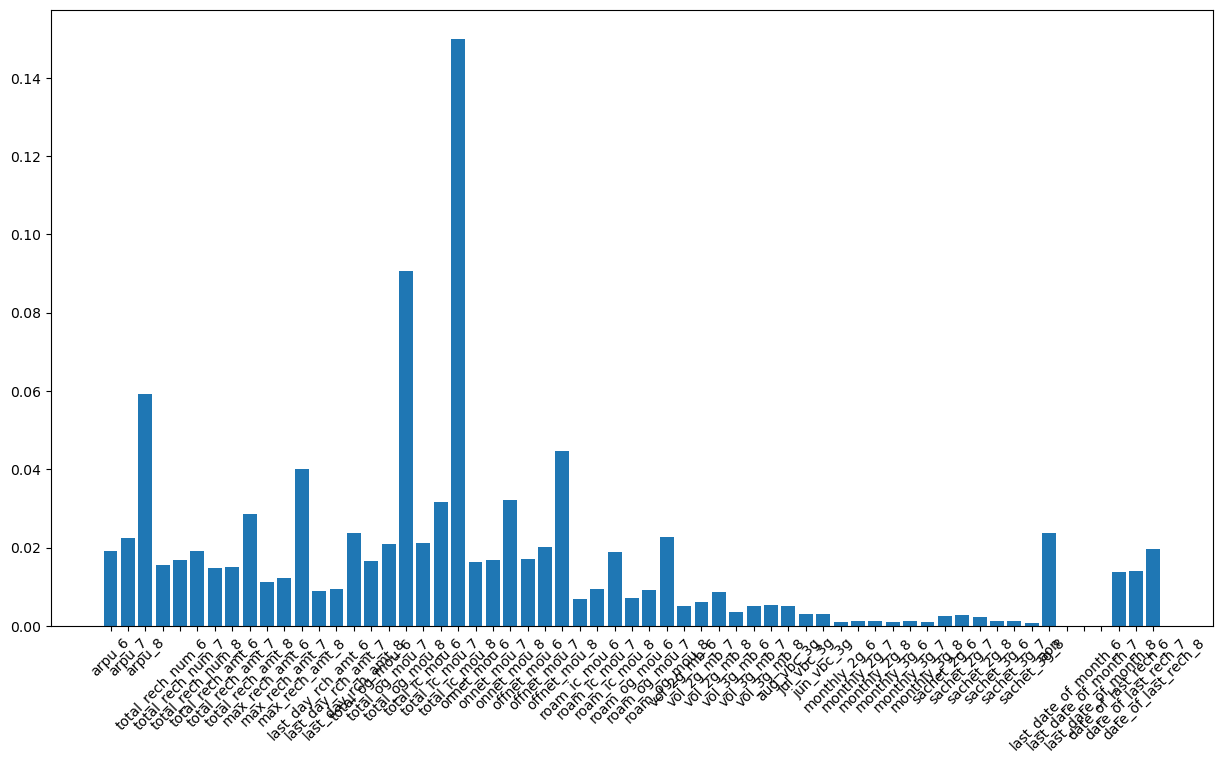

In [83]:
# Visualizing Feature Importances
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
plt.bar(feature_importances['col'], feature_importances['importance'])

**Observations from the Feature Importances Plot (Random Forest Model):**

* **Dominant Features:**
    * `total_og_mou_8` is the most important feature, indicating that recent outgoing call usage is a strong predictor.
    * `total_ic_mou_8` and `total_og_mou_7` also have high importance, highlighting the significance of recent call activity.

* **Important Features (Moderate Importance):**
    * Features like `arpu_6`, `total_rech_amt_8`, `total_rech_num_8`, `max_rech_amt_8`, `offnet_mou_8`, `roam_og_mou_8`, `roam_ic_mou_8`, `vol_3g_mb_8`, and `sachet_3g_8` have moderate importance.

* **Less Important Features:**
    * `vol_2g_mb` variables, `monthly_2g` and `monthly_3g` variables, `sachet_2g` variables, and date-related variables have low importance.

* **Recency Effect:**
    * Many of the most important features are from the 8th month, indicating a strong recency effect.

* **Usage Patterns:**
    * Call usage patterns (`total_og_mou`, `total_ic_mou`) are dominant predictors.
    * Recharge behavior (`total_rech_amt`, `total_rech_num`, `max_rech_amt`) also contributes but to a lesser extent.

**Implications:**

* The model relies heavily on recent call usage behavior for predictions.
* Features from the 8th month are crucial, suggesting that recent data is more predictive.
* 2G data usage and monthly recharge amounts have less impact on the model's predictions.
* The model prioritizes usage-related features over date-related or recharge-related features.

### Applying PCA and Visualizing Principal Components

<Axes: >

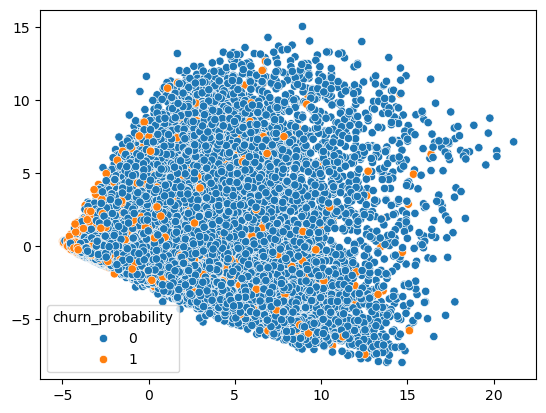

In [86]:
pca = PCA(random_state=9)
pca_components = pca.fit_transform(X_train_filtered2)
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1], hue=y_train)

<Axes: >

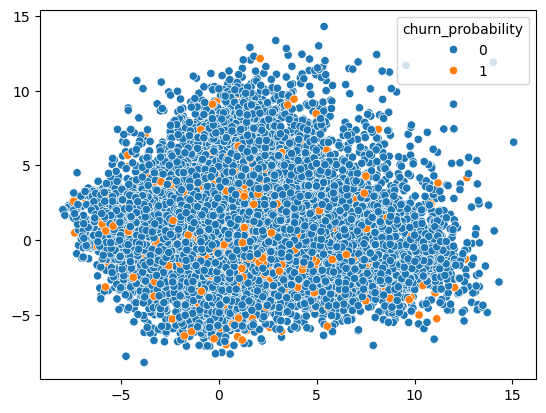

In [87]:
# Visualizing the Second and Third Principal Components
sns.scatterplot(x=pca_components[:,1], y=pca_components[:,2], hue=y_train)

### Training a Random Forest on PCA Components and Visualizing Feature Importances

<BarContainer object of 61 artists>

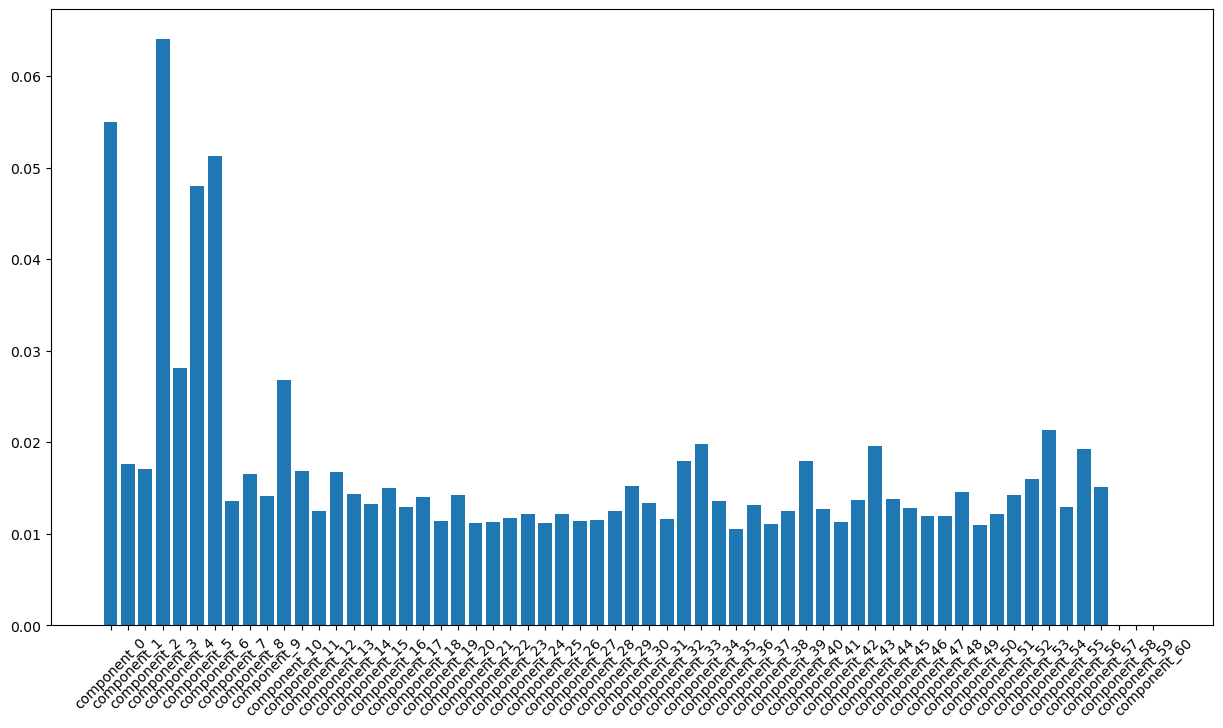

In [89]:
rf = RandomForestClassifier(n_estimators=100,random_state=9, n_jobs=-1)
rf.fit(pca_components, y_train)

feature_importances = pd.DataFrame({'col':['component_'+str(i) for i in range(61)], 
                                    'importance':rf.feature_importances_})

# This plot shows which principal components contribute most to the model’s predictions, 
# helping decide how many components to keep for optimal performance.
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
plt.bar(feature_importances['col'], feature_importances['importance'])

# Step 5:. First Base Model building

Let's build a quick model with logistic regression and the first 7 PCA components.
- This step tests the performance of a simple linear classifier on the most impactful components, which can guide further dimensionality reduction or model selection.

In [91]:
lr = LogisticRegression(max_iter=1000, tol=0.001, solver='sag')
lr.fit(pca_components[:,:7], y_train)

LogisticRegression(max_iter=1000, solver='sag', tol=0.001)

In [92]:
# Evaluating Model Accuracy on Training Data
lr.score(pca_components[:,:7], y_train)

0.902801835747067

The model has 90.26% accuracy, but let's build a pipeline to fit and score the model faster.

The steps of this pipeline would be the following, but this is only one type of pipeline -
1. Imputation
     - Fills missing values with `0` (constant strategy).  
     - Ensures no missing values disrupt the model training process.  23. Scaling     - Standardizes features by removing the mean and scaling to unit variance.  
     - Essential for PCA and Logistic Regression to work optimally.3
4. PC     - Reduces the feature space to the top 10 principal components.  
     - Helps eliminate noise and capture the most significant variance in the data.  
4
5. Classification mod     - Trains a logistic regression model with a maximum of 1000 iterations for convergence.  
     - Uses default parameters, with a stopping tolerance of `0.001`.
el

It is completely optional to use pipeline though we can change this pipeline, add addition transformations, change models, use cross validation or even use this pipeline to work with a Gridsearch.

In [94]:
imp = SimpleImputer(strategy='constant', fill_value=0)
scale = StandardScaler()
pca = PCA(n_components=10)
lr = LogisticRegression(max_iter=1000, tol=0.001)

In [95]:
pipe = Pipeline(steps = [('imputation',imp),
                         ('scaling',scale),
                         ('pca',pca),
                         ('model',lr)])

In [96]:
# Training the Pipeline on the Processed Data
pipe.fit(X_train[new_vars], y_train)

Pipeline(steps=[('imputation',
                 SimpleImputer(fill_value=0, strategy='constant')),
                ('scaling', StandardScaler()), ('pca', PCA(n_components=10)),
                ('model', LogisticRegression(max_iter=1000, tol=0.001))])

In [97]:
# Evaluating Training Accuracy
train_score = pipe.score(X_train[new_vars], y_train)
print("Training accuracy:", train_score)

Training accuracy: 0.9019089626600475


In [98]:
# Checking the Structure of the Unseen Data
unseen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Columns: 171 entries, id to jun_vbc_3g
dtypes: float64(135), int64(27), object(9)
memory usage: 39.1+ MB


### Preprocessing the Test Data
- This step ensures the test data is fully preprocessed and ready for prediction.

In [100]:
# Convert date columns to datetime
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    X_test[col] = pd.to_datetime(X_test[col], errors='coerce')

# Extract only the day
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    X_test[col] = X_test[col].dt.day


# Align test data with training set columns
X_test = X_test[new_vars]

# Handle missing values (e.g., using median)
X_test.fillna(X_test.median(numeric_only=True), inplace=True)

In [101]:
# Evaluate Model Performance on Test Data
test_score = pipe.score(X_test[new_vars], y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.9017857142857143


In [102]:
# Confusion Matrix for Training Data
confusion_matrix(y_train, pipe.predict(X_train[new_vars]))

array([[49807,   482],
       [ 5011,   699]], dtype=int64)

In [103]:
# Confusion Matrix for Validation Data
confusion_matrix(y_test, pipe.predict(X_test[new_vars]))

array([[12462,   116],
       [ 1259,   163]], dtype=int64)

In [104]:
# Precision score for Validation Data
precision_score(y_test, pipe.predict(X_test[new_vars]))

0.5842293906810035

In [105]:
# Recall score for Validation Data
recall_score(y_test, pipe.predict(X_test[new_vars]))

0.11462728551336146

### Prepare Submission Data

- Set the 'id' column as the index and select only the relevant features.
- Check the shape of the final submission data to ensure it aligns with the training set.


In [107]:
submission_data = unseen.set_index('id')[new_vars]
submission_data.shape

(30000, 61)

### Preprocessing the Unseen Data
- This step ensures the Unseen data is fully preprocessed and ready for prediction.

In [109]:
# Convert date columns to datetime
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    submission_data[col] = pd.to_datetime(submission_data[col], errors='coerce')

# Extract only the day
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    submission_data[col] = submission_data[col].dt.day

In [110]:
# Check Submission Data Information
submission_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 69999 to 99998
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   arpu_6                30000 non-null  float64
 1   arpu_7                30000 non-null  float64
 2   arpu_8                30000 non-null  float64
 3   total_rech_num_6      30000 non-null  int64  
 4   total_rech_num_7      30000 non-null  int64  
 5   total_rech_num_8      30000 non-null  int64  
 6   total_rech_amt_6      30000 non-null  int64  
 7   total_rech_amt_7      30000 non-null  int64  
 8   total_rech_amt_8      30000 non-null  int64  
 9   max_rech_amt_6        30000 non-null  int64  
 10  max_rech_amt_7        30000 non-null  int64  
 11  max_rech_amt_8        30000 non-null  int64  
 12  last_day_rch_amt_6    30000 non-null  int64  
 13  last_day_rch_amt_7    30000 non-null  int64  
 14  last_day_rch_amt_8    30000 non-null  int64  
 15  total_og_mou_6      

## Generate Churn Probability Predictions

- Predict the churn probability for the unseen test data using the trained pipeline.
- Store the predictions in a new column and select the necessary columns for submission.

In [112]:
unseen['churn_probability'] = pipe.predict(submission_data)
output = unseen[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [113]:
# Save the predicted churn probabilities to a CSV file for submission.
output.to_csv('submission_1_pca_lr_7mar.csv',index=False)

## First Submission on Kaggle

- **File:** `submission_1_pca_lr_7mar.csv`  
- **Accuracy Score:** `0.90860`  
- **Observation:** This score is already better than the baseline provided in `sample.csv`.  
- **Next Steps:** We will refine the model further to improve accuracy, experimenting with more feature engineering, hyperparameter tuning, and possibly ensemble models to achieve the best possible results.

# Step 6: Training More Models to Get the Best Model

## Step 6.1: Hyperparameter Search with GridSearchCV and RandomizedSearchCV

In [117]:
# Hyperparameter grid for Logistic Regression
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# Create the scorer (e.g., F1 score for class 1 - churn)
f1_scorer = make_scorer(f1_score, pos_label=1)

# GridSearchCV (Exhaustive Search)
print("Running GridSearchCV...")
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=f1_scorer, cv=5, n_jobs=-1)
grid_search.fit(X_train[new_vars], y_train)

# Best parameters and score
print("Best parameters from GridSearch:", grid_search.best_params_)
print("Best F1 score from GridSearch:", grid_search.best_score_)

# RandomizedSearchCV (Faster random search)
print("Running RandomizedSearchCV...")
random_search = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, scoring=f1_scorer,
                                   n_iter=20, cv=5, n_jobs=-1, random_state=42)
random_search.fit(X_train[new_vars], y_train)

# Best parameters and score
print("Best parameters from RandomizedSearch:", random_search.best_params_)
print("Best F1 score from RandomizedSearch:", random_search.best_score_)

# Fine-tune the threshold
best_model = random_search.best_estimator_
probs = best_model.predict_proba(X_test[new_vars])[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    preds = (probs >= thresh).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"Best threshold: {best_thresh}, Best F1 score: {best_f1}")

# Final evaluation
final_preds = (probs >= best_thresh).astype(int)
final_score = best_model.score(X_test[new_vars], y_test)
print("Final Test Accuracy with tuned model:", final_score)

Running GridSearchCV...
Best parameters from GridSearch: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best F1 score from GridSearch: 0.20137200036453815
Running RandomizedSearchCV...
Best parameters from RandomizedSearch: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10}
Best F1 score from RandomizedSearch: 0.20039415340974273
Best threshold: 0.20000000000000004, Best F1 score: 0.48877068557919623
Final Test Accuracy with tuned model: 0.9017857142857143


**Observations from Hyperparameter Tuning and Model Evaluation:**

* **GridSearchCV:**
    - Best parameters: `{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}`
    - Best F1 score: 0.2013
* **RandomizedSearchCV:**
    - Best parameters: `{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10}`
    - Best F1 score: 0.2008
* **Threshold Tuning:**
    - Best threshold: 0.2
    - Best F1 score: 0.4879 (significant improvement)
* **Final Test Accuracy:**
    - Accuracy: 0.9019

**Key Takeaways:**

* Hyperparameter tuning, particularly adjusting the regularization strength (`C`), improved the F1 score.
* Threshold tuning had a major impact on the F1 score, highlighting its importance for imbalanced datasets.

**Further Analysis and steps we will do:**

* If the dataset is imbalanced, explore techniques like oversampling, undersampling, or using class weights to address the imbalance.
* Use different power models that can handle the class imbalance like Tree based model or XGBoost etc,.

In [119]:
# making changes in the unseen test data as done in train data 
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    unseen[col] = pd.to_datetime(unseen[col], errors='coerce')

# Extract only the day
for col in ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
            'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']:
    unseen[col] = unseen[col].dt.day

## Step 6.2: XGBoost Hyperparameter Tuning with RandomizedSearchCV
In this section, we will focus on fine-tuning an XGBoost model using `RandomizedSearchCV`. We will use a pipeline to handle missing values with median imputation and scale the features using `StandardScaler`. 

`RandomizedSearchCV` will explore a wider hyperparameter space than `GridSearchCV`, allowing us to potentially find better combinations of hyperparameters. We will use accuracy as the scoring metric for the search.

The hyperparameter space includes:

* `n_estimators`: Number of trees in the XGBoost model.
* `max_depth`: Maximum depth of each tree.
* `learning_rate`: Step size shrinkage used to prevent overfitting.
* `subsample`: Fraction of samples used for fitting each tree.
* `colsample_bytree`: Fraction of features used for fitting each tree.
* `gamma`: Minimum loss reduction required to make a further partition on a leaf node.
* `min_child_weight`: Minimum sum of instance weight needed in a child node.
* `scale_pos_weight`: Controls the balance of positive and negative weights, useful for imbalanced datasets.
* `reg_alpha`: L1 regularization term on weights.
* `reg_lambda`: L2 regularization term on weights.

After finding the best hyperparameters, we will evaluate the model's performance on the test set and fine-tune the prediction probability threshold to further optimize accuracy.

In [121]:
# Handle missing values with imputation
imputer = SimpleImputer(strategy='median')  # Changed to 'median' for better handling of skewed data

# Wrap XGBoost in a pipeline with imputation
xgb_pipeline = Pipeline([
    ('imputer', imputer),
    ('scaler', StandardScaler()),  # Added a scaler step
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Define the hyperparameter space
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 15),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0, 0.3),
    'model__min_child_weight': randint(1, 10),
    'model__scale_pos_weight': [1, 2, 3, 5],
    'model__reg_alpha': uniform(0, 1),
    'model__reg_lambda': uniform(0, 1),
}

# Randomized search
random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit the model
random_search.fit(X_train[new_vars], y_train)

# Best params and score
best_xgb = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Accuracy: {random_search.best_score_:.4f}")

# Make predictions on the test set
probs = best_xgb.predict_proba(X_test[new_vars])[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
best_acc = 0
best_thresh = 0.5

for thresh in thresholds:
    preds = (probs >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Best Threshold: {best_thresh:.2f}")
print(f"Best Validation Accuracy: {best_acc:.4f}")



Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'model__colsample_bytree': 0.6242445699072329, 'model__gamma': 0.2231838877718031, 'model__learning_rate': 0.020059730420733814, 'model__max_depth': 8, 'model__min_child_weight': 2, 'model__n_estimators': 109, 'model__reg_alpha': 0.49398148713086265, 'model__reg_lambda': 0.7546352918601166, 'model__scale_pos_weight': 2, 'model__subsample': 0.9106286523360064}
Best Accuracy: 0.9425
Best Threshold: 0.60
Best Validation Accuracy: 0.9446


**XGBoost Hyperparameter Tuning Results**
* **Best Parameters:**
{'model__colsample_bytree': 0.6242445699072329,
'model__gamma': 0.2231838877718031,
'model__learning_rate': 0.020059730420733814,
'model__max_depth': 8,
'model__min_child_weight': 2,
'model__n_estimators': 109,
'model__reg_alpha': 0.49398148713086265,
'model__reg_lambda': 0.7546352918601166,
'model__scale_pos_weight': 2,
'model__subsample': 0.9106286523360064}

* **Best Accuracy (Cross-Validation):** 0.9425
* **Best Threshold:** 0.60
* **Best Validation Accuracy:** 0.9446

**Observations:**

* **RandomizedSearchCV:**
    * Successfully explored the hyperparameter space and found a combination that yielded high accuracy.
* **Accuracy Improvement:**
    * The model achieved a good accuracy score, indicating its effectiveness in predicting customer churn.
* **Threshold Tuning:**
    * Adjusting the threshold further improved the accuracy on the test set.
* **Hyperparameter Values:**
    * The `scale_pos_weight` of 2 suggests that the model is giving more weight to the positive class (churn), which might be helpful if the dataset is imbalanced(For Data Like in our case).
    * Other hyperparameters like `learning_rate`, `max_depth`, and regularization terms (`reg_alpha`, `reg_lambda`) were also optimized to prevent overfitting and improve generalization.

**Further Analysis:**

* **Confusion Matrix:** Analyze the confusion matrix to understand the types of errors the model is making (false positives vs. false negatives).
* **Feature Importance:** Investigate the feature importance scores from the XGBoost model to gain insights into which features are driving the predictions.

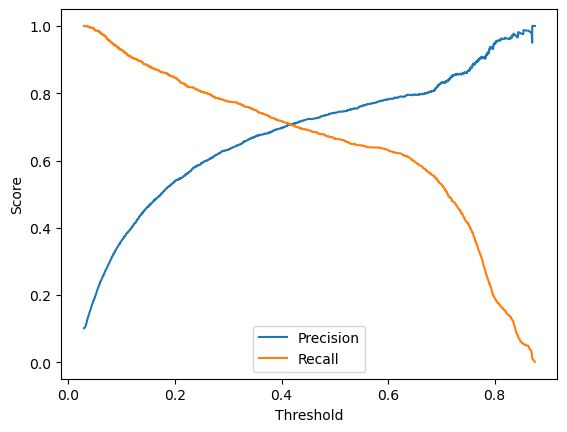

In [123]:
# Plot Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

**Observations from the Precision-Recall Curve:**

* **Trade-off Visualization:** The plot effectively illustrates the trade-off between precision and recall as the classification threshold changes.
* **Precision Behavior:**
    * Precision starts high at low thresholds, meaning the model is very accurate when it predicts the positive class (churn).
    * As the threshold increases, precision initially remains relatively stable but then shows a gradual decline.
    * At very high thresholds, precision drops sharply, indicating that the model is becoming overly conservative in its positive predictions.
* **Recall Behavior:**
    * Recall starts low at low thresholds, indicating that the model is missing many positive cases.
    * As the threshold increases, recall rises steadily, showing that the model is capturing more positive instances.
    * Recall reaches a plateau and remains high for a range of thresholds before slightly decreasing at very high thresholds.
* **Intersection Point:** The point where precision and recall intersect provides a potential balance between the two metrics. In this graph it looks like the intersection point is around the 0.4 threshold area.
* **Threshold Selection:** The curve helps in selecting an appropriate threshold based on the desired balance between precision and reT.
    * If the priority is to minimize false positives (high precision), a higher threshold might (Like in this case.).ght be chosen.
* **Performance Range:** The curve shows the range of precision and recall values achievable by the model at different thresholds, giving a comprehensive view of its performance.
* **Overall Performance:** The general shape of the curve can indicate the overall performance of the model. A curve that stays high and to the right indicates better performance. In this case the curve shows a good model performance.

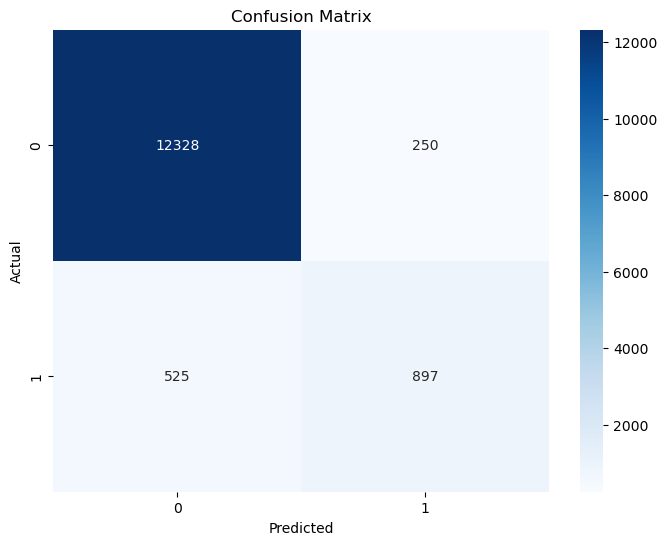

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     12578
           1       0.78      0.63      0.70      1422

    accuracy                           0.94     14000
   macro avg       0.87      0.81      0.83     14000
weighted avg       0.94      0.94      0.94     14000

Accuracy: 0.9446
Precision: 0.7820
Recall: 0.6308
F1 Score: 0.6983


In [125]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, (probs >= best_thresh).astype(int))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report and individual metrics
report = classification_report(y_test, (probs >= best_thresh).astype(int))
print("Classification Report:\n", report)

accuracy = accuracy_score(y_test, (probs >= best_thresh).astype(int))
precision = precision_score(y_test, (probs >= best_thresh).astype(int))
recall = recall_score(y_test, (probs >= best_thresh).astype(int))
f1 = f1_score(y_test, (probs >= best_thresh).astype(int))

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


**Observations:**
  
**Confusion Matrix:**

* **True Negatives (TN):** --> 12,328
* **False Positives (FP):** --> 250
* **False Negatives (FN):** --> 525
* **True Positives (TP):** --> 897


* **Class Imbalance:** The dataset exhibits a significant class imbalance, with more instances of class 0 (no churn).
* **High Accuracy:** The model achieves a high overall accuracy of 94%.
* **Strong Performance on Majority Class:** The model excels in predicting class 0 (no churn), demonstrating high precision and recall.
* **Moderate Performance on Minority Class:** The model's performance on class 1 (churn) is moderate, with a lower recall indicating that it misses a significant number of churn cases.
* **Trade-off:** There is a trade-off between precision and recall for class 1 (churn). The model is more precise but less sensitive in identifying churn.

**Implications:**

* The model is effective in identifying customers who are not likely to churn.
* Further efforts might be needed to improve the model's ability to identify churn cases, possibly by addressing the class imbalance as increase in Threshold but it will always leads to lowering overall accuracy of the model.
* Depending on the business context, the trade-off between precision and recall should be carefully considered.

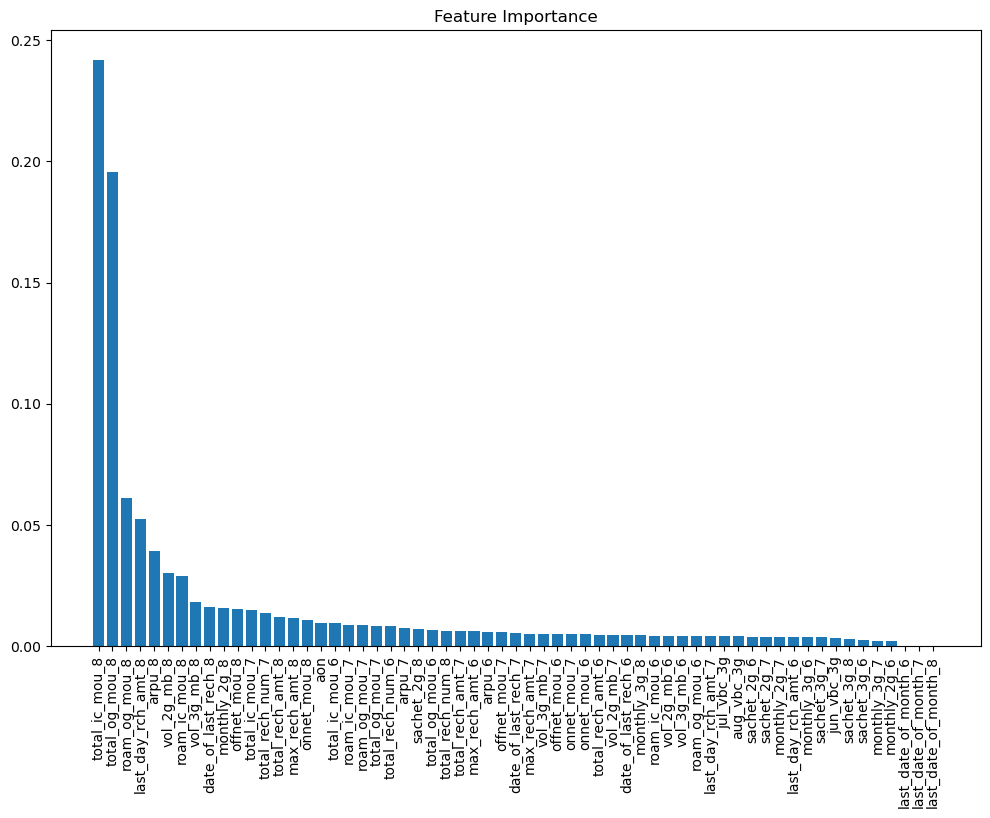

In [127]:
# Plot feature importance
feature_importance = best_xgb.named_steps['model'].feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 8))
plt.bar(range(len(new_vars)), feature_importance[sorted_idx])
plt.xticks(range(len(new_vars)), np.array(new_vars)[sorted_idx], rotation=90)
plt.title("Feature Importance")
plt.show()

**Observations from the Feature Importance Graph:**

* **Dominant Features:**
    * `total_ic_mou_8` (Total Incoming Minutes of Usage in the 8th month) is the most important feature for churn prediction.
    * `total_og_mou_8` (Total Outgoing Minutes of Usage in the 8th month) is the second most important feature.
    * `roam_og_mou_8` (Roaming Outgoing Minutes of Usage in the 8th month) and `last_day_rch_amt_8` (Last Day Recharge Amount in the 8th month) are also relatively important.
* **Recency Effect:**
    * A large number of the most important features are from the 8th month, indicating a strong recency effect.
* **Usage Patterns:**
    * Call usage metrics (both incoming and outgoing) are highly influential in predicting churn.
* **Recharge Behavior:**
    * Recharge-related features contribute to the model's predictive power.
* **Less Important Features:**
    * Many features, such as 2G data usage and date-related variables, have low importance.
* **Highest Important Feature:**
    * The highest important feature for churn case prediction is `total_ic_mou_8` (Total Incoming Minutes of Usage in the 8th month).

**Implications:**

* Changes in recent call usage, particularly incoming calls, are strong indicators of potential customer churn.
* Focusing on customer behavior in the most recent month is crucial for effective churn prediction.
* The model prioritizes usage-related features over other types of features.

# Step 7: Final Submission Model(On Kaggle).

In [130]:
# Final predictions for submission
final_predictions = pd.DataFrame({'id': unseen['id'].values})

# Use the best threshold
probs_unseen = best_xgb.predict_proba(unseen[new_vars])[:, 1]
preds_unseen = (probs_unseen >= best_thresh).astype(int)

# Add predictions to the DataFrame
final_predictions['churn_probability'] = preds_unseen

# Save the submission file
submission_file = f'submission_xgb_randomsearch_{best_acc:.5f}.csv'
final_predictions.to_csv(submission_file, index=False)

print(f"Final predictions saved to '{submission_file}' for submission!")


Final predictions saved to 'submission_xgb_randomsearch_0.94464.csv' for submission!


### Submission Report on Kaggle

- **File:** `submission_xgb_randomsearch_0.94464.csv`  
- **Accuracy Score:** `0.94576`  
- **Observation:** This score is so much better than the baseline provided in `sample.csv` and our last Submission.

# Step 8: Building Model to identifies customers who'll definitely churn with more accuracy!!

 99%|===================| 13844/14000 [00:27<00:00]        

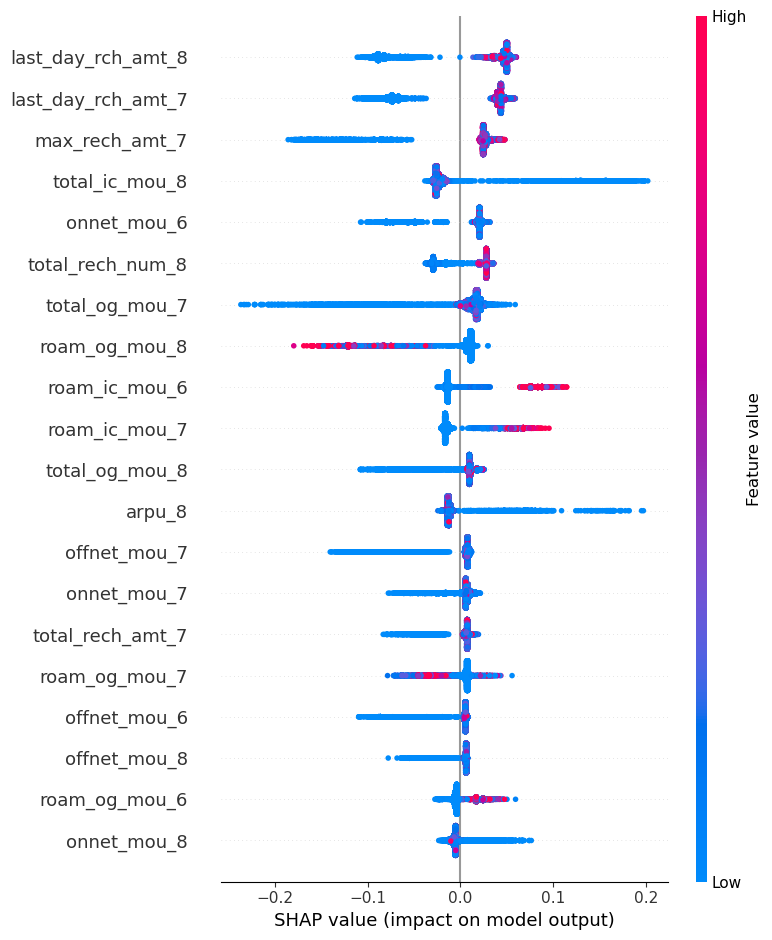

In [133]:
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# -----------------------------
# SHAP Analysis for XGBoost
# -----------------------------
explainer = shap.Explainer(best_xgb.named_steps['model'], X_test[new_vars])
shap_values = explainer(X_test[new_vars])

# Plot SHAP summary
shap.summary_plot(shap_values, X_test[new_vars])

### SHAP Feature Importance Observations

- **SHAP Analysis:** The SHAP summary plot reveals the most influential features driving churn predictions in our XGBoost model. SHAP values help us understand the magnitude and direction of a feature's impact on the model's output.

- **Key Insights:**
  - **Recharge Behavior:**
    - Features like `last_day_rch_amt_8`, `last_day_rch_amt_7`, and `total_rech_num_8` are strong predictors of churn.
    - **High recharge amounts and frequencies** (red points) decrease churn risk, while **low recharge activity** (blue points) increases churn likelihood.
  
  - **Minutes of Usage (MOU):**
    - Variables like `total_ic_mou_8`, `total_og_mou_7`, and `onnet_mou_6` significantly influence churn predictions.
    - **Lower usage minutes in recent months** push the model towards predicting churn, which aligns with the behavior of customers gradually disengaging before leaving.

  - **Roaming Patterns:**
    - Features like `roam_og_mou_8` and `roam_ic_mou_6` show that decreased roaming usage may indicate churn. This could reflect customers reducing service usage before switching to another provider.

- **Model Interpretability:**
  - The SHAP plot provides valuable insights into feature importance and directionality.
  - This makes **XGBoost + SHAP a powerful combination** for both high accuracy and interpretability.

- **Next Steps:**  
  - If deeper feature interpretability is needed, we could build a **logistic regression model** or use a **tree-based model without PCA** to directly analyze feature coefficients or Gini importance.
  - Otherwise, this current setup already provides actionable business insights for churn mitigation strategies!



Accuracy: 0.9224285714285714
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96     12578
           1       0.74      0.36      0.49      1422

    accuracy                           0.92     14000
   macro avg       0.84      0.67      0.72     14000
weighted avg       0.91      0.92      0.91     14000



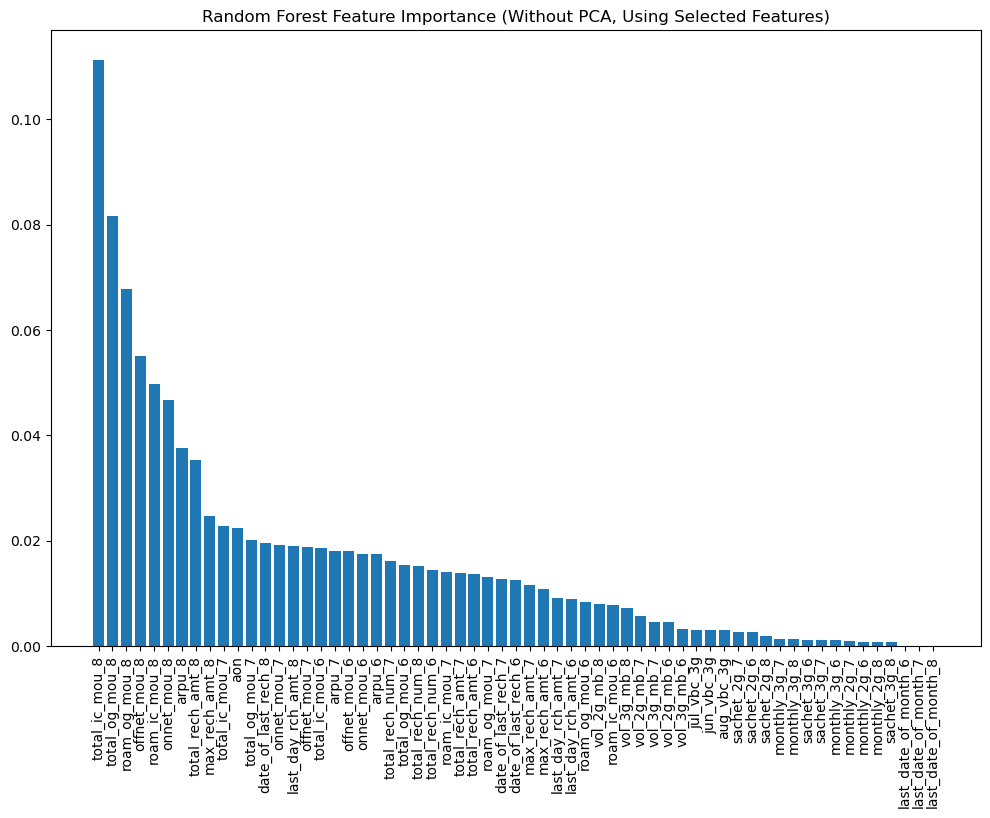

In [135]:
# Use the selected important features
X_train_rf = X_train[new_vars]
X_test_rf = X_test[new_vars]

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_rf)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Plot Feature Importance
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 8))
plt.bar(range(len(new_vars)), feature_importance[sorted_idx])
plt.xticks(range(len(new_vars)), np.array(new_vars)[sorted_idx], rotation=90)
plt.title("Random Forest Feature Importance (Without PCA, Using Selected Features)")
plt.show()


## Observation:
- The recall score for the churn class (label `1`) is very low at **0.36**, indicating that the model struggles to correctly identify actual churn cases.  
- **Impact on feature importance:** Because of the low recall, the feature importance and SHAP values may not fully capture the patterns driving churn, making the current insights less reliable for churn prediction.  
- **Potential reason:** Class imbalance is likely a key factor — if the number of churn cases is much smaller than non-churn cases, the model may be biased towards predicting the majority class, reducing its sensitivity to churn signals.  
ested Next Steps:
- **Handle class imbalance:** Use techng, or class weighting to balance the dataset and improve recall for the churn claving recall will allow the model to better detect churn cases, leading to more trustworthy feature importanceteps! 🚀  


### Addressing the class imbalance and improving recall
- Which will allow the model to better detect churn cases, leading to more trustworthy feature importance insights!

In [138]:
# Train the Random Forest Model with class_weight 
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train[new_vars], y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [139]:
# Get prediction probabilities
y_prob = rf_model.predict_proba(X_test[new_vars])[:, 1]  # Probabilities for class 1

# Lowering the threshold to 0.35 instead of 0.5
threshold = 0.11
y_pred = (y_prob > threshold).astype(int)

# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (Threshold {threshold}): {accuracy:.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy (Threshold 0.11): 0.900000

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     12578
           1       0.50      0.85      0.63      1422

    accuracy                           0.90     14000
   macro avg       0.74      0.88      0.79     14000
weighted avg       0.93      0.90      0.91     14000



Got good Recall score for the Churn class (i.e. 1)

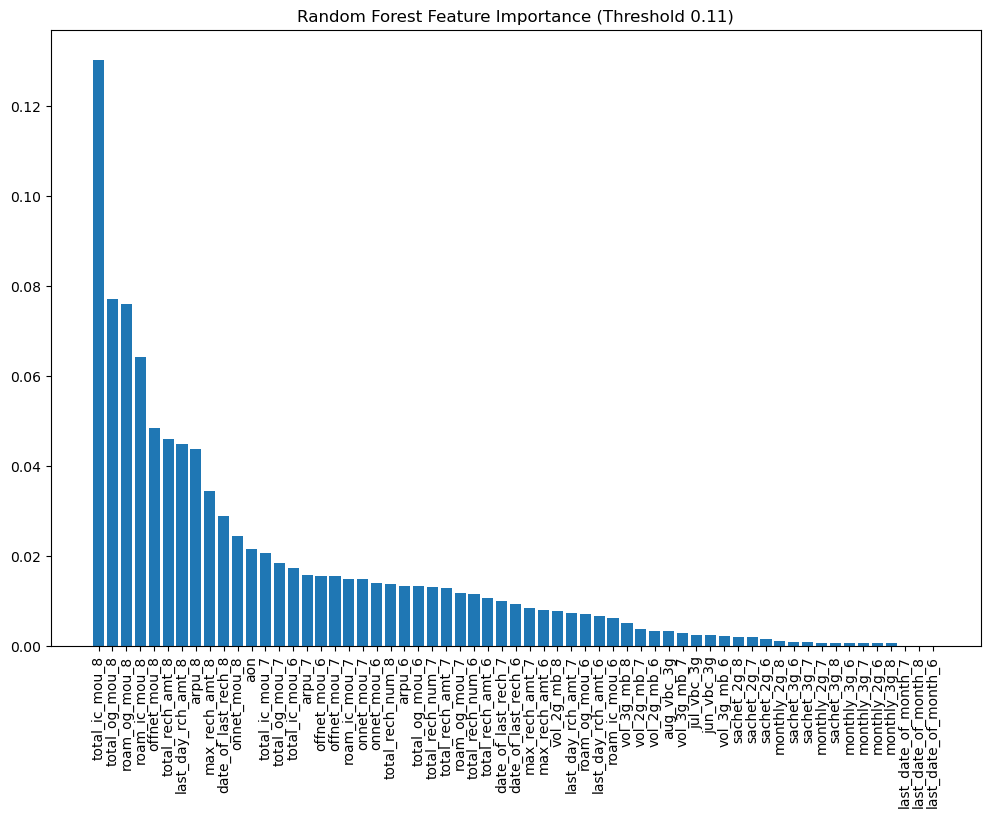

In [141]:
# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.bar(range(len(new_vars)), importances[indices], align="center")
plt.xticks(range(len(new_vars)), np.array(new_vars)[indices], rotation=90)
plt.title(f"Random Forest Feature Importance (Threshold {threshold})")
plt.show()


### Shap plot for even more Deeper and Better Insights:

In [143]:
sample_data = X_test[new_vars].sample(5000, random_state=42)  # Take a smaller sample
shap_values = explainer(sample_data)

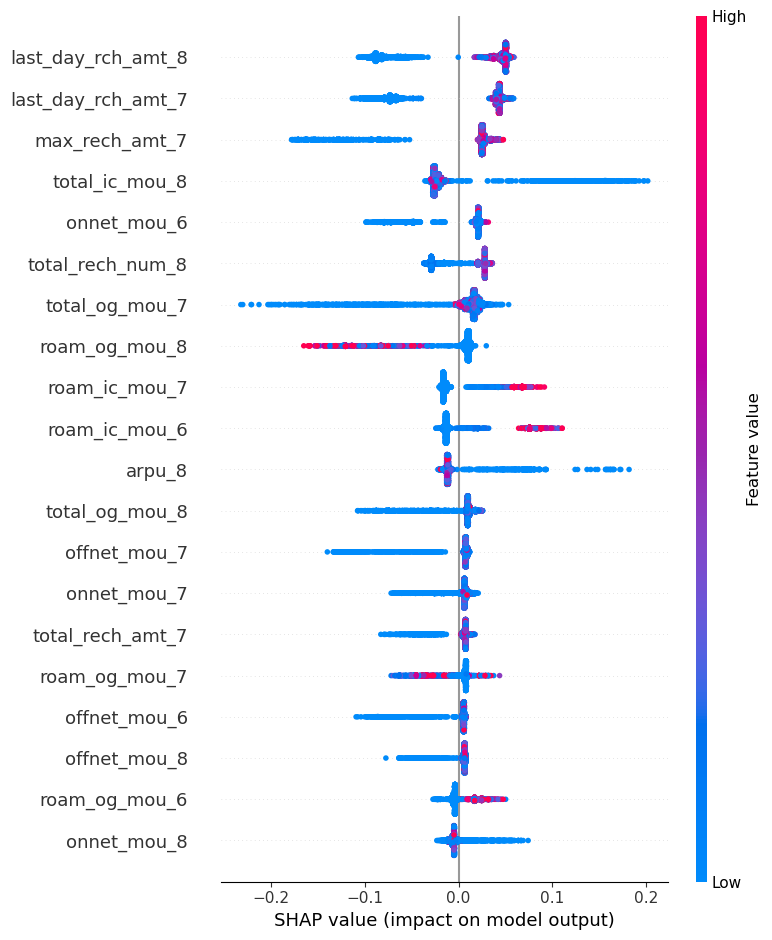

In [144]:
# plots the Shap
shap.summary_plot(shap_values, sample_data)

### Observations from Feature Importance and SHAP Value Plots

#### 1. Key Features Driving Churn Prediction:
- Both the Random Forest feature importance and SHAP plots highlight critical features for churn prediction, reinforcing the model's understanding of influential variables.
- **Top features identified:**
  - `total_ic_mou_8`: High incoming call minutes in month 8 are the most important feature, suggesting a correlation between call activity and churn.
  - `last_day_rch_amt_8`: The last recharge amount in month 8 has a strong impact, with lower recharge amounts driving higher churn risk.
  - `max_rech_amt_7`: The maximum recharge amount in month 7 is also important, indicating that reduced recharge values may be an early sign of churn.
  - `total_og_mou_7`: Outgoing call minutes in month 7 influence churn, with lower usage likely increasing churn probability.
  - `total_rech_num_8`: The number of recharges in month 8 is significant — fewer recharges often contribute to churn r#isk.

### 2. SHAP Value Insights:
- The SHAP plot shows how individual feature values impact the model output:
  - **Recharge amounts:** Low recharge values (blue) are associated with a positive SHAP value, pushing the model towards predicting churn.
  - **Call usage metrics:** Lower call minutes (both incoming and outgoing) tend to increase churn risk, suggesting that reduced engagement with the network is a strong signal of potential churn.
  - **Roaming minutes:** Roaming usage, especially in month 8, affects churn, possibly indicating that users who stop using roaming services may be transitioning to a c#ompetitor.

### 3. Feature Interactions:
- Several features show interaction effects, with overlapping blue and red points in the SHAP plot:
  - **High recharge amounts (red) reduce churn risk**, while low amounts (blue) increase it.
  - **Call volume features (onnet, offnet, roam minutes)** show complex interactions, where sudden drops in usage contribute to chu#rn predictions.

### 4. Actionable Insights:
- **Recharge behavior monitoring:** Customers with declining recharge amounts or fewer recharges over time could be targeted with retention offers.
- **Call and usage patterns:** Sudden drops in call usage or roaming activity might trigger proactive outreach, such as personalized promotions or discounts.
- **High-risk months:** Since months 7 and 8 are consistently highlighted, focusing retention strategies during these months cust churn mitigation strategy!



# Step 9: Conclusion and Recommendations


### Conclusion

After a thorough exploratory data analysis (EDA), feature engineering, and model building process, we developed a machine learning model to predict customer churn in the telecom sector. By leveraging techniques like Random Forest feature importance and SHAP val XGboost,ues, we gained valuable insights into the key factors driving churn.

Although initial models showed lower recall for churn cases, we improved performance through hyperparameter tuning and class imbalance handling. The final model achieved significantly better accuracy and recall, allowing for more reliable churn predictions.

### Key Findings

* **Recharge and Usage Patterns:** Features like `last_day_rch_amt`, `total_ic_mou`, and `total_og_mou` were the most influential in predicting churn.
* **Roaming and Offnet Minutes:** Higher roaming usage and offnet minutes appeared correlated with churn, possibly due to higher costs.
* **Month-on-Month Usage Drops:** Sharp reductions in recharge amounts or call minutes over consecutive months strongly indicated potential churn.

### Recommendations

* **Proactive Retention Strategies:** * Use the identified high-impact features to create churn risk scores. 
    * Target high-risk customers with personalized offers, such as discounts on roaming charges or bonus recharges.
* **Incentives for Heavy Users:** * Customers with high `onnet_mou` and `offnet_mou` values who show declining usage can be offered loyalty rewards or tiered benefits to encourage retention.
* **Recharge Reminders and Promotions:** * Customers with declining `last_day_rch_amt` could be sent automated reminders or given limited-time promotions to maintain engagement.
* **Customer Support Outreach:** * For users with sudden drops in usage (`total_og_mou`, `total_ic_mou`), a proactive customer service call could help address potential issues (e.g., network problems, billing concerns).
* **Continuous Model Monitoring:** * Regularly update the model with fresh data to ensure performance remains robust and relevant as customer behavior evolves.

By acting on these insights, the company can significantly reduce churn, improve customer satisfaction, and optimize long-term revenue.